# **CARGA, CONSOLIDACIÓN Y ANÁLISIS DE COBERTURA**

---



In [1]:
# ==============================================================================
# SCRIPT 2: CARGA, CONSOLIDACIÓN Y ANÁLISIS DE COBERTURA
# ==============================================================================
# Unifica los pasos 2, 2.1 y 2.2 en un único script para ejecutar en Colab.
#
# Orden de ejecución:
#   SECCIÓN 1 → Montar Drive y definir rutas
#   SECCIÓN 2 → Cargar datos PTB (por año)
#   SECCIÓN 3 → Cargar datos DEFENSA (por año)
#   SECCIÓN 4 → Cargar Euríbor
#   SECCIÓN 5 → Cargar STOXX 600 (índice de mercado)
#   SECCIÓN 6 → Verificación cruzada de fechas
#   SECCIÓN 7 → Consolidación PTB + DEFENSA + Euríbor por año
#   SECCIÓN 8 → Guardar y verificar archivos CONSOLIDADO_YYYY.csv
#   SECCIÓN 9 → Análisis de cobertura global y anual
#   SECCIÓN 10 → Disponibilidad de ratios derivados por hipótesis
#   SECCIÓN 11 → Estadísticas descriptivas y gráficos
#   SECCIÓN 12 → Resumen ejecutivo
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:


print("=" * 90)
print("SCRIPT 2: CARGA, CONSOLIDACIÓN Y ANÁLISIS DE COBERTURA")
print("=" * 90)
print(f"Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

YEARS = range(2015, 2026)

# ==============================================================================
# SECCIÓN 1: MONTAR DRIVE Y DEFINIR RUTAS
# ==============================================================================

print("─" * 90)
print("SECCIÓN 1: MONTAR DRIVE")
print("─" * 90)

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Colab Notebooks'

print(f"\n📂 Carpeta base: {BASE}")
print(f"\nArchivos disponibles:")
for f in sorted(os.listdir(BASE)):
    size_mb = os.path.getsize(os.path.join(BASE, f)) / 1_048_576
    print(f"  {f:60s}  {size_mb:6.1f} MB")

# ==============================================================================
# SECCIÓN 2: CARGAR DATOS PTB (2015-2025)
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 2: CARGAR DATOS PTB CONSOLIDADOS")
print("─" * 90)

ptb = {}
for year in YEARS:
    path = os.path.join(BASE, f'stoxx600_PTB_CONSOLIDADO_{year}.csv')
    ptb[year] = pd.read_csv(path, parse_dates=['Date'])

print(f"\n{'Año':>6}  {'RICs':>6}  {'Filas':>10}  {'PTB nulos':>10}  {'ROA nulos':>10}")
print("-" * 55)
for year, df in ptb.items():
    ptb_null = df['Price_To_Book'].isna().sum()
    roa_null = df['Pretax_ROA'].isna().sum()
    print(f"{year:>6}  {df['RIC'].nunique():>6}  {len(df):>10,}  {ptb_null:>10,}  {roa_null:>10,}")

print(f"\n{'Año':>6}  {'RICs sin PTB':>13}  Lista")
print("-" * 80)
for year in YEARS:
    sin_ptb = ptb[year].groupby('RIC')['Price_To_Book'].apply(lambda s: s.isna().all())
    rics = sorted(sin_ptb[sin_ptb].index.tolist())
    print(f"{year:>6}  {len(rics):>13}  {rics}")

# ==============================================================================
# SECCIÓN 3: CARGAR DATOS DEFENSA (2015-2025)
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 3: CARGAR DATOS DEFENSA")
print("─" * 90)

defensa = {}
for year in YEARS:
    path = os.path.join(BASE, f'stoxx600_DEFENSA_{year}.csv')
    defensa[year] = pd.read_csv(path, parse_dates=['Date'])

print(f"\n{'Año':>6}  {'RICs':>6}  {'Filas':>10}  {'Columnas (primeras 5)'}")
print("-" * 70)
for year, df in defensa.items():
    print(f"{year:>6}  {df['RIC'].nunique():>6}  {len(df):>10,}  {list(df.columns)[:5]}…")

# ==============================================================================
# SECCIÓN 4: CARGAR EURÍBOR
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 4: CARGAR EURÍBOR")
print("─" * 90)

euribor = pd.read_csv(
    os.path.join(BASE, 'euribor_tasas_diarias_2014_2025_corregido.csv'),
    parse_dates=['Date']
)

print(f"\n✅ Euríbor cargado: {len(euribor):,} filas")
print(f"   Rango: {euribor['Date'].min().date()} → {euribor['Date'].max().date()}")
print(f"   Columnas: {list(euribor.columns)}")
print(f"   Valores nulos: Euribor_1M={euribor['Euribor_1M'].isna().sum()} | Euribor_1Y={euribor['Euribor_1Y'].isna().sum()}")
print(euribor.head(3).to_string(index=False))

# ==============================================================================
# SECCIÓN 5: CARGAR STOXX 600 (ÍNDICE DE MERCADO)
# ==============================================================================
#
# DECISIÓN METODOLÓGICA (Anexo A1 — Script A1_Comparacion_Indices_STOXX600):
#   Se utilizan tres versiones del STOXX Europe 600. Activar UNA sola
#   descomentando la línea correspondiente. Las otras dos deben permanecer
#   comentadas. Todas tienen la misma estructura (Date, Close_Price, Return).
#
#   PR  — Price Return     (solo precio de cierre, sin dividendos)
#          Rm_Rf ≈ −2.35%/año → sesgado negativamente. NO RECOMENDADO.
#
#   NR  — Net Return       (precio + dividendos netos de retención fiscal)
#          Rm_Rf ≈ +0.20%/año → VERSIÓN SELECCIONADA para el análisis principal.
#          Convención estándar en fondos UCITS europeos y literatura académica.
#
#   GR  — Gross Return     (precio + dividendos brutos, antes de impuestos)
#          Rm_Rf ≈ +0.77%/año → sobreestima el retorno disponible para el inversor.
#          Útil para análisis de sensibilidad.
#
#   Para cambiar de base: comentar la línea activa y descomentar la deseada.
#   El spread Q1−Q5 de H1 es invariante a la elección; solo cambian los alphas
#   absolutos por quintil (≈ ±0.20%/mes entre NR y PR). Ver Anexo A1.
# ------------------------------------------------------------------------------

print("\n" + "─" * 90)
print("SECCIÓN 5: CARGAR STOXX 600 (ÍNDICE DE MERCADO)")
print("─" * 90)

  # ── Seleccionar UNA de las tres líneas siguientes ─────────────────────────────

# stoxx_archivo = 'stoxx600_retornos_diarios_2015_2025.csv'           # PR — Price Return (sin dividendos) — NO RECOMENDADO
stoxx_archivo   = 'stoxx600_retornos_diarios_2015_2025 (STOXXR).csv'  # NR — Net Return ← SELECCIONADO (análisis principal)
# stoxx_archivo = 'stoxx600_retornos_diarios_2015_2025 (SXXGR).csv'  # GR — Gross Return (sensibilidad)

  # ── Etiqueta que acompaña a df_stoxx en prints y gráficos ────────────────────
STOXX_VERSION = (
      'NR — Net Return (dividendos netos) ← ACTIVO'  if 'STOXXR' in stoxx_archivo else
      'GR — Gross Return (dividendos brutos)'         if 'SXXGR'  in stoxx_archivo else
      'PR — Price Return (sin dividendos)'
)

  # ── Carga ─────────────────────────────────────────────────────────────────────
try:
      df_stoxx = pd.read_csv(
          os.path.join(BASE, stoxx_archivo),
          parse_dates=['Date']
      )
      retornos_stoxx = df_stoxx['Return'].dropna()
      print(f"\n✅ STOXX 600 cargado: {len(df_stoxx):,} observaciones")
      print(f"   Versión:  {STOXX_VERSION}")
      print(f"   Archivo:  {stoxx_archivo}")
      print(f"   Rango:    {df_stoxx['Date'].min().date()} → {df_stoxx['Date'].max().date()}")
      print(f"   Columnas: {list(df_stoxx.columns)}")
      print(f"   Retornos válidos: {len(retornos_stoxx):,} ({len(retornos_stoxx)/len(df_stoxx)*100:.1f}%)")
      print(f"   Precio mín/máx:   {df_stoxx['Close_Price'].min():.2f} / {df_stoxx['Close_Price'].max():.2f}")
      print(f"   Retorno medio:    {retornos_stoxx.mean():.6f} | Desv. Est.: {retornos_stoxx.std():.6f}")
      print(f"   Rm anualizado:    {retornos_stoxx.mean()*252*100:.4f}%/año")
      print(df_stoxx.head(3).to_string(index=False))
except FileNotFoundError:
      print(f"\n❌ Archivo no encontrado: {stoxx_archivo}")
      print(f"   Ruta esperada: {os.path.join(BASE, stoxx_archivo)}")
      df_stoxx      = None
      STOXX_VERSION = 'NO CARGADO'


# ==============================================================================
# SECCIÓN 6: VERIFICACIÓN CRUZADA DE FECHAS
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 6: VERIFICACIÓN CRUZADA DE FECHAS")
print("─" * 90)

print(f"\n{'Año':>6}  {'Días DEFENSA':>13}  {'Días PTB':>9}  {'Sin Euríbor':>12}  {'Sin STOXX':>10}")
print("-" * 60)
for year in YEARS:
    fechas_defensa = set(defensa[year]['Date'].dt.date)
    fechas_ptb     = set(ptb[year]['Date'].dt.date)
    fechas_euribor = set(euribor[euribor['Date'].dt.year == year]['Date'].dt.date)
    sin_euribor    = len(fechas_defensa - fechas_euribor)

    if df_stoxx is not None:
        fechas_stoxx = set(df_stoxx[df_stoxx['Date'].dt.year == year]['Date'].dt.date)
        sin_stoxx    = len(fechas_defensa - fechas_stoxx)
    else:
        sin_stoxx = 'N/A'

    print(f"{year:>6}  {len(fechas_defensa):>13}  {len(fechas_ptb):>9}  {sin_euribor:>12}  {str(sin_stoxx):>10}")

SCRIPT 2: CARGA, CONSOLIDACIÓN Y ANÁLISIS DE COBERTURA
Inicio: 2026-06-11 20:51:33

──────────────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: MONTAR DRIVE
──────────────────────────────────────────────────────────────────────────────────────────
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Carpeta base: /content/drive/MyDrive/Colab Notebooks

Archivos disponibles:
  2. Carga de datos desde Drive.ipynb                              0.0 MB
  CONSOLIDADO_2015.csv                                            36.3 MB
  CONSOLIDADO_2016.csv                                            37.5 MB
  CONSOLIDADO_2017.csv                                            38.0 MB
  CONSOLIDADO_2018.csv                                            39.1 MB
  CONSOLIDADO_2019.csv                                            40.9 MB
  CONSOLIDADO_2020.csv                                    

In [3]:


# ==============================================================================
# SECCIÓN 7: CONSOLIDACIÓN PTB + DEFENSA + EURÍBOR POR AÑO
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 7: CONSOLIDACIÓN DE DATOS POR AÑO")
print("─" * 90)

consolidados = {}

for year in YEARS:
    print(f"\n  Procesando {year}...")

    df_ptb_y = ptb[year].copy()
    df_def_y = defensa[year].copy()

    # LEFT JOIN: DEFENSA como base + PTB donde exista
    df_merged = pd.merge(
        df_def_y,
        df_ptb_y[['Date', 'RIC', 'Price_To_Book', 'Pretax_ROA', 'ROA_TTM']],
        on=['Date', 'RIC'],
        how='left'
    )

    # LEFT JOIN: añadir Euríbor por fecha
    df_merged = pd.merge(
        df_merged,
        euribor[['Date', 'Euribor_1M', 'Euribor_1Y']],
        on='Date',
        how='left'
    )

    df_merged = df_merged.sort_values(['Date', 'RIC']).reset_index(drop=True)
    consolidados[year] = df_merged

    ptb_cob  = (df_merged['Price_To_Book'].notna().sum() / len(df_merged)) * 100
    roa_cob  = (df_merged['Pretax_ROA'].notna().sum()    / len(df_merged)) * 100
    eur_cob  = (df_merged['Euribor_1Y'].notna().sum()    / len(df_merged)) * 100
    print(f"    {len(df_merged):,} filas | PTB: {ptb_cob:.1f}% | ROA: {roa_cob:.1f}% | Euríbor: {eur_cob:.1f}%")

print("\n✅ Consolidación completada para todos los años.")

# ==============================================================================
# SECCIÓN 8: GUARDAR Y VERIFICAR ARCHIVOS CONSOLIDADOS
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 8: GUARDAR Y VERIFICAR ARCHIVOS CONSOLIDADOS")
print("─" * 90)

print("\nGuardando archivos en Drive...")
for year in YEARS:
    output_path = os.path.join(BASE, f'CONSOLIDADO_{year}.csv')
    consolidados[year].to_csv(output_path, index=False)
    size_mb = os.path.getsize(output_path) / 1_048_576
    print(f"  ✅ CONSOLIDADO_{year}.csv  ({size_mb:.1f} MB)")

# Verificación de integridad
print(f"\n{'Año':>6}  {'Filas':>10}  {'RICs':>6}  {'PTB null':>10}  {'ROA null':>10}  {'Eur null':>10}  {'Sin PTB+ROA':>12}")
print("-" * 75)
for year in YEARS:
    df = consolidados[year]
    ptb_n  = df['Price_To_Book'].isna().sum()
    roa_n  = df['Pretax_ROA'].isna().sum()
    eur_n  = df['Euribor_1Y'].isna().sum()
    sin_ambos = ((df['Price_To_Book'].isna()) & (df['Pretax_ROA'].isna())).sum()
    print(f"{year:>6}  {len(df):>10,}  {df['RIC'].nunique():>6}  "
          f"{ptb_n:>10,}  {roa_n:>10,}  {eur_n:>10,}  {sin_ambos:>12,}")

print(f"\n{'Año':>6}  {'RICs sin PTB (todo NaN)':>25}  Lista")
print("-" * 80)
for year in [2015, 2016, 2020, 2025]:
    df = consolidados[year]
    sin_ptb = df.groupby('RIC')['Price_To_Book'].apply(lambda s: s.isna().all())
    rics = sorted(sin_ptb[sin_ptb].index.tolist())
    print(f"{year:>6}  {len(rics):>25}  {rics}")

print(f"\n✅ Estructura final (columnas):")
print(f"   {list(consolidados[2020].columns)}")



──────────────────────────────────────────────────────────────────────────────────────────
SECCIÓN 7: CONSOLIDACIÓN DE DATOS POR AÑO
──────────────────────────────────────────────────────────────────────────────────────────

  Procesando 2015...
    133,991 filas | PTB: 97.3% | ROA: 98.4% | Euríbor: 99.9%

  Procesando 2016...
    137,567 filas | PTB: 98.9% | ROA: 99.3% | Euríbor: 100.0%

  Procesando 2017...
    138,508 filas | PTB: 98.9% | ROA: 99.2% | Euríbor: 100.0%

  Procesando 2018...
    139,813 filas | PTB: 99.2% | ROA: 99.5% | Euríbor: 99.9%

  Procesando 2019...
    141,312 filas | PTB: 99.1% | ROA: 99.8% | Euríbor: 99.9%

  Procesando 2020...
    143,783 filas | PTB: 99.5% | ROA: 99.8% | Euríbor: 99.9%

  Procesando 2021...
    146,036 filas | PTB: 98.8% | ROA: 99.6% | Euríbor: 100.0%

  Procesando 2022...
    147,650 filas | PTB: 98.9% | ROA: 99.4% | Euríbor: 100.0%

  Procesando 2023...
    148,036 filas | PTB: 99.2% | ROA: 99.5% | Euríbor: 100.0%

  Procesando 2024...
 


──────────────────────────────────────────────────────────────────────────────────────────
SECCIÓN 9: ANÁLISIS DE COBERTURA
──────────────────────────────────────────────────────────────────────────────────────────

📊 Dataset combinado: 1,576,944 filas × 26 columnas
   Período: 2015-01-02 a 2025-12-31
   Empresas únicas: 598

📈 COBERTURA GLOBAL (ordenada por relevancia para el análisis):

Variable                            Válidos    Faltantes    Cobertura  Calidad
----------------------------------------------------------------------------------
ESG_Score                         1,492,012       84,932        94.6%  🟢 Muy buena
E_Score                           1,492,012       84,932        94.6%  🟢 Muy buena
S_Score                           1,492,012       84,932        94.6%  🟢 Muy buena
G_Score                           1,492,012       84,932        94.6%  🟢 Muy buena
Return_1D                         1,576,944            0       100.0%  ✅ Excelente
Excess_Return_1D              

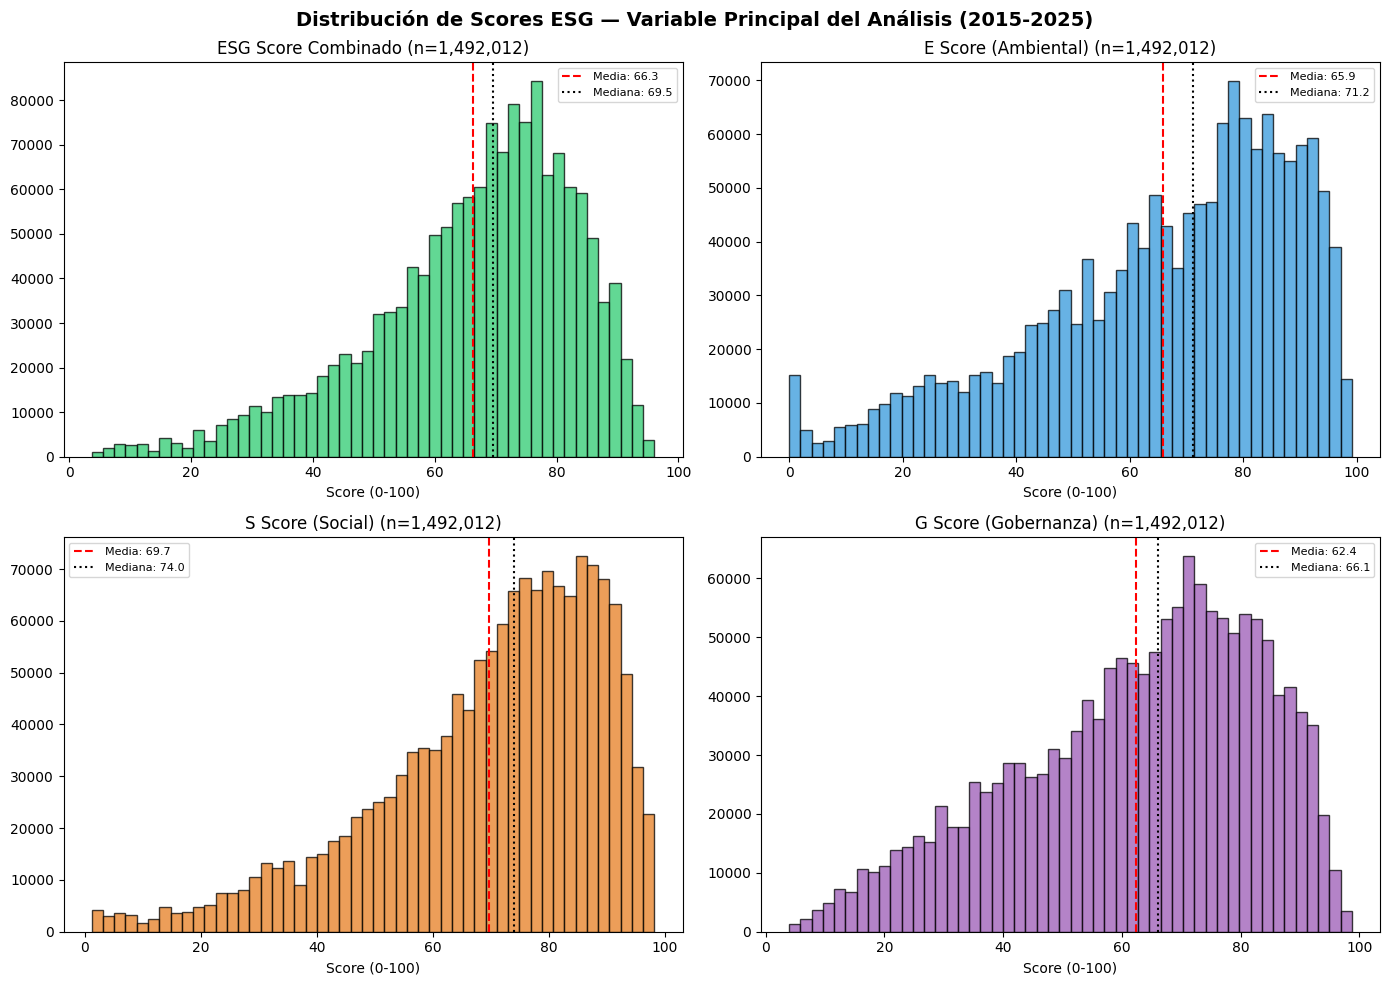

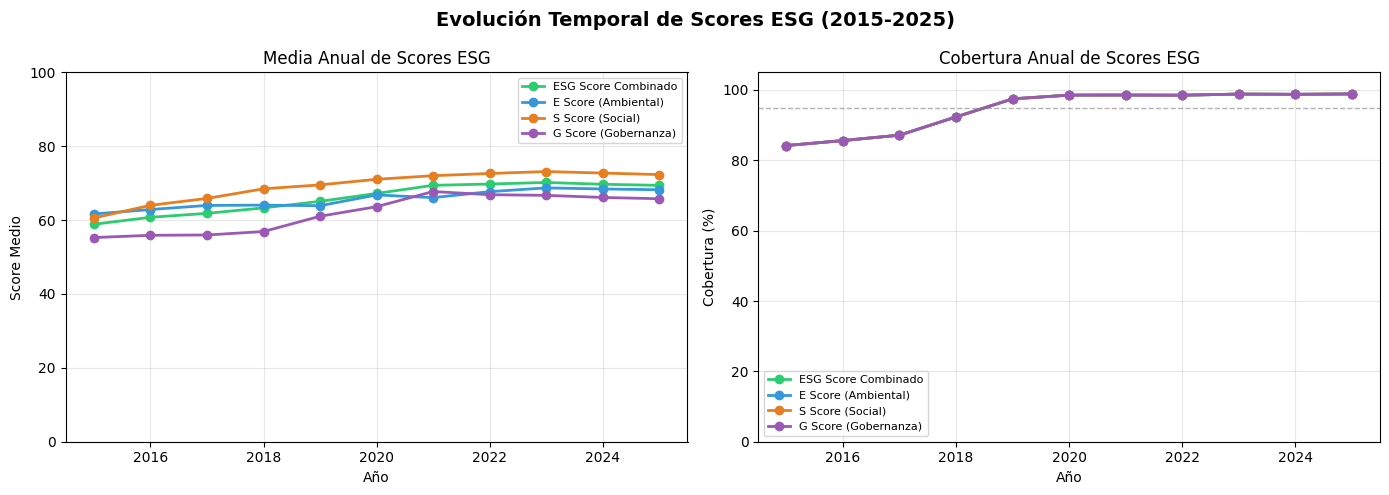

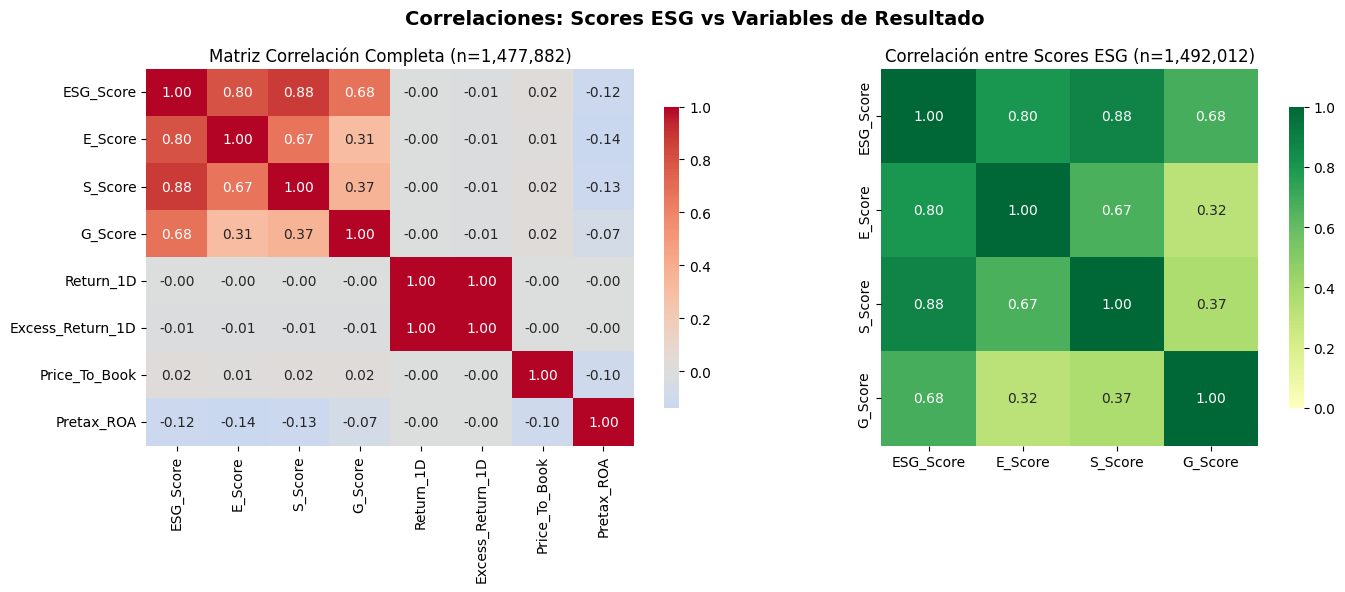

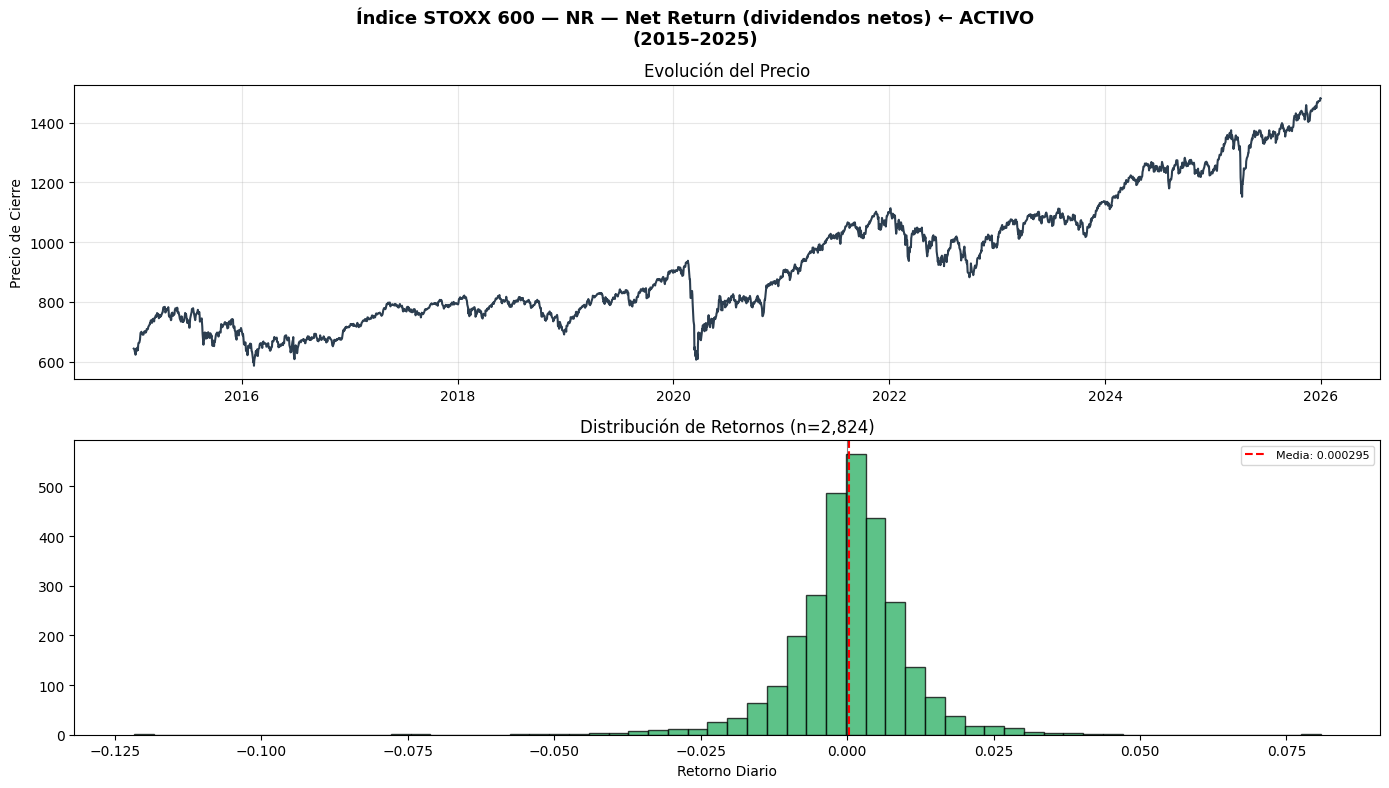


SECCIÓN 12: RESUMEN EJECUTIVO

ESTADO FINAL DE DATOS AL 2026-06-11
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PREGUNTA DE INVESTIGACIÓN:
   ¿Aportan valor los scores ESG a las empresas del STOXX 600?
   ¿Cuál de los componentes (E, S, G) tiene mayor impacto?

  📦 DATASET:
     • Consolidados:     11 años (2015-2025)
     • Total filas:      1,576,944
     • Empresas únicas:  598
     • Variables:        26
     • STOXX 600:        ✅ CARGADO (2825 obs)  [NR — Net Return (dividendos netos) ← ACTIVO]
     • Euríbor:          ✅ CARGADO (2,837 obs)

  🌿 VARIABLES DE INVESTIGACIÓN PRINCIPAL — SCORES ESG:
     • ESG_Score (combinado):   94.6%  ✅ Muy buena cobertura
     • E_Score (Ambiental):     94.6%  ✅ Muy buena cobertura
     • S_Score (Social):        94.6%  ✅ Muy buena cobertura
     • G_Score (Gobernanza):    94.6%  ✅ Muy buena cobertura
     → Cobertura insuficiente solo en 2015-2017 (84-87%) — mejora hasta >98% desde 2019

  📊 COBERTURA DE VARIABLES DE CONTROL:
    

In [4]:

# ==============================================================================
# SECCIÓN 9: ANÁLISIS DE COBERTURA GLOBAL Y ANUAL
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 9: ANÁLISIS DE COBERTURA")
print("─" * 90)

# Dataset completo (todos los años combinados)
df_all = pd.concat([consolidados[year] for year in YEARS], ignore_index=True)
df_all['Date'] = pd.to_datetime(df_all['Date'])
años = sorted(consolidados.keys())

print(f"\n📊 Dataset combinado: {len(df_all):,} filas × {df_all.shape[1]} columnas")
print(f"   Período: {df_all['Date'].min().date()} a {df_all['Date'].max().date()}")
print(f"   Empresas únicas: {df_all['RIC'].nunique()}")

# ── Cobertura global ──────────────────────────────────────────────────────────
# Variables ordenadas por relevancia para el análisis (ESG primero)
variables_clave = [
    # Variables de investigación principal (ESG)
    'ESG_Score', 'E_Score', 'S_Score', 'G_Score',
    # Retornos y mercado
    'Return_1D', 'Excess_Return_1D', 'Price_Close_EUR',
    # Fundamentales para modelos de control
    'Market_Cap_EUR', 'Total_Assets_EUR', 'Total_Debt_EUR',
    'Price_To_Book', 'Pretax_ROA', 'ROA_TTM',
    # Tasas
    'Euribor_1M', 'Euribor_1Y',
    # Auxiliares
    'Book_Value_Per_Share_EUR'
]

print(f"\n📈 COBERTURA GLOBAL (ordenada por relevancia para el análisis):")
print(f"\n{'Variable':<30} {'Válidos':>12} {'Faltantes':>12} {'Cobertura':>12}  {'Calidad'}")
print("-" * 82)

cobertura_global = {}
for var in variables_clave:
    if var in df_all.columns:
        validos   = df_all[var].notna().sum()
        faltantes = df_all[var].isna().sum()
        cob       = (validos / len(df_all)) * 100
        cobertura_global[var] = cob
        calidad   = '✅ Excelente' if cob >= 95 else '🟢 Muy buena' if cob >= 85 else '🟡 Buena' if cob >= 70 else '🔴 Limitada'
        print(f"{var:<30} {validos:>12,} {faltantes:>12,} {cob:>11.1f}%  {calidad}")

# ── Cobertura anual ────────────────────────────────────────────────────────────
print(f"\n📅 COBERTURA ANUAL — VARIABLES PRINCIPALES:")
print(f"   (ESG_Score · E_Score · S_Score · G_Score · Return_1D · Total_Assets_EUR · Pretax_ROA)\n")

cobertura_anual = {}
vars_criticas = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score',
                 'Return_1D', 'Total_Assets_EUR', 'Total_Debt_EUR', 'Pretax_ROA', 'ROA_TTM']

for year in años:
    df_y = consolidados[year]
    cobertura_anual[year] = {}
    print(f"  {year}: {len(df_y):,} filas | {df_y['RIC'].nunique()} RICs")
    for var in vars_criticas:
        if var in df_y.columns:
            cob = (df_y[var].notna().sum() / len(df_y)) * 100
            cobertura_anual[year][var] = cob
            print(f"     {var:<30} {cob:>6.1f}%")
# ==============================================================================
# SECCIÓN 10: DISPONIBILIDAD DE DATOS POR HIPÓTESIS
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 10: DISPONIBILIDAD DE DATOS POR HIPÓTESIS")
print("─" * 90)

# ── Cálculo de coberturas ──────────────────────────────────────────────────────
q_val        = df_all[(df_all['Market_Cap_EUR'].notna()) & (df_all['Total_Assets_EUR'].notna())].shape[0]
q_cob        = (q_val / len(df_all)) * 100
size_val     = df_all[df_all['Total_Assets_EUR'].notna()].shape[0]
size_cob     = (size_val / len(df_all)) * 100
lev_val      = df_all[(df_all['Total_Debt_EUR'].notna()) & (df_all['Total_Assets_EUR'].notna())].shape[0]
lev_cob      = (lev_val / len(df_all)) * 100
roa_pretax_n = df_all[df_all['Pretax_ROA'].notna()].shape[0]
roa_ttm_n    = df_all[df_all['ROA_TTM'].notna()].shape[0]
roa_comb     = df_all[(df_all['Pretax_ROA'].notna()) | (df_all['ROA_TTM'].notna())].shape[0]
roa_cob      = (roa_comb / len(df_all)) * 100
ret_cob      = df_all['Return_1D'].notna().sum() / len(df_all) * 100
exc_cob      = df_all['Excess_Return_1D'].notna().sum() / len(df_all) * 100
esg_cob      = df_all['ESG_Score'].notna().sum() / len(df_all) * 100
e_cob        = df_all['E_Score'].notna().sum() / len(df_all) * 100
s_cob        = df_all['S_Score'].notna().sum() / len(df_all) * 100
g_cob        = df_all['G_Score'].notna().sum() / len(df_all) * 100
ptb_cob      = df_all['Price_To_Book'].notna().sum() / len(df_all) * 100
eur_cob      = df_all['Euribor_1M'].notna().sum() / len(df_all) * 100
mktcap_cob   = df_all['Market_Cap_EUR'].notna().sum() / len(df_all) * 100
stoxx_obs    = len(df_stoxx) if df_stoxx is not None else 0

def check(cob, umbral=80):
    return "✅" if cob >= umbral else "⚠️  " if cob >= 50 else "❌"

# ── HIPÓTESIS 1 ────────────────────────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
H1 — ALPHA DE JENSEN (Carhart 4 Factores)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta : ¿El mercado europeo premia el desempeño ESG con una rentabilidad
           anormal positiva, ajustada por riesgo?
Modelo   : R_pt − R_ft = α_p + β(Rm−Rf) + s·SMB + h·HML + w·WML + ε_pt
Var. dep.: R_pt − R_ft  (exceso de retorno mensual del portafolio ESG)
Var. int.: α_p          (Alpha de Jensen — lo que queremos medir)
Controles: Rm−Rf, SMB (tamaño), HML (valor/PTB), WML (momentum)
Estrategia: Long Q1 (mejor ESG) − Short Q5 (peor ESG) | equal-weighted | rezago t−1
""")

stoxx_linea = f"{'✅' if stoxx_obs > 0 else '❌'} STOXX 600 [{STOXX_VERSION}]: {stoxx_obs:,} obs"
print(f"  COBERTURAS REQUERIDAS:")
print(f"  {check(ret_cob)}  Return_1D         (R_pt):     {ret_cob:.1f}%")
print(f"  {stoxx_linea}")
print(f"  {check(eur_cob)}  Euribor_1M        (R_ft):     {eur_cob:.1f}%")
print(f"  {check(mktcap_cob)}  Market_Cap_EUR    (SMB):     {mktcap_cob:.1f}%")
print(f"  {check(ptb_cob)}  Price_To_Book     (HML):     {ptb_cob:.1f}%")
print(f"  {check(esg_cob)}  ESG_Score lag t−1 (quintiles): {esg_cob:.1f}%")
print(f"  {check(e_cob)}  E_Score lag t−1              : {e_cob:.1f}%")
print(f"  {check(s_cob)}  S_Score lag t−1              : {s_cob:.1f}%")
print(f"  {check(g_cob)}  G_Score lag t−1              : {g_cob:.1f}%")
print(f"\n  Pendiente: agregar a mensual → construir portafolios y factores (Script 2.3 + 3.1)")

# ── HIPÓTESIS 2 ────────────────────────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
H2 — PREFERENCIAS DEL MERCADO Y VALORACIÓN (Q de Tobin)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta : ¿Qué pilar ESG (E, S o G) genera mayor valor corporativo en Europa?
Modelo   : TobinQ_it = β0 + β1·ESG_it + β2·Size_it + β3·Lev_it + β4·ROA_it + β5·Growth_it + μ_i + ε_it
Var. dep.: Q de Tobin = Market_Cap_EUR / Total_Assets_EUR
Var. int.: β1 (coeficiente ESG/E/S/G — se corre por separado para cada pilar)
Controles: Size = Ln(Total_Assets), Leverage = Debt/Assets, ROA, Growth anual de activos
Frecuencia: anual (una obs por empresa-año)
""")

print(f"  COBERTURAS REQUERIDAS:")
print(f"  {check(q_cob)}  Q de Tobin   (Market_Cap / Total_Assets):  {q_cob:.1f}%")
print(f"  {check(esg_cob)}  ESG_Score    (β1 — var. de interés):       {esg_cob:.1f}%")
print(f"  {check(e_cob)}  E_Score                                    {e_cob:.1f}%")
print(f"  {check(s_cob)}  S_Score                                    {s_cob:.1f}%")
print(f"  {check(g_cob)}  G_Score                                    {g_cob:.1f}%")
print(f"  {check(size_cob)}  Size         (Ln Total_Assets):             {size_cob:.1f}%")
print(f"  {check(lev_cob)}  Leverage     (Debt / Assets):               {lev_cob:.1f}%")
print(f"  {check(roa_cob)}  ROA Final    (Pretax_ROA | ROA_TTM):        {roa_cob:.1f}%")
print(f"  ❌  Growth Anual  (Δ Total_Assets):              NO DISPONIBLE — calcular en Script 2.3")

# ── HIPÓTESIS 3 ────────────────────────────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
H3 — RIESGO DINÁMICO (Markov-Switching CAPM)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pregunta : ¿El alto desempeño ESG reduce el beta sistemático en períodos de crisis?
Modelo   : R_pt − R_ft = α_St + β_St·(Rm−Rf) + ε_pt   donde St ∈ {calma, crisis}
Var. dep.: R_pt − R_ft  (exceso de retorno mensual del portafolio ESG)
Var. int.: β_S1 vs β_S2 (betas por régimen — test de Wald H0: β_S1 = β_S2)
Regímenes: detectados automáticamente por el modelo (endógenos — sin definir crisis a mano)
""")

print(f"  COBERTURAS REQUERIDAS:")
print(f"  {check(exc_cob)}  Excess_Return_1D  (R_pt − R_ft):  {exc_cob:.1f}%")
print(f"  {stoxx_linea}")
print(f"  {check(eur_cob)}  Euribor_1M        (R_ft):         {eur_cob:.1f}%")
print(f"  {check(esg_cob)}  ESG_Score         (quintiles):    {esg_cob:.1f}%")
n_meses = (df_all['Date'].max().year - df_all['Date'].min().year) * 12
print(f"  ✅  Período disponible: ~{n_meses} meses (mínimo recomendado: 60 meses para MS-CAPM)")
print(f"\n  Pendiente: portafolios mensuales Q1/Q5 de H1 → reusar directamente en H3 (Script 3.4)")

print("\n" + "─" * 90)

# ==============================================================================
# SECCIÓN 11: ESTADÍSTICAS DESCRIPTIVAS Y GRÁFICOS
# ==============================================================================

print("\n" + "─" * 90)
print("SECCIÓN 11: ESTADÍSTICAS DESCRIPTIVAS")
print("─" * 90)

# ── Estadísticas de scores ESG (variables principales) ───────────────────────
print(f"\n{'─'*60}")
print(f"  VARIABLES DE INVESTIGACIÓN — SCORES ESG")
print(f"{'─'*60}")
for nombre, col in [
    ('ESG_SCORE (Combinado)',  'ESG_Score'),
    ('E_SCORE (Ambiental)',    'E_Score'),
    ('S_SCORE (Social)',       'S_Score'),
    ('G_SCORE (Gobernanza)',   'G_Score'),
]:
    s = df_all[col].dropna()
    if len(s) > 0:
        print(f"\n📊 {nombre}")
        print(f"   n={len(s):,} | Media: {s.mean():.2f} | Desv: {s.std():.2f} | "
              f"P25: {s.quantile(0.25):.2f} | Mediana: {s.median():.2f} | "
              f"P75: {s.quantile(0.75):.2f} | Mín: {s.min():.2f} | Máx: {s.max():.2f}")

# ── Estadísticas de variables de resultado y control ─────────────────────────
print(f"\n{'─'*60}")
print(f"  VARIABLES DE RESULTADO Y CONTROL")
print(f"{'─'*60}")
for nombre, col in [
    ('RETORNOS (Return_1D)',      'Return_1D'),
    ('EXCESS RETURN',             'Excess_Return_1D'),
    ('PRICE-TO-BOOK (PTB)',       'Price_To_Book'),
    ('ROA PRETAX (%)',            'Pretax_ROA'),
    ('MARKET CAP (EUR)',          'Market_Cap_EUR'),
    ('TOTAL ASSETS (EUR)',        'Total_Assets_EUR'),
]:
    s = df_all[col].dropna()
    if len(s) > 0:
        print(f"\n📊 {nombre}")
        print(f"   n={len(s):,} | Media: {s.mean():.6g} | Desv: {s.std():.6g} | "
              f"Mín: {s.min():.6g} | Máx (P99): {s.quantile(0.99):.6g}")

# ── Gráfico 1: Distribuciones de los 4 scores ESG ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Scores ESG — Variable Principal del Análisis (2015-2025)',
             fontsize=14, fontweight='bold')

colores_esg = {'ESG_Score': '#2ecc71', 'E_Score': '#3498db', 'S_Score': '#e67e22', 'G_Score': '#9b59b6'}
titulos_esg = {'ESG_Score': 'ESG Score Combinado', 'E_Score': 'E Score (Ambiental)',
               'S_Score': 'S Score (Social)', 'G_Score': 'G Score (Gobernanza)'}

for ax, (col, color) in zip(axes.flatten(), colores_esg.items()):
    s = df_all[col].dropna()
    ax.hist(s, bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(s.mean(), color='red', linestyle='--', lw=1.5,
               label=f'Media: {s.mean():.1f}')
    ax.axvline(s.median(), color='black', linestyle=':', lw=1.5,
               label=f'Mediana: {s.median():.1f}')
    ax.set_xlabel('Score (0-100)')
    ax.set_title(f'{titulos_esg[col]} (n={len(s):,})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Gráfico 2: Evolución temporal de scores ESG ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución Temporal de Scores ESG (2015-2025)', fontsize=14, fontweight='bold')

medias_esg = {col: [] for col in ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']}
for year in años:
    df_y = consolidados[year]
    for col in medias_esg:
        medias_esg[col].append(df_y[col].mean() if col in df_y.columns else np.nan)

ax1 = axes[0]
for col, color in colores_esg.items():
    ax1.plot(años, medias_esg[col], marker='o', color=color, lw=2,
             label=titulos_esg[col])
ax1.set_xlabel('Año')
ax1.set_ylabel('Score Medio')
ax1.set_title('Media Anual de Scores ESG')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 100])

ax2 = axes[1]
for col, color in colores_esg.items():
    cobs = [cobertura_anual[y].get(col, 0) for y in años]
    ax2.plot(años, cobs, marker='o', color=color, lw=2, label=titulos_esg[col])
ax2.set_xlabel('Año')
ax2.set_ylabel('Cobertura (%)')
ax2.set_title('Cobertura Anual de Scores ESG')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])
ax2.axhline(95, color='gray', linestyle='--', lw=1, alpha=0.6)

plt.tight_layout()
plt.show()

# ── Gráfico 3: Correlaciones entre scores ESG y retornos ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlaciones: Scores ESG vs Variables de Resultado', fontsize=14, fontweight='bold')

vars_corr_esg = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score',
                 'Return_1D', 'Excess_Return_1D', 'Price_To_Book', 'Pretax_ROA']
df_corr = df_all[vars_corr_esg].dropna()

ax1 = axes[0]
if len(df_corr) > 100:
    sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, cbar_kws={'shrink': 0.8}, ax=ax1)
    ax1.set_title(f'Matriz Correlación Completa (n={len(df_corr):,})')

vars_solo_esg = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']
df_esg_only = df_all[vars_solo_esg].dropna()

ax2 = axes[1]
if len(df_esg_only) > 100:
    sns.heatmap(df_esg_only.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax2, square=True, cbar_kws={'shrink': 0.8},
                vmin=0, vmax=1)
    ax2.set_title(f'Correlación entre Scores ESG (n={len(df_esg_only):,})')

plt.tight_layout()
plt.show()


# ── Gráfico 4: STOXX 600 ──────────────────────────────────────────────────────
if df_stoxx is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'Índice STOXX 600 — {STOXX_VERSION}\n(2015–2025)',
                 fontsize=13, fontweight='bold')

    ax1 = axes[0]
    ax1.plot(df_stoxx['Date'], df_stoxx['Close_Price'], color='#2c3e50', lw=1.5)
    ax1.set_ylabel('Precio de Cierre')
    ax1.set_title('Evolución del Precio')
    ax1.grid(alpha=0.3)

    ax2 = axes[1]
    ret_s = df_stoxx['Return'].dropna()
    ax2.hist(ret_s, bins=60, color='#27ae60', edgecolor='black', alpha=0.75)
    ax2.axvline(ret_s.mean(), color='red', linestyle='--', lw=1.5,
                label=f'Media: {ret_s.mean():.6f}')
    ax2.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax2.set_xlabel('Retorno Diario')
    ax2.set_title(f'Distribución de Retornos (n={len(ret_s):,})')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# SECCIÓN 12: RESUMEN EJECUTIVO
# ==============================================================================

print("\n" + "=" * 90)
print("SECCIÓN 12: RESUMEN EJECUTIVO")
print("=" * 90)

# Variables de cobertura ESG (calculadas aquí por si la Sección 9 no está en memoria)
esg_score_cob = df_all['ESG_Score'].notna().sum() / len(df_all) * 100
e_score_cob   = df_all['E_Score'].notna().sum()   / len(df_all) * 100
s_score_cob   = df_all['S_Score'].notna().sum()   / len(df_all) * 100
g_score_cob   = df_all['G_Score'].notna().sum()   / len(df_all) * 100

stoxx_status = ("✅ CARGADO (%d obs)" % len(df_stoxx)) if df_stoxx is not None else "❌ NO CARGADO"

print(f"""
ESTADO FINAL DE DATOS AL {datetime.now().strftime('%Y-%m-%d')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PREGUNTA DE INVESTIGACIÓN:
   ¿Aportan valor los scores ESG a las empresas del STOXX 600?
   ¿Cuál de los componentes (E, S, G) tiene mayor impacto?

  📦 DATASET:
     • Consolidados:     {len(años)} años ({min(años)}-{max(años)})
     • Total filas:      {len(df_all):,}
     • Empresas únicas:  {df_all['RIC'].nunique()}
     • Variables:        {df_all.shape[1]}
     • STOXX 600:        {stoxx_status}  [{STOXX_VERSION}]
     • Euríbor:          ✅ CARGADO ({len(euribor):,} obs)

  🌿 VARIABLES DE INVESTIGACIÓN PRINCIPAL — SCORES ESG:
     • ESG_Score (combinado):   {esg_score_cob:.1f}%  ✅ Muy buena cobertura
     • E_Score (Ambiental):     {e_score_cob:.1f}%  ✅ Muy buena cobertura
     • S_Score (Social):        {s_score_cob:.1f}%  ✅ Muy buena cobertura
     • G_Score (Gobernanza):    {g_score_cob:.1f}%  ✅ Muy buena cobertura
     → Cobertura insuficiente solo en 2015-2017 (84-87%) — mejora hasta >98% desde 2019

  📊 COBERTURA DE VARIABLES DE CONTROL:
     • Precios/Retornos:     EXCELENTE (100%)
     • Fundamentales:        MUY BUENA (95.3%)
     • ROA (combinado):      {roa_cob:.1f}%

  ✅ RATIOS DERIVADOS CALCULABLES:
     • Q de Tobin:   {q_cob:.1f}%
     • Size:         {size_cob:.1f}%
     • Leverage:     {lev_cob:.1f}%
     • ROA Final:    {roa_cob:.1f}%

  ⚠️   LIMITACIONES:
     • Growth Anual: no calculable desde datos diarios (necesita datos anuales)
     • ESG en 2015-2017: cobertura menor (~84-87%) — 83 empresas adoptaron ESG
       gradualmente; muestra principal = 453 empresas con ESG en todo el período

  📋 PRÓXIMOS PASOS:
     → Script 2.3: Calcular ratios derivados + variable primer_año_esg + muestra 453 empresas
     → Script 2.4: Agregación mensual + portafolios long-short por quintil ESG/E/S/G
     → Script 2.5: Incorporar Growth anual

ESTADO: ✅ LISTO PARA INICIAR MODELADO
""")

print("=" * 90)
print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 90)




# **MODELADO DE DATOS**
---



In [5]:
  # ==============================================================================
  # ANÁLISIS: EMPRESAS SIN ESG_Score EN NINGÚN AÑO DEL PERÍODO (2015-2025)
  # ==============================================================================
  # Pegar en una celda de Colab después de ejecutar el Script 2 principal.
  # Requiere que el dict `consolidados` ya esté cargado en memoria.
  # ==============================================================================

  print("=" * 70)
  print("ANÁLISIS: EMPRESAS SIN ESG EN NINGÚN AÑO (2015-2025)")
  print("=" * 70)

  YEARS = range(2015, 2026)

  # Universo completo de Empresas en todo el período
  todos_rics = set()
  for year in YEARS:
      todos_rics.update(consolidados[year]['RIC'].unique())

  print(f"\nUniverso total de Empresas (2015-2025): {len(todos_rics)}")

  # Identificar cuáles nunca tuvieron ESG_Score en ningún año
  rics_nunca_esg = []
  for ric in sorted(todos_rics):
      tiene_esg = False
      for year in YEARS:
          df_y = consolidados[year]
          filas = df_y[df_y['RIC'] == ric]['ESG_Score']
          if len(filas) > 0 and filas.notna().any():
              tiene_esg = True
              break
      if not tiene_esg:
          rics_nunca_esg.append(ric)

  print(f"Empresas sin ESG_Score en ningún año: {len(rics_nunca_esg)}")
  print()

  # Detalle por Empresa: en qué años aparecen y con qué cobertura
  print(f"{'RIC':<20} {'Años en índice':<18} {'Nota'}")
  print("-" * 65)

  for ric in rics_nunca_esg:
    años_presentes = []
    for year in YEARS:
        df_y = consolidados[year]
        if ric in df_y['RIC'].values:
            años_presentes.append(year)

    if len(años_presentes) == 0:
        rango = "nunca"
    elif años_presentes == list(range(min(años_presentes), max(años_presentes)+1)):
        rango = f"{min(años_presentes)}-{max(años_presentes)}"
    else:
        rango = ", ".join(str(y) for y in años_presentes)

    if len(años_presentes) == 11:
        nota = "en índice todo el período, Refinitiv nunca la puntuó"
    elif len(años_presentes) >= 6:
        nota = f"{len(años_presentes)} años en índice, Refinitiv nunca la puntuó"
    else:
        nota = f"entrada tardía al índice ({len(años_presentes)} años), sin ESG"
    print(f"{ric:<20} {rango:<18} {nota}")

print()
print(f"→ Estas {len(rics_nunca_esg)} empresas se excluyen en cualquier muestra de análisis.")
print(f"  Refinitiv no las puntuó en ningún momento del período 2015-2025.")


ANÁLISIS: EMPRESAS SIN ESG EN NINGÚN AÑO (2015-2025)

Universo total de Empresas (2015-2025): 598
Empresas sin ESG_Score en ningún año: 9

RIC                  Años en índice     Nota
-----------------------------------------------------------------
ABVX.PA              2015-2025          en índice todo el período, Refinitiv nunca la puntuó
AMV0n.DE             2025-2025          entrada tardía al índice (1 años), sin ESG
BFT.WA               2015-2025          en índice todo el período, Refinitiv nunca la puntuó
CVC.AS               2024-2025          entrada tardía al índice (2 años), sin ESG
GALD.S               2024-2025          entrada tardía al índice (2 años), sin ESG
MICCT.AS             2025-2025          entrada tardía al índice (1 años), sin ESG
SUNN.S               2024-2025          entrada tardía al índice (2 años), sin ESG
TPRO.MI              2022-2025          entrada tardía al índice (4 años), sin ESG
VSURE.ST             2025-2025          entrada tardía al índice (

In [6]:
 # ==============================================================================
  # CONSTRUCCIÓN DEL DATAFRAME PRINCIPAL PARA ANÁLISIS
  # ==============================================================================
  # Partimos del dict `consolidados` ya cargado en memoria (Script 2).
  # El objetivo es construir un único DataFrame limpio con todas las observaciones
  # válidas y las variables necesarias para H1, H2 y H3.
  # ==============================================================================

  # ------------------------------------------------------------------------------
  # PASO 1: Definir las empresas a excluir
  # ------------------------------------------------------------------------------
  # Estas 9 empresas estuvieron en el STOXX 600 durante el período analizado
  # pero Refinitiv nunca les asignó puntuación ESG.
  # Como el análisis central gira en torno al impacto del ESG, incluirlas
  # introduciría observaciones sin variable de interés en todos los modelos.
  # La exclusión es estructural, no un filtro temporal.

RICS_SIN_ESG = {
      'ABVX.PA',   # en índice todo el período, nunca puntuada
      'AMV0n.DE',  # entrada tardía, nunca puntuada
      'BFT.WA',    # en índice todo el período, nunca puntuada
      'CVC.AS',    # entrada tardía, nunca puntuada
      'GALD.S',    # entrada tardía, nunca puntuada
      'MICCT.AS',  # además tiene solo 1 observación en 2025
      'SUNN.S',    # entrada tardía, nunca puntuada
      'TPRO.MI',   # en índice varios años, nunca puntuada
      'VSURE.ST',  # entrada tardía, nunca puntuada
  }

print("=" * 60)
print("PASO 1: Empresas excluidas por ausencia total de ESG")
print("=" * 60)
print(f"\nTotal a excluir: {len(RICS_SIN_ESG)}")
for ric in sorted(RICS_SIN_ESG):
      print(f"  • {ric}")


PASO 1: Empresas excluidas por ausencia total de ESG

Total a excluir: 9
  • ABVX.PA
  • AMV0n.DE
  • BFT.WA
  • CVC.AS
  • GALD.S
  • MICCT.AS
  • SUNN.S
  • TPRO.MI
  • VSURE.ST


In [7]:
  # ------------------------------------------------------------------------------
  # PASO 2: Combinar todos los años y excluir empresas sin ESG
  # ------------------------------------------------------------------------------
  # Apilamos los 11 consolidados anuales en un único DataFrame.
  # Luego eliminamos las filas correspondientes a los 9 RICs identificados.
  # Registramos el impacto de la exclusión para documentarlo.

import pandas as pd
import numpy as np

YEARS = range(2015, 2026)

  # Combinar todos los años
  df_main = pd.concat(
      [consolidados[year] for year in YEARS],
      ignore_index=True
  )
  df_main['Date'] = pd.to_datetime(df_main['Date'])

  filas_antes    = len(df_main)
  empresas_antes = df_main['RIC'].nunique()

  # Excluir los 9 RICs sin ESG
  df_main = df_main[~df_main['RIC'].isin(RICS_SIN_ESG)].copy()

  filas_despues    = len(df_main)
  empresas_despues = df_main['RIC'].nunique()

  print("=" * 60)
  print("PASO 2: Exclusión de empresas sin ESG")
  print("=" * 60)
  print(f"\n  Antes de exclusión:  {filas_antes:>10,} filas | {empresas_antes} empresas")
  print(f"  Filas eliminadas:    {filas_antes - filas_despues:>10,} filas | {empresas_antes - empresas_despues} empresas")
  print(f"  Después de exclusión:{filas_despues:>10,} filas | {empresas_despues} empresas")
  print(f"\n  Período: {df_main['Date'].min().date()} → {df_main['Date'].max().date()}")



PASO 2: Exclusión de empresas sin ESG

  Antes de exclusión:   1,576,944 filas | 598 empresas
  Filas eliminadas:         7,721 filas | 9 empresas
  Después de exclusión: 1,569,223 filas | 589 empresas

  Período: 2015-01-02 → 2025-12-31


In [8]:
  # ------------------------------------------------------------------------------
  # PASO 3: Calcular ratios derivados (variables de control para los modelos)
  # ------------------------------------------------------------------------------
  # Estos ratios no vienen directamente de Refinitiv sino que se calculan
  # a partir de las variables fundamentales ya disponibles en el DataFrame.

  # Q de Tobin: aproximación con datos de mercado disponibles
  # Se define como Market_Cap / Total_Assets.
  # Mide si el mercado valora la empresa por encima de sus activos contables.
  # Una Q > 1 indica que el mercado asigna un valor adicional (intangibles, marca, ESG).
df_main['Q_Tobin'] = df_main['Market_Cap_EUR'] / df_main['Total_Assets_EUR']

  # Size: logaritmo natural de los activos totales
  # Controla el efecto tamaño en los modelos de panel.
  # Usar logaritmo reduce la asimetría de la distribución de activos.
df_main['Size'] = np.log(df_main['Total_Assets_EUR'].replace(0, np.nan))

  # Leverage: deuda total sobre activos totales
  # Mide el nivel de endeudamiento de la empresa.
  # Control necesario en H2 porque empresas más endeudadas pueden tener Q más baja.
df_main['Leverage'] = df_main['Total_Debt_EUR'] / df_main['Total_Assets_EUR']

  # ROA Final: usamos Pretax_ROA como fuente principal.
  # Si no está disponible, tomamos ROA_TTM (Trailing Twelve Months).
  # Mide la rentabilidad sobre activos, control estándar en modelos de valuación.
df_main['ROA_Final'] = df_main['Pretax_ROA'].fillna(df_main['ROA_TTM'])

print("=" * 60)
print("PASO 3: Ratios derivados calculados")
print("=" * 60)

for nombre, col in [
      ('Q_Tobin   (Market_Cap / Total_Assets)', 'Q_Tobin'),
      ('Size      (Ln Total_Assets)',            'Size'),
      ('Leverage  (Total_Debt / Total_Assets)',  'Leverage'),
      ('ROA_Final (Pretax_ROA | ROA_TTM)',       'ROA_Final'),
  ]:
      validos  = df_main[col].notna().sum()
      cobertura = validos / len(df_main) * 100
      print(f"\n  {nombre}")
      print(f"    Válidos: {validos:,} ({cobertura:.1f}%)")
      print(f"    Media: {df_main[col].mean():.4f} | "
            f"Mediana: {df_main[col].median():.4f} | "
            f"Desv: {df_main[col].std():.4f}")



PASO 3: Ratios derivados calculados

  Q_Tobin   (Market_Cap / Total_Assets)
    Válidos: 1,502,776 (95.8%)
    Media: 1.4656 | Mediana: 0.7337 | Desv: 3.1707

  Size      (Ln Total_Assets)
    Válidos: 1,502,981 (95.8%)
    Media: 23.4320 | Mediana: 23.2093 | Desv: 1.7581

  Leverage  (Total_Debt / Total_Assets)
    Válidos: 1,502,935 (95.8%)
    Media: 0.2401 | Mediana: 0.2250 | Desv: 0.1597

  ROA_Final (Pretax_ROA | ROA_TTM)
    Válidos: 1,564,480 (99.7%)
    Media: 6.8550 | Mediana: 5.1593 | Desv: 12.3006


In [9]:
  # ------------------------------------------------------------------------------
  # PASO 4: Crear variable primer_año_esg
  # ------------------------------------------------------------------------------
  # Para cada empresa identificamos el primer año calendario en que tuvo
  # un ESG_Score válido. Luego creamos una dummy que vale 1 solo en ese año.
  #
  # ¿Para qué sirve?
  # Cuando una empresa obtiene su primer score ESG, ese evento en sí mismo
  # puede impactar el precio (señal al mercado de compromiso ESG).
  # Si no controlamos por esto, el modelo podría confundir el efecto del
  # NIVEL del score con el efecto del EVENTO de adoptarlo.
  # Incluir esta dummy en H2 (panel) aísla ambos efectos.

df_main['Year'] = df_main['Date'].dt.year

  # Primer año con ESG_Score para cada RIC
primer_esg = (
      df_main[df_main['ESG_Score'].notna()]
      .groupby('RIC')['Year']
      .min()
      .rename('primer_año_esg_valor')
  )
df_main = df_main.join(primer_esg, on='RIC')

  # Dummy: 1 solo en el año de primera aparición del ESG
df_main['primer_año_esg'] = (
      (df_main['Year'] == df_main['primer_año_esg_valor'])
      & df_main['ESG_Score'].notna()
  ).astype(int)

  # Columna auxiliar ya no necesaria
df_main.drop(columns=['primer_año_esg_valor'], inplace=True)

  print("=" * 60)
  print("PASO 4: Variable primer_año_esg creada")
  print("=" * 60)
  print(f"\n  Empresas con al menos 1 año de ESG: {primer_esg.shape[0]}")
  print(f"  Observaciones marcadas como primer año ESG: {df_main['primer_año_esg'].sum():,}")
  print(f"\n  Distribución por año de primera adopción:")
  adopcion = df_main[df_main['primer_año_esg'] == 1].groupby('Year')['RIC'].nunique()
  for year, n in adopcion.items():
      print(f"    {year}: {n} empresas obtuvieron su primer ESG_Score")


PASO 4: Variable primer_año_esg creada

  Empresas con al menos 1 año de ESG: 589
  Observaciones marcadas como primer año ESG: 141,660

  Distribución por año de primera adopción:
    2015: 453 empresas obtuvieron su primer ESG_Score
    2016: 11 empresas obtuvieron su primer ESG_Score
    2017: 15 empresas obtuvieron su primer ESG_Score
    2018: 41 empresas obtuvieron su primer ESG_Score
    2019: 29 empresas obtuvieron su primer ESG_Score
    2020: 10 empresas obtuvieron su primer ESG_Score
    2021: 12 empresas obtuvieron su primer ESG_Score
    2022: 2 empresas obtuvieron su primer ESG_Score
    2023: 7 empresas obtuvieron su primer ESG_Score
    2024: 6 empresas obtuvieron su primer ESG_Score
    2025: 3 empresas obtuvieron su primer ESG_Score


In [10]:
  # ------------------------------------------------------------------------------
  # PASO 5: Verificación del DataFrame principal
  # ------------------------------------------------------------------------------
  # Resumen del estado final del DataFrame antes de pasar al modelado.

  print("=" * 60)
  print("PASO 5: VERIFICACIÓN FINAL — df_main")
  print("=" * 60)

  print(f"\n  Dimensiones:  {df_main.shape[0]:,} filas × {df_main.shape[1]} columnas")
  print(f"  Período:      {df_main['Date'].min().date()} → {df_main['Date'].max().date()}")
  print(f"  Empresas:     {df_main['RIC'].nunique()}")

  print(f"\n  VARIABLES DE INVESTIGACIÓN (ESG):")
  for col in ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']:
      cob = df_main[col].notna().sum() / len(df_main) * 100
      print(f"    {col:<20} {cob:.1f}%")

  print(f"\n  VARIABLES DE RESULTADO:")
  for col in ['Return_1D', 'Excess_Return_1D', 'Q_Tobin']:
      cob = df_main[col].notna().sum() / len(df_main) * 100
      print(f"    {col:<20} {cob:.1f}%")

  print(f"\n  VARIABLES DE CONTROL:")
  for col in ['Size', 'Leverage', 'ROA_Final', 'Euribor_1M']:
      cob = df_main[col].notna().sum() / len(df_main) * 100
      print(f"    {col:<20} {cob:.1f}%")

  print(f"\n  VARIABLES AUXILIARES:")
  print(f"    Year                 {df_main['Year'].notna().sum() / len(df_main) * 100:.1f}%")
  print(f"    primer_año_esg       {df_main['primer_año_esg'].sum():,} obs marcadas como año de adopción")

  print(f"\n  Columnas disponibles:")
  print(f"    {list(df_main.columns)}")


PASO 5: VERIFICACIÓN FINAL — df_main

  Dimensiones:  1,569,223 filas × 32 columnas
  Período:      2015-01-02 → 2025-12-31
  Empresas:     589

  VARIABLES DE INVESTIGACIÓN (ESG):
    ESG_Score            95.1%
    E_Score              95.1%
    S_Score              95.1%
    G_Score              95.1%

  VARIABLES DE RESULTADO:
    Return_1D            100.0%
    Excess_Return_1D     100.0%
    Q_Tobin              95.8%

  VARIABLES DE CONTROL:
    Size                 95.8%
    Leverage             95.8%
    ROA_Final            99.7%
    Euribor_1M           99.9%

  VARIABLES AUXILIARES:
    Year                 100.0%
    primer_año_esg       141,660 obs marcadas como año de adopción

  Columnas disponibles:
    ['Date', 'RIC', 'Company_Name', 'Currency_Original', 'Reporting_Currency', 'Price_Close_EUR', 'Return_1D', 'Rf_daily', 'Excess_Return_1D', 'Market_Cap_EUR', 'Volume', 'ESG_Score', 'ESG_Combined_Score', 'E_Score', 'S_Score', 'G_Score', 'Total_Assets_EUR', 'Total_Debt_EUR'

In [11]:
df_main.head()

,Date,RIC,Company_Name,Currency_Original,Reporting_Currency,Price_Close_EUR,Return_1D,Rf_daily,Excess_Return_1D,Market_Cap_EUR,...,Pretax_ROA,ROA_TTM,Euribor_1M,Euribor_1Y,Q_Tobin,Size,Leverage,ROA_Final,Year,primer_año_esg
0,2015-01-02,A2.MI,A2A SpA,EUR,NaN,0.8355,-0.0024,0.000013,-0.002413,2.617542e+09,...,1.5087,NaN,0.00016,0.00323,0.253319,23.058608,0.392529,1.5087,2015,1
1,2015-01-02,AAK.ST,AAK AB (publ),EUR,NaN,7.2840,-0.0050,0.000013,-0.005013,1.823286e+09,...,10.2319,7.8645,0.00016,0.00323,NaN,NaN,NaN,10.2319,2015,0
2,2015-01-02,AAL.L,Anglo American PLC,EUR,NaN,14.3705,-0.0129,0.000013,-0.012913,2.113631e+10,...,-0.3776,NaN,0.00016,0.00323,0.387345,24.722698,0.280791,-0.3776,2015,1
3,2015-01-02,AALB.AS,Aalberts NV,EUR,NaN,24.3600,-0.0071,0.000013,-0.007113,2.693731e+09,...,9.0613,NaN,0.00016,0.00323,1.055496,21.660182,0.284158,9.0613,2015,1
4,2015-01-02,ABDN.L,Aberdeen Group PLC,EUR,NaN,5.2012,-0.0010,0.000013,-0.001013,1.222201e+10,...,0.3422,NaN,0.00016,0.00323,0.046631,26.291993,0.035845,0.3422,2015,1


# **CONSTRUCCION DE DATAFRAMES PARA ANALISIS**

---



```
   **DECISIÓN METODOLÓGICA:**
   Se crean AMBAS versiones (raw + winsorizada) porque los outliers en este contexto pueden ser EVIDENCIA valiosa
   (adopción ESG temprana → extraordinarios retornos) y no necesariamente ruido a eliminar.
   El análisis de sensibilidad permite determinar si los hallazgos dependen de los casos extremos.

```



In [12]:
# ==============================================================================
# SCRIPT 2.3: PREPARACIÓN DE DATOS PARA H1, H2, H3
# Protocolo de análisis de sensibilidad y robustez
# ==============================================================================
#
# FILOSOFÍA METODOLÓGICA (adoptada tras análisis de outliers):
#
# Los datos muestran que los outliers en Q_Tobin y ROA corresponden a empresas
# reales con modelos de negocio estructuralmente distintos (tech de activos
# intangibles, finanzas, lujo). NO son errores de datos ni evidencia de
# impacto ESG extraordinario — de hecho tienen ESG ~15 puntos MENOR que el
# promedio global. Por tanto:
#
# PROTOCOLO ADOPTADO:
#   1. Modelo PRINCIPAL: datos RAW (sin winsorizar Q_Tobin ni ROA)
#   2. Modelo SENSIBILIDAD: datos winsorizados P1-P99 en todas las variables
#   3. Comparación de coeficientes β_ESG entre ambas especificaciones
#   4. Diagnóstico: Cook, leverage, DFBETAS en Scripts 3.2 y 3.3
#
# LIMPIEZA SELECTIVA (sí aplicada en AMBAS versiones):
#   - Price_To_Book: mín detectado = -4365. No es evidencia económica real,
#     corresponde a patrimonio neto negativo extremo → winsorizar P1-P99
#   - Growth: mediana=3% pero desv.est.=1000%. Caída brutal que indica
#     fusiones, spin-offs, recapitalizaciones → eventos que rompen paneles
#     → winsorizar P1-P99
#
# REFERENCIAS METODOLÓGICAS:
#   - Cook (1977): distancia de Cook para detectar observaciones influyentes
#   - Belsley, Kuh & Welsch (1980): leverage y DFBETAS
#   - Verbeek (2004): panel data, diagnóstico de especificación
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SCRIPT 2.3: PREPARACIÓN DE DATOS — PROTOCOLO DE ROBUSTEZ")
print("=" * 80)
print(f"\nInicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

if 'df_main' not in locals():
    print("❌ Error: ejecuta primero los Bloques 1-5 de construcción de df_main")
    exit()

YEARS = range(2015, 2026)

# ==============================================================================
# SECCIÓN 1: LIMPIEZA SELECTIVA — Solo donde está justificado
# ==============================================================================

print("─" * 80)
print("SECCIÓN 1: LIMPIEZA SELECTIVA (Price_To_Book y Growth)")
print("─" * 80)

print("""
Se aplica limpieza SOLO a dos variables donde los extremos no representan
fenómenos económicos válidos para esta investigación:

  Price_To_Book < 0:  patrimonio neto negativo → puede ser técnico/transitorio
                      pero distorsiona quintiles de valor en HML
  Price_To_Book extremo: mín = -4365, P1 = 0.32 → el rango inferior es ruido

  Growth > P99:       fusiones y adquisiciones → cambio de estructura, no
                      crecimiento orgánico; se controla con winsorización
  Growth < P1:        spin-offs, desinversiones masivas → mismo argumento

Q_Tobin y ROA NO se tocan aquí. Son reales y serán testeados en sensibilidad.
""")

df_clean = df_main.copy()

# ── Price_To_Book ─────────────────────────────────────────────────────────────
ptb_p1  = df_clean['Price_To_Book'].quantile(0.01)
ptb_p99 = df_clean['Price_To_Book'].quantile(0.99)

casos_ptb = ((df_clean['Price_To_Book'] < ptb_p1) |
             (df_clean['Price_To_Book'] > ptb_p99)).sum()

df_clean['Price_To_Book'] = df_clean['Price_To_Book'].clip(ptb_p1, ptb_p99)

print(f"Price_To_Book:")
print(f"  Rango original: [{df_main['Price_To_Book'].min():.4f}, {df_main['Price_To_Book'].max():.4f}]")
print(f"  Rango limpio:   [{ptb_p1:.4f}, {ptb_p99:.4f}]")
print(f"  Filas afectadas: {casos_ptb:,}")

# ==============================================================================
# SECCIÓN 2: df_monthly_raw Y df_monthly_w
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 2: CONSTRUCCIÓN DE df_monthly")
print("─" * 80)

print("""
VERSIÓN RAW (modelo principal):
  Variables como están en df_clean — Q_Tobin y ROA sin recortar.
  Es el modelo que se presenta en los resultados principales de H1.

VERSIÓN WINSORIZADA (sensibilidad):
  Todas las variables numéricas recortadas a P1-P99.
  Se usa para verificar que los hallazgos de H1 no dependen de extremos.

REGLA DE INTERPRETACIÓN (se aplicará en Scripts 3.2 y 3.3):
  Si |β_ESG_raw - β_ESG_wins| / |β_ESG_raw| < 0.10 → hallazgo robusto
  Si la diferencia > 0.30 → los extremos importan y hay que reportarlo
  Si el signo cambia → hallazgo frágil, requiere análisis adicional
""")

df_monthly = df_clean.copy()
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'])
df_monthly['YearMonth'] = df_monthly['Date'].dt.to_period('M')

# ── Retorno mensual por empresa ────────────────────────────────────────────────
retorno_mensual = (
    df_monthly
    .groupby(['RIC', 'YearMonth'])['Return_1D']
    .apply(lambda x: (1 + x.dropna()).prod() - 1 if x.notna().any() else np.nan)
    .reset_index()
    .rename(columns={'Return_1D': 'Return_monthly'})
)

# ── Rf mensual ────────────────────────────────────────────────────────────────
rf_mensual = (
    df_monthly
    .groupby('YearMonth')['Euribor_1M']
    .mean()
    .reset_index()
    .rename(columns={'Euribor_1M': 'Rf_monthly'})
)

# ── ESG rezagado (t-1): REGLA OBLIGATORIA anti look-ahead bias ────────────────
# Se toma el ESG_Score del mes anterior, no del mes actual.
# Si se usara el score del mismo mes, el modelo "sabría" información
# que el mercado todavía no tiene al tomar la decisión de inversión.
esg_data = (
    df_monthly[['RIC', 'YearMonth', 'ESG_Score', 'E_Score', 'S_Score', 'G_Score']]
    .drop_duplicates(subset=['RIC', 'YearMonth'])
    .sort_values(['RIC', 'YearMonth'])
    .reset_index(drop=True)
)

for col in ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']:
    esg_data[f'{col}_lag1'] = esg_data.groupby('RIC')[col].shift(1)

esg_rezagado = esg_data[
    ['RIC', 'YearMonth', 'ESG_Score_lag1', 'E_Score_lag1', 'S_Score_lag1', 'G_Score_lag1']
].copy()

# ── Controles: último valor del mes por empresa ────────────────────────────────
controles = (
    df_monthly
    .groupby(['RIC', 'YearMonth'])[
        ['Market_Cap_EUR', 'Total_Assets_EUR', 'Q_Tobin',
         'Size', 'Leverage', 'ROA_Final', 'Price_To_Book', 'primer_año_esg']
    ]
    .last()
    .reset_index()
)

# ── Combinar en df_monthly_raw ─────────────────────────────────────────────────
df_monthly_raw = (
    retorno_mensual
    .merge(rf_mensual,    on='YearMonth',         how='left')
    .merge(esg_rezagado,  on=['RIC', 'YearMonth'], how='left')
    .merge(controles,     on=['RIC', 'YearMonth'], how='left')
)
df_monthly_raw['Date'] = df_monthly_raw['YearMonth'].dt.to_timestamp()
df_monthly_raw['Excess_Return_monthly'] = df_monthly_raw['Return_monthly'] - df_monthly_raw['Rf_monthly']

# ── df_monthly_w: winsorización completa ──────────────────────────────────────
df_monthly_w = df_monthly_raw.copy()

vars_wins_monthly = ['Q_Tobin', 'Size', 'Leverage', 'ROA_Final']
for var in vars_wins_monthly:
    if var in df_monthly_w.columns:
        p1  = df_monthly_w[var].quantile(0.01)
        p99 = df_monthly_w[var].quantile(0.99)
        df_monthly_w[var] = df_monthly_w[var].clip(p1, p99)

print(f"✅ df_monthly_raw (modelo principal H1):")
print(f"   {df_monthly_raw.shape[0]:,} filas × {df_monthly_raw.shape[1]} columnas")
print(f"   Período: {df_monthly_raw['Date'].min().date()} → {df_monthly_raw['Date'].max().date()}")
print(f"   Empresas: {df_monthly_raw['RIC'].nunique()}")

print(f"\n   Cobertura:")
for col in ['Return_monthly', 'Excess_Return_monthly', 'Rf_monthly',
            'ESG_Score_lag1', 'E_Score_lag1', 'S_Score_lag1', 'G_Score_lag1',
            'Size', 'Leverage', 'ROA_Final', 'Q_Tobin']:
    if col in df_monthly_raw.columns:
        cob = df_monthly_raw[col].notna().sum() / len(df_monthly_raw) * 100
        print(f"     {col:<30} {cob:>6.1f}%")

print(f"\n✅ df_monthly_w (sensibilidad H1): mismas dimensiones, Q_Tobin y ROA winsorizados")

# ==============================================================================
# SECCIÓN 3: df_annual_raw Y df_annual_w
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 3: CONSTRUCCIÓN DE df_annual")
print("─" * 80)

print("""
Para H2 (panel Q de Tobin) se necesita UNA observación por empresa por año.
Growth se calcula aquí y se winsoriza en AMBAS versiones porque:
  - Desv.est. = 1000% vs mediana = 3%
  - Los eventos extremos (M&A, spin-offs) rompen la regresión de panel
  - NO es información sobre ESG → es ruido estructural legítimo de eliminar
""")

df_anual_prep = df_clean.copy()
df_anual_prep['Year'] = df_anual_prep['Date'].dt.year

# Agregaciones anuales
df_annual_raw = (
    df_anual_prep
    .groupby(['RIC', 'Year'])
    .agg(
        Q_Tobin          = ('Q_Tobin',          'last'),
        Size             = ('Size',              'mean'),
        Leverage         = ('Leverage',          'mean'),
        ROA_Final        = ('ROA_Final',         'mean'),
        ESG_Score        = ('ESG_Score',         'mean'),
        E_Score          = ('E_Score',           'mean'),
        S_Score          = ('S_Score',           'mean'),
        G_Score          = ('G_Score',           'mean'),
        Total_Assets_EUR = ('Total_Assets_EUR',  'last'),
        primer_año_esg   = ('primer_año_esg',    'max'),
    )
    .reset_index()
)

# Calcular Growth anual
df_annual_raw = df_annual_raw.sort_values(['RIC', 'Year']).reset_index(drop=True)
df_annual_raw['Assets_lag1'] = df_annual_raw.groupby('RIC')['Total_Assets_EUR'].shift(1)
df_annual_raw['Growth'] = (
    (df_annual_raw['Total_Assets_EUR'] - df_annual_raw['Assets_lag1']) /
    df_annual_raw['Assets_lag1']
)
df_annual_raw.drop(columns=['Assets_lag1'], inplace=True)

# ESG rezagado anual (t-1)
for col in ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']:
    df_annual_raw[f'{col}_lag1'] = df_annual_raw.groupby('RIC')[col].shift(1)

# Winsorizar Growth en RAW (justificado: rompe panel)
growth_p1  = df_annual_raw['Growth'].quantile(0.01)
growth_p99 = df_annual_raw['Growth'].quantile(0.99)
growth_extremos = ((df_annual_raw['Growth'] < growth_p1) |
                   (df_annual_raw['Growth'] > growth_p99)).sum()

df_annual_raw['Growth'] = df_annual_raw['Growth'].clip(growth_p1, growth_p99)

print(f"Growth winsorizado en ambas versiones:")
print(f"  P1 = {growth_p1:.4f} ({growth_p1*100:.2f}%)")
print(f"  P99 = {growth_p99:.4f} ({growth_p99*100:.2f}%)")
print(f"  Observaciones afectadas: {growth_extremos:,}")

# df_annual_w: winsorización adicional de Q_Tobin, Leverage, ROA
df_annual_w = df_annual_raw.copy()
vars_wins_annual = ['Q_Tobin', 'Leverage', 'ROA_Final']
for var in vars_wins_annual:
    if var in df_annual_w.columns:
        p1  = df_annual_w[var].quantile(0.01)
        p99 = df_annual_w[var].quantile(0.99)
        df_annual_w[var] = df_annual_w[var].clip(p1, p99)

print(f"\n✅ df_annual_raw (modelo principal H2):")
print(f"   {df_annual_raw.shape[0]:,} filas × {df_annual_raw.shape[1]} columnas")
print(f"   Período: {df_annual_raw['Year'].min()} → {df_annual_raw['Year'].max()}")
print(f"   Empresas: {df_annual_raw['RIC'].nunique()}")

print(f"\n   Cobertura:")
for col in ['Q_Tobin', 'Size', 'Leverage', 'ROA_Final', 'Growth',
            'ESG_Score_lag1', 'E_Score_lag1', 'S_Score_lag1', 'G_Score_lag1']:
    if col in df_annual_raw.columns:
        cob = df_annual_raw[col].notna().sum() / len(df_annual_raw) * 100
        print(f"     {col:<30} {cob:>6.1f}%")

print(f"\n✅ df_annual_w (sensibilidad H2): mismas dimensiones, Q_Tobin y ROA winsorizados")

# ==============================================================================
# SECCIÓN 4: FUNCIONES DE DIAGNÓSTICO (para usar en Scripts 3.2 y 3.3)
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 4: FUNCIONES DE DIAGNÓSTICO")
print("─" * 80)

print("""
Las siguientes funciones se usarán en Scripts 3.2 (H1) y 3.3 (H2) para:
  1. Calcular distancia de Cook: identifica observaciones que cambian
     significativamente los coeficientes si se eliminan
  2. Calcular leverage (hat values): identifica puntos de influencia extrema
  3. Calcular DFBETAS: cuánto cambia β_ESG si se elimina cada observación
  4. Comparar coeficientes raw vs winsorizado
""")

from sklearn.linear_model import LinearRegression

def calcular_cook_distance(y, X):
    """
    Calcula la distancia de Cook para cada observación.
    Umbral estándar: Cook > 4/n indica observación influyente.
    """
    n, k = X.shape
    modelo = LinearRegression().fit(X, y)
    y_pred = modelo.predict(X)
    residuos = y - y_pred
    mse = np.sum(residuos**2) / (n - k - 1)

    H = X @ np.linalg.pinv(X.T @ X) @ X.T  # Matriz hat
    leverage = np.diag(H)

    cook = (residuos**2 * leverage) / (k * mse * (1 - leverage)**2)
    return cook, leverage


def comparar_coeficientes(beta_raw, beta_wins, nombre_var='β_ESG'):
    """
    Compara coeficientes entre versión raw y winsorizada.
    Devuelve % de variación y veredicto de robustez.
    """
    if beta_raw == 0:
        return None, "No calculable (beta raw = 0)"

    variacion = abs(beta_raw - beta_wins) / abs(beta_raw) * 100

    if variacion < 10:
        veredicto = "✅ ROBUSTO (variación < 10%)"
    elif variacion < 30:
        veredicto = "⚠️  MODERADO (variación 10-30%)"
    else:
        veredicto = "🔴 FRÁGIL (variación > 30%)"

    print(f"\n  Comparación {nombre_var}:")
    print(f"    β raw:        {beta_raw:.6f}")
    print(f"    β winsorizado:{beta_wins:.6f}")
    print(f"    Variación:    {variacion:.1f}%")
    print(f"    Veredicto:    {veredicto}")

    return variacion, veredicto


def resumen_influyentes(cook_distances, leverage, ric_index, umbral_cook=None):
    """
    Identifica y reporta observaciones influyentes.
    """
    n = len(cook_distances)
    if umbral_cook is None:
        umbral_cook = 4 / n

    influyentes_cook = np.where(cook_distances > umbral_cook)[0]
    influyentes_lev  = np.where(leverage > 2 * np.mean(leverage))[0]
    ambos = np.intersect1d(influyentes_cook, influyentes_lev)

    print(f"\n  Observaciones influyentes:")
    print(f"    Por Cook (> 4/n = {umbral_cook:.4f}): {len(influyentes_cook)}")
    print(f"    Por leverage (> 2×media):             {len(influyentes_lev)}")
    print(f"    Influyentes en AMBOS criterios:        {len(ambos)}")

    if len(ambos) > 0 and ric_index is not None:
        print(f"    Top casos (ambos criterios):")
        for idx in ambos[:5]:
            print(f"      {ric_index[idx]} — Cook: {cook_distances[idx]:.4f}")

    return influyentes_cook, influyentes_lev, ambos

print("  ✅ Función calcular_cook_distance() → disponible")
print("  ✅ Función comparar_coeficientes()   → disponible")
print("  ✅ Función resumen_influyentes()      → disponible")
print("\n  Uso en Scripts 3.2/3.3:")
print("    cook, lev = calcular_cook_distance(y, X)")
print("    comparar_coeficientes(beta_raw, beta_wins, 'β_ESG_Score')")
print("    resumen_influyentes(cook, lev, df['RIC'].values)")

# ==============================================================================
# SECCIÓN 5: RESUMEN FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL — DATASETS DISPONIBLES")
print("=" * 80)

print(f"""
─────────────────────────────────────────────────────────────────────
PARA H1 (MODELO CARHART 4 FACTORES):
─────────────────────────────────────────────────────────────────────

  df_monthly_raw  → MODELO PRINCIPAL
    {df_monthly_raw.shape[0]:,} filas × {df_monthly_raw.shape[1]} columnas
    Q_Tobin y ROA sin winsorizar
    ESG en rezago t-1 (anti look-ahead bias)
    Scores disponibles: ESG_Score, E_Score, S_Score, G_Score (todos lag1)

  df_monthly_w    → ANÁLISIS DE SENSIBILIDAD
    Mismas dimensiones
    Q_Tobin, Size, Leverage, ROA winsorizados a P1-P99

─────────────────────────────────────────────────────────────────────
PARA H2 (PANEL Q DE TOBIN):
─────────────────────────────────────────────────────────────────────

  df_annual_raw   → MODELO PRINCIPAL
    {df_annual_raw.shape[0]:,} filas × {df_annual_raw.shape[1]} columnas
    Growth winsorizado (justificado: M&A rompe panel)
    Q_Tobin y ROA sin winsorizar
    primer_año_esg como variable de control

  df_annual_w     → ANÁLISIS DE SENSIBILIDAD
    Mismas dimensiones
    Q_Tobin, Leverage, ROA también winsorizados

─────────────────────────────────────────────────────────────────────
FUNCIONES DE DIAGNÓSTICO (disponibles en memoria):
─────────────────────────────────────────────────────────────────────
  calcular_cook_distance()   → distancia de Cook + leverage
  comparar_coeficientes()    → robustez raw vs winsorizado
  resumen_influyentes()      → identificar casos problemáticos

─────────────────────────────────────────────────────────────────────
PRÓXIMO PASO:
─────────────────────────────────────────────────────────────────────
  Script 3.1: Construir factores SMB, HML, WML desde df_monthly_raw
  Script 3.2: Regresiones H1 — alpha de Jensen
              → correr raw, correr wins, comparar_coeficientes()
  Script 3.3: Regresiones H2 — panel Q de Tobin
              → correr raw, correr wins, Cook distance, comparar
""")

print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

SCRIPT 2.3: PREPARACIÓN DE DATOS — PROTOCOLO DE ROBUSTEZ

Inicio: 2026-06-11 20:54:38

────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: LIMPIEZA SELECTIVA (Price_To_Book y Growth)
────────────────────────────────────────────────────────────────────────────────

Se aplica limpieza SOLO a dos variables donde los extremos no representan
fenómenos económicos válidos para esta investigación:

  Price_To_Book < 0:  patrimonio neto negativo → puede ser técnico/transitorio
                      pero distorsiona quintiles de valor en HML
  Price_To_Book extremo: mín = -4365, P1 = 0.32 → el rango inferior es ruido

  Growth > P99:       fusiones y adquisiciones → cambio de estructura, no
                      crecimiento orgánico; se controla con winsorización
  Growth < P1:        spin-offs, desinversiones masivas → mismo argumento

Q_Tobin y ROA NO se tocan aquí. Son reales y serán testeados en sensibilidad.

Price_To_Book:
  Rango original: [-4365.53

# **CONSTRUCCIÓN DE FACTORES CARHART 4-FACTOR MODEL**

In [13]:
# ==============================================================================
# SCRIPT 3.1: CONSTRUCCIÓN DE FACTORES CARHART 4-FACTOR MODEL
# Universo:   STOXX 600 (misma muestra del estudio — sin contaminar con datos externos)
# Frecuencia: mensual
# Ponderación: value-weighted (por capitalización) para los factores FF
#              equal-weighted (1/N) para los portafolios ESG quintiles
# ==============================================================================
#
# FACTORES A CONSTRUIR:
#
#   Rm - Rf  = Retorno mensual STOXX 600 (mercado) menos Euribor_1M
#
#   SMB      = Small Minus Big (factor tamaño)
#              Metodología 6 portafolios Fama-French (1993):
#              2 grupos tamaño (S, B) × 3 grupos BtM (H, M, L)
#              SMB = (SH + SM + SL)/3 − (BH + BM + BL)/3
#
#   HML      = High Minus Low (factor valor, Book-to-Market)
#              Mismos 6 portafolios:
#              HML = (SH + BH)/2 − (SL + BL)/2
#
#   WML      = Winners Minus Losers (factor momentum, Carhart 1997)
#              Momentum = retorno acumulado meses t-12 a t-2 (excluye t-1)
#              Top 30% = Winners, Bottom 30% = Losers
#              WML = Ret_Winners − Ret_Losers (value-weighted)
#
# REFERENCIA: Fama & French (1993), Carhart (1997)
# REPLICACIÓN: Construidos desde la misma muestra del estudio para evitar
#              inconsistencias entre el universo de factores y el universo
#              de los portafolios ESG (problema habitual al usar datos Ken French).
#
# REQUIERE: df_monthly_raw y df_stoxx cargados en memoria
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SCRIPT 3.1: FACTORES CARHART 4-FACTOR MODEL")
print("=" * 80)
print(f"\nInicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

for var, name in [('df_monthly_raw', 'Script 2.3'), ('df_stoxx', 'Script 2 principal')]:
    if var not in dir():
        print(f"❌ Error: '{var}' no está en memoria. Ejecuta {name} primero.")
        raise SystemExit



SCRIPT 3.1: FACTORES CARHART 4-FACTOR MODEL

Inicio: 2026-06-11 20:55:15



## SECCIÓN 1:
*RETORNO MENSUAL DEL MERCADO (Rm) y PRIMA DE MERCADO (Rm - Rf)*

---



In [14]:
# ==============================================================================
# SECCIÓN 1: RETORNO MENSUAL DEL MERCADO (Rm) y PRIMA DE MERCADO (Rm - Rf)
# ==============================================================================

print("─" * 80)
print("SECCIÓN 1: Rm mensual y prima de mercado (Rm - Rf)")
print("─" * 80)

df_stoxx_work = df_stoxx.copy()
df_stoxx_work['Date'] = pd.to_datetime(df_stoxx_work['Date'])
df_stoxx_work['YearMonth'] = df_stoxx_work['Date'].dt.to_period('M')

# Retorno mensual del STOXX 600: producto de retornos diarios
# El campo 'Return' viene del CSV como retorno diario decimal
col_ret_stoxx = 'Return'
col_close_stoxx = 'Close_Price'

rm_monthly = (
    df_stoxx_work
    .groupby('YearMonth')[col_ret_stoxx]
    .apply(lambda x: (1 + x.dropna()).prod() - 1 if x.notna().any() else np.nan)
    .reset_index()
    .rename(columns={col_ret_stoxx: 'Rm_monthly'})
)

# Euribor mensual (ya disponible en df_monthly_raw como Rf_monthly)
rf_monthly = (
    df_monthly_raw[['YearMonth', 'Rf_monthly']]
    .drop_duplicates('YearMonth')
    .copy()
)

# Prima de mercado
mkt_factor = rm_monthly.merge(rf_monthly, on='YearMonth', how='inner')
mkt_factor['Rm_Rf'] = mkt_factor['Rm_monthly'] - mkt_factor['Rf_monthly']
mkt_factor['Date'] = mkt_factor['YearMonth'].dt.to_timestamp()

print(f"✅ Prima de mercado (Rm - Rf):")
print(f"   Meses disponibles:  {len(mkt_factor)}")
print(f"   Período:            {mkt_factor['Date'].min().date()} → {mkt_factor['Date'].max().date()}")
print(f"   Media mensual:      {mkt_factor['Rm_Rf'].mean()*100:.3f}%")
print(f"   Desv. est.:         {mkt_factor['Rm_Rf'].std()*100:.3f}%")
print(f"   Mín / Máx:          {mkt_factor['Rm_Rf'].min()*100:.2f}% / {mkt_factor['Rm_Rf'].max()*100:.2f}%")

────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: Rm mensual y prima de mercado (Rm - Rf)
────────────────────────────────────────────────────────────────────────────────
✅ Prima de mercado (Rm - Rf):
   Meses disponibles:  132
   Período:            2015-01-01 → 2025-12-01
   Media mensual:      0.022%
   Desv. est.:         4.234%
   Mín / Máx:          -15.81% / 14.18%


## SECCIÓN 2:
*PREPARACIÓN DE LA MATRIZ DE RETORNOS Y CARACTERÍSTICAS*


---




In [15]:
# ==============================================================================
# SECCIÓN 2: PREPARACIÓN DE LA MATRIZ DE RETORNOS Y CARACTERÍSTICAS
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 2: Preparación — una observación por empresa × mes")
print("─" * 80)

# Tomar la última observación disponible de cada empresa por mes
# (Market_Cap, Price_To_Book y Return_monthly ya están en df_monthly_raw)
panel = df_monthly_raw[
    ['RIC', 'YearMonth', 'Date', 'Return_monthly', 'Market_Cap_EUR', 'Price_To_Book']
].copy()

# Price_To_Book ya fue limpiado en Script 2.3 (P1-P99), todos positivos
# BtM = Book-to-Market = 1 / Price_To_Book
panel = panel[panel['Price_To_Book'] > 0].copy()
panel['BtM'] = 1.0 / panel['Price_To_Book']

# Eliminar filas sin retorno o sin capitalización (necesarios para portafolios)
panel = panel.dropna(subset=['Return_monthly', 'Market_Cap_EUR', 'BtM'])

print(f"✅ Panel de trabajo:")
print(f"   Observaciones:     {len(panel):,}")
print(f"   Empresas únicas:   {panel['RIC'].nunique()}")
print(f"   Meses únicos:      {panel['YearMonth'].nunique()}")
print(f"   Cobertura BtM:     100% (tras filtrar PTB > 0)")

# Verificar que los meses tienen suficientes empresas para los portafolios
n_por_mes = panel.groupby('YearMonth')['RIC'].count()
print(f"\n   Empresas por mes:  min={n_por_mes.min()}  mediana={n_por_mes.median():.0f}  max={n_por_mes.max()}")
meses_bajo = (n_por_mes < 50).sum()
if meses_bajo > 0:
    print(f"   ⚠️  {meses_bajo} meses con < 50 empresas — portafolios pueden ser ruidosos")


────────────────────────────────────────────────────────────────────────────────
SECCIÓN 2: Preparación — una observación por empresa × mes
────────────────────────────────────────────────────────────────────────────────
✅ Panel de trabajo:
   Observaciones:     73,655
   Empresas únicas:   587
   Meses únicos:      132
   Cobertura BtM:     100% (tras filtrar PTB > 0)

   Empresas por mes:  min=512  mediana=561  max=587


## SECCIÓN 3:
*FACTORES SMB y HML — 6 PORTAFOLIOS FAMA-FRENCH*


---



In [16]:
# ==============================================================================
# SECCIÓN 3: FACTORES SMB y HML — 6 PORTAFOLIOS FAMA-FRENCH
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 3: Factores SMB y HML — metodología 6 portafolios Fama-French")
print("─" * 80)

print("""
Metodología:
  1. Cada mes: clasificar empresas en S o B según mediana de Market_Cap_EUR
  2. Cada mes: clasificar empresas en L, M, H según percentiles 30/70 de BtM
  3. Cruzar → 6 portafolios: SL, SM, SH, BL, BM, BH
  4. Retorno de cada portafolio: ponderado por capitalización (value-weighted)
  5. SMB = (SH + SM + SL)/3 − (BH + BM + BL)/3
  6. HML = (SH + BH)/2 − (SL + BL)/2
""")


def retorno_value_weighted(df_port):
    """Retorno ponderado por capitalización de mercado."""
    w = df_port['Market_Cap_EUR'] / df_port['Market_Cap_EUR'].sum()
    return (w * df_port['Return_monthly']).sum()


def calcular_smb_hml_mes(df_mes):
    """
    Para un mes dado, clasifica empresas en 6 portafolios y calcula
    los retornos de cada portafolio para construir SMB y HML.
    """
    df = df_mes.copy()
    n = len(df)

    if n < 20:
        return np.nan, np.nan

    # Clasificación por tamaño (mediana)
    mediana_cap = df['Market_Cap_EUR'].median()
    df['Size_group'] = np.where(df['Market_Cap_EUR'] <= mediana_cap, 'S', 'B')

    # Clasificación por BtM (percentiles 30/70)
    p30 = df['BtM'].quantile(0.30)
    p70 = df['BtM'].quantile(0.70)
    df['BtM_group'] = pd.cut(
        df['BtM'],
        bins=[-np.inf, p30, p70, np.inf],
        labels=['L', 'M', 'H']
    )

    # 6 portafolios
    resultados = {}
    for size in ['S', 'B']:
        for btm in ['H', 'M', 'L']:
            key = size + btm
            subset = df[(df['Size_group'] == size) & (df['BtM_group'] == btm)]
            if len(subset) >= 3:
                resultados[key] = retorno_value_weighted(subset)
            else:
                resultados[key] = np.nan

    # Calcular SMB y HML (solo si todos los sub-portafolios son válidos)
    sh, sm, sl = resultados.get('SH'), resultados.get('SM'), resultados.get('SL')
    bh, bm, bl = resultados.get('BH'), resultados.get('BM'), resultados.get('BL')

    if all(v is not None and not np.isnan(v) for v in [sh, sm, sl, bh, bm, bl]):
        smb = (sh + sm + sl) / 3 - (bh + bm + bl) / 3
        hml = (sh + bh) / 2 - (sl + bl) / 2
    else:
        smb, hml = np.nan, np.nan

    return smb, hml


# Aplicar mes a mes
resultados_ff = []
for ym, grupo in panel.groupby('YearMonth'):
    smb_m, hml_m = calcular_smb_hml_mes(grupo)
    resultados_ff.append({'YearMonth': ym, 'SMB': smb_m, 'HML': hml_m})

df_smb_hml = pd.DataFrame(resultados_ff)

nans_smb = df_smb_hml['SMB'].isna().sum()
nans_hml = df_smb_hml['HML'].isna().sum()
print(f"✅ SMB calculado: {df_smb_hml['SMB'].notna().sum()} meses ({nans_smb} NaN)")
print(f"✅ HML calculado: {df_smb_hml['HML'].notna().sum()} meses ({nans_hml} NaN)")
print(f"\n   SMB → media: {df_smb_hml['SMB'].mean()*100:.3f}%  desv: {df_smb_hml['SMB'].std()*100:.3f}%")
print(f"   HML → media: {df_smb_hml['HML'].mean()*100:.3f}%  desv: {df_smb_hml['HML'].std()*100:.3f}%")
print(f"\n   Interpretación:")
print(f"   {'SMB > 0 → Pequeñas superaron a grandes en promedio' if df_smb_hml['SMB'].mean() > 0 else 'SMB < 0 → Grandes superaron a pequeñas (frecuente en mercados con ESG premium, donde grandes adoptan antes)'}")
print(f"   {'HML > 0 → Valor superó a crecimiento' if df_smb_hml['HML'].mean() > 0 else 'HML < 0 → Crecimiento superó a valor (coherente con 2015-2025 dominado por tech y crecimiento)'}")


────────────────────────────────────────────────────────────────────────────────
SECCIÓN 3: Factores SMB y HML — metodología 6 portafolios Fama-French
────────────────────────────────────────────────────────────────────────────────

Metodología:
  1. Cada mes: clasificar empresas en S o B según mediana de Market_Cap_EUR
  2. Cada mes: clasificar empresas en L, M, H según percentiles 30/70 de BtM
  3. Cruzar → 6 portafolios: SL, SM, SH, BL, BM, BH
  4. Retorno de cada portafolio: ponderado por capitalización (value-weighted)
  5. SMB = (SH + SM + SL)/3 − (BH + BM + BL)/3
  6. HML = (SH + BH)/2 − (SL + BL)/2

✅ SMB calculado: 132 meses (0 NaN)
✅ HML calculado: 132 meses (0 NaN)

   SMB → media: -0.083%  desv: 1.678%
   HML → media: 0.077%  desv: 3.842%

   Interpretación:
   SMB < 0 → Grandes superaron a pequeñas (frecuente en mercados con ESG premium, donde grandes adoptan antes)
   HML > 0 → Valor superó a crecimiento


## SECCIÓN 4:
*FACTOR WML (MOMENTUM) — CARHART 1997*

---




In [17]:
# ==============================================================================
# SECCIÓN 4: FACTOR WML (MOMENTUM) — CARHART 1997
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 4: Factor WML (Momentum) — Carhart (1997)")
print("─" * 80)

print("""
Metodología:
  1. Cada mes t: calcular retorno acumulado de t-12 a t-2 (11 meses, skip t-1)
     Razón del skip: el mes t-1 muestra reversión a corto plazo, no momentum
  2. Clasificar: Winners = top 30%, Losers = bottom 30%
  3. WML = Retorno value-weighted(Winners) − Retorno value-weighted(Losers)
  4. Los retornos usados son los del MES ACTUAL (t), no los del período de formación
""")

# Construir matriz pivotada de retornos mensuales
ret_matrix = panel.pivot_table(
    index='YearMonth',
    columns='RIC',
    values='Return_monthly'
)

cap_matrix = panel.pivot_table(
    index='YearMonth',
    columns='RIC',
    values='Market_Cap_EUR'
)

# Momentum: retorno acumulado t-12 a t-2
# shift(1) da t-1, shift(2) da t-2
# rolling(11) sobre shift(2) cubre t-2, t-3, ..., t-12 (= 11 meses)
mom_matrix = ret_matrix.shift(2).rolling(window=11, min_periods=8).apply(
    lambda x: (1 + x).prod() - 1, raw=True
)

# Calcular WML mes a mes
resultados_wml = []
for ym in mom_matrix.index:
    mom_t    = mom_matrix.loc[ym]
    ret_t    = ret_matrix.loc[ym]   if ym in ret_matrix.index   else pd.Series(dtype=float)
    cap_t    = cap_matrix.loc[ym]   if ym in cap_matrix.index   else pd.Series(dtype=float)

    # Alinear índices
    idx_validos = mom_t.dropna().index.intersection(ret_t.dropna().index).intersection(cap_t.dropna().index)

    if len(idx_validos) < 20:
        resultados_wml.append({'YearMonth': ym, 'WML': np.nan})
        continue

    mom_v = mom_t[idx_validos]
    ret_v = ret_t[idx_validos]
    cap_v = cap_t[idx_validos]

    p30 = mom_v.quantile(0.30)
    p70 = mom_v.quantile(0.70)

    winners_idx = mom_v[mom_v >= p70].index
    losers_idx  = mom_v[mom_v <= p30].index

    if len(winners_idx) < 3 or len(losers_idx) < 3:
        resultados_wml.append({'YearMonth': ym, 'WML': np.nan})
        continue

    def vw_ret(idx_list):
        caps = cap_v[idx_list]
        rets = ret_v[idx_list]
        w = caps / caps.sum()
        return (w * rets).sum()

    ret_winners = vw_ret(winners_idx)
    ret_losers  = vw_ret(losers_idx)

    resultados_wml.append({'YearMonth': ym, 'WML': ret_winners - ret_losers})

df_wml = pd.DataFrame(resultados_wml)

nans_wml = df_wml['WML'].isna().sum()
print(f"✅ WML calculado: {df_wml['WML'].notna().sum()} meses ({nans_wml} NaN — esperados primeros ~12 meses por ventana de momentum)")
print(f"\n   WML → media: {df_wml['WML'].mean()*100:.3f}%  desv: {df_wml['WML'].std()*100:.3f}%")
print(f"   {'WML > 0 → Momentum positivo (coherente con literatura)' if df_wml['WML'].mean() > 0 else 'WML < 0 → Reversión dominante en el período'}")


────────────────────────────────────────────────────────────────────────────────
SECCIÓN 4: Factor WML (Momentum) — Carhart (1997)
────────────────────────────────────────────────────────────────────────────────

Metodología:
  1. Cada mes t: calcular retorno acumulado de t-12 a t-2 (11 meses, skip t-1)
     Razón del skip: el mes t-1 muestra reversión a corto plazo, no momentum
  2. Clasificar: Winners = top 30%, Losers = bottom 30%
  3. WML = Retorno value-weighted(Winners) − Retorno value-weighted(Losers)
  4. Los retornos usados son los del MES ACTUAL (t), no los del período de formación

✅ WML calculado: 120 meses (12 NaN — esperados primeros ~12 meses por ventana de momentum)

   WML → media: 0.282%  desv: 3.955%
   WML > 0 → Momentum positivo (coherente con literatura)


## SECCIÓN 5:
*CONSOLIDAR df_factors*


In [18]:
# ==============================================================================
# SECCIÓN 5: CONSOLIDAR df_factors
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 5: Consolidación de df_factors")
print("─" * 80)

df_factors = (
    mkt_factor[['YearMonth', 'Date', 'Rm_monthly', 'Rf_monthly', 'Rm_Rf']]
    .merge(df_smb_hml, on='YearMonth', how='left')
    .merge(df_wml,     on='YearMonth', how='left')
)

df_factors = df_factors.sort_values('Date').reset_index(drop=True)

print(f"✅ df_factors creado:")
print(f"   {df_factors.shape[0]} meses × {df_factors.shape[1]} columnas")
print(f"   Columnas: {list(df_factors.columns)}")
print(f"\n   Cobertura por factor:")
for col in ['Rm_Rf', 'SMB', 'HML', 'WML']:
    cob = df_factors[col].notna().sum()
    pct = cob / len(df_factors) * 100
    print(f"     {col:<8} {cob} meses ({pct:.1f}%)")

# Meses donde los 4 factores están disponibles simultáneamente
mask_4f = df_factors[['Rm_Rf', 'SMB', 'HML', 'WML']].notna().all(axis=1)
df_factors_4f = df_factors[mask_4f].copy()

print(f"\n   Meses con los 4 factores completos (para regresiones H1): {mask_4f.sum()}")
print(f"   Período efectivo de regresión: {df_factors_4f['Date'].min().date()} → {df_factors_4f['Date'].max().date()}")




────────────────────────────────────────────────────────────────────────────────
SECCIÓN 5: Consolidación de df_factors
────────────────────────────────────────────────────────────────────────────────
✅ df_factors creado:
   132 meses × 8 columnas
   Columnas: ['YearMonth', 'Date', 'Rm_monthly', 'Rf_monthly', 'Rm_Rf', 'SMB', 'HML', 'WML']

   Cobertura por factor:
     Rm_Rf    132 meses (100.0%)
     SMB      132 meses (100.0%)
     HML      132 meses (100.0%)
     WML      120 meses (90.9%)

   Meses con los 4 factores completos (para regresiones H1): 120
   Período efectivo de regresión: 2016-01-01 → 2025-12-01


## SECCIÓN 6:
*ESTADÍSTICAS DESCRIPTIVAS Y VALIDACIÓN*

---





In [19]:
# ==============================================================================
# SECCIÓN 6: ESTADÍSTICAS DESCRIPTIVAS Y VALIDACIÓN
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 6: Estadísticas descriptivas y validación")
print("─" * 80)

factores = ['Rm_Rf', 'SMB', 'HML', 'WML']
print(f"\n{'Factor':<10} {'Media%':>8} {'Desv%':>8} {'Mín%':>8} {'Máx%':>8} {'SR anual':>10}")
print("─" * 60)

for col in factores:
    s = df_factors[col].dropna()
    media  = s.mean() * 100
    desv   = s.std()  * 100
    mín    = s.min()  * 100
    máx    = s.max()  * 100
    sharpe = (s.mean() / s.std()) * np.sqrt(12) if s.std() > 0 else np.nan
    print(f"{col:<10} {media:>8.3f} {desv:>8.3f} {mín:>8.2f} {máx:>8.2f} {sharpe:>10.3f}")

print(f"\n   Matriz de correlaciones entre factores:")
corr = df_factors[factores].dropna().corr()
print(corr.round(3).to_string())

# Advertencia si alguna correlación es muy alta (problema de multicolinealidad)
for i in range(len(factores)):
    for j in range(i+1, len(factores)):
        c = corr.iloc[i, j]
        if abs(c) > 0.50:
            print(f"\n   ⚠️  Correlación alta: {factores[i]} ↔ {factores[j]} = {c:.3f}")
            print(f"      Puede generar multicolinealidad en las regresiones de H1.")

# Verificación de signos esperados (contexto histórico como referencia)
print(f"\n   Verificación de signos:")
smb_signo  = "✅" if df_factors['SMB'].mean() > -0.005 else "⚠️  "
hml_signo  = "⚠️  " if df_factors['HML'].mean() < -0.005 else "✅"
wml_signo  = "✅" if df_factors['WML'].mean() > -0.005 else "⚠️  "
mkt_signo  = "✅" if df_factors['Rm_Rf'].mean() > 0 else "⚠️  "
print(f"     {mkt_signo} Rm-Rf media > 0 (mercado > libre riesgo):         {df_factors['Rm_Rf'].mean()*100:.3f}%")
print(f"     {smb_signo} SMB (no muy negativo):                             {df_factors['SMB'].mean()*100:.3f}%")
print(f"     {hml_signo} HML (puede ser negativo en tech/growth 2015-2025): {df_factors['HML'].mean()*100:.3f}%")
print(f"     {wml_signo} WML (momentum positivo esperado):                  {df_factors['WML'].mean()*100:.3f}%")

rm_rf_medio = df_factors['Rm_Rf'].mean() * 100
smb_medio   = df_factors['SMB'].mean() * 100
hml_medio   = df_factors['HML'].mean() * 100
wml_medio   = df_factors['WML'].mean() * 100
meses_4f    = df_factors[['Rm_Rf','SMB','HML','WML']].notna().all(axis=1).sum()

print(f"""
     INTERPRETACIÓN DE FACTORES — {STOXX_VERSION}
     ─────────────────────────────────────────────────────────────────────────
     Rm_Rf = {rm_rf_medio:+.3f}%/mes → prima de mercado positiva, coherente con el uso del
     índice Net Return (dividendos netos incluidos). Ver decisión metodológica en Anexo A1.

     SMB = {smb_medio:+.3f}%/mes: empresas grandes superaron a las pequeñas — coherente con
     que las large-caps europeas lideraron la adopción ESG en el período 2015-2025.

     HML = {hml_medio:+.3f}%/mes: valor ligeramente sobre crecimiento — consistente con la
     composición del mercado europeo, más orientado a value que el americano.

     WML = {wml_medio:+.3f}%/mes: momentum positivo y el factor más fuerte de los tres,
     coherente con la evidencia histórica de Carhart (1997) en mercados desarrollados.

     {meses_4f} meses con los 4 factores completos — suficiente para las regresiones de H1.
""")



────────────────────────────────────────────────────────────────────────────────
SECCIÓN 6: Estadísticas descriptivas y validación
────────────────────────────────────────────────────────────────────────────────

Factor       Media%    Desv%     Mín%     Máx%   SR anual
────────────────────────────────────────────────────────────
Rm_Rf         0.022    4.234   -15.81    14.18      0.018
SMB          -0.083    1.678    -6.75     4.46     -0.171
HML           0.077    3.842   -13.28    16.51      0.070
WML           0.282    3.955   -24.04     9.99      0.247

   Matriz de correlaciones entre factores:
       Rm_Rf    SMB    HML    WML
Rm_Rf  1.000  0.388  0.224 -0.484
SMB    0.388  1.000 -0.038 -0.185
HML    0.224 -0.038  1.000 -0.528
WML   -0.484 -0.185 -0.528  1.000

   ⚠️  Correlación alta: HML ↔ WML = -0.528
      Puede generar multicolinealidad en las regresiones de H1.

   Verificación de signos:
     ✅ Rm-Rf media > 0 (mercado > libre riesgo):         0.022%
     ✅ SMB (no muy n

## SECCIÓN 7:
*GRÁFICO DE SERIES TEMPORALES*

---





────────────────────────────────────────────────────────────────────────────────
SECCIÓN 7: Visualización de los 4 factores
────────────────────────────────────────────────────────────────────────────────


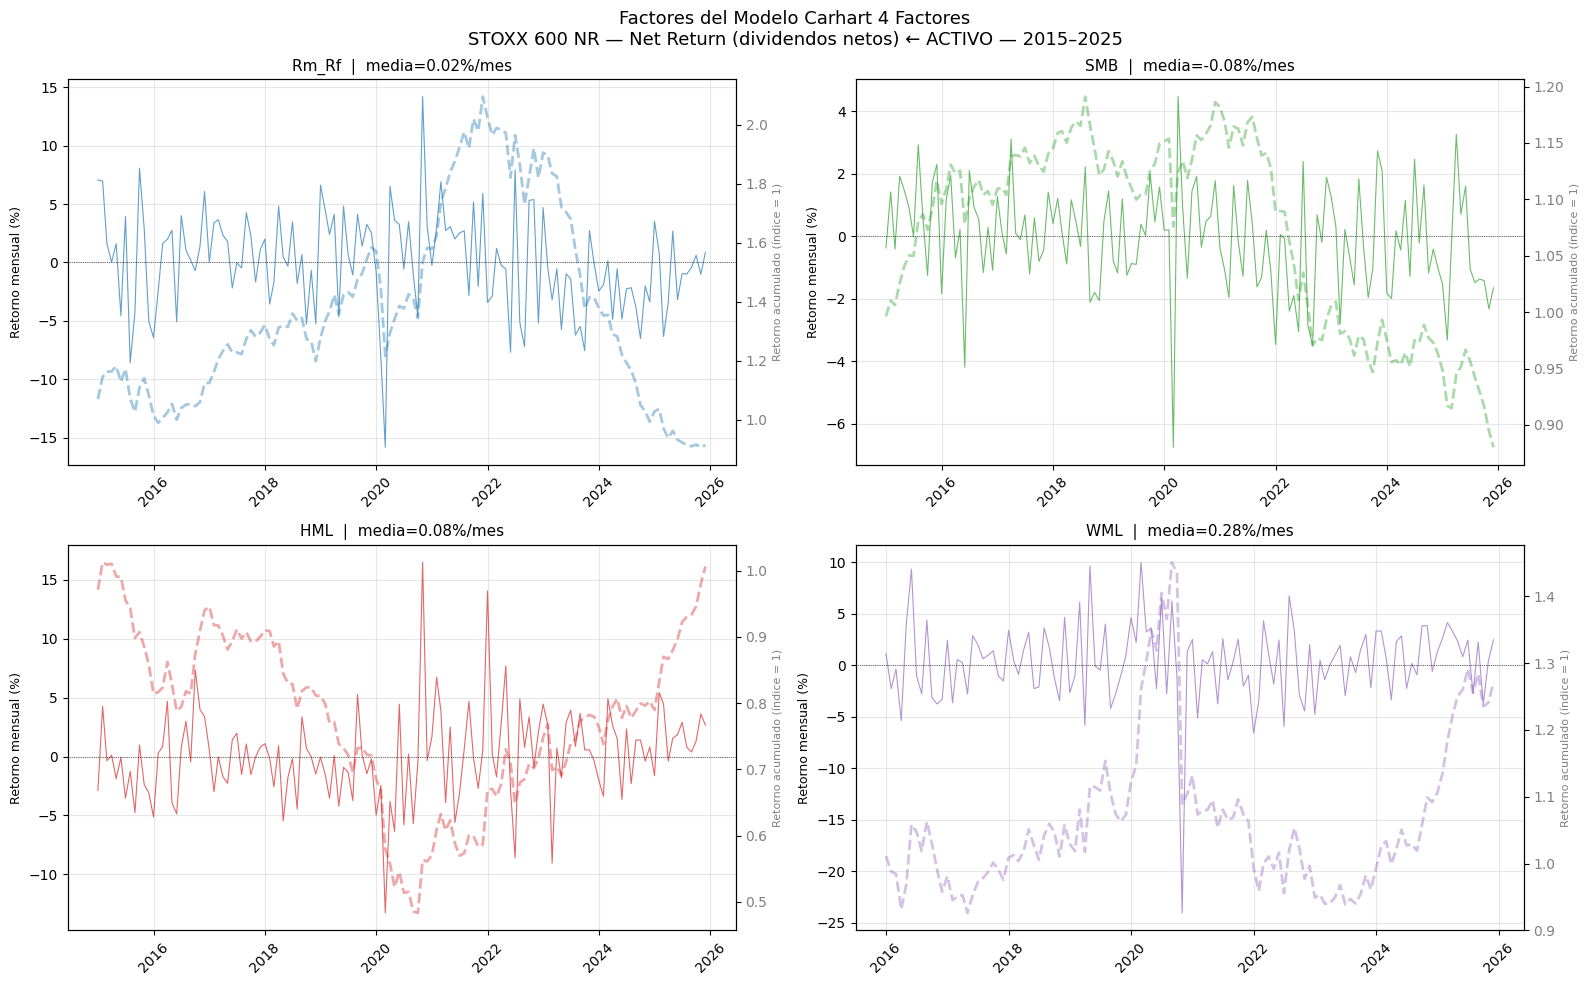

   Gráfico guardado en: /content/drive/MyDrive/TFM_STOXX600/HITO4/factores_carhart_4f.png


In [20]:
 # ==============================================================================
 # SECCIÓN 7: VISUALIZACIÓN DE LOS 4 FACTORES
 # ==============================================================================

 print("\n" + "─" * 80)
 print("SECCIÓN 7: Visualización de los 4 factores")
 print("─" * 80)

 fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 fig.suptitle(f'Factores del Modelo Carhart 4 Factores\nSTOXX 600 {STOXX_VERSION} — 2015–2025', fontsize=13)

 colores = {'Rm_Rf': '#1f77b4', 'SMB': '#2ca02c', 'HML': '#d62728', 'WML': '#9467bd'}

 for ax, col in zip(axes.flatten(), factores):
    s = df_factors[['Date', col]].dropna()

    # Línea del factor
    ax.plot(s['Date'], s[col] * 100, color=colores[col], linewidth=0.8, alpha=0.7)

    # Retorno acumulado (eje secundario)
    ax2 = ax.twinx()
    cum_ret = (1 + s[col]).cumprod()
    ax2.plot(s['Date'], cum_ret, color=colores[col], linewidth=2, alpha=0.4, linestyle='--')
    ax2.set_ylabel('Retorno acumulado (índice = 1)', fontsize=8, color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')

    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.set_title(f'{col}  |  media={s[col].mean()*100:.2f}%/mes', fontsize=11)
    ax.set_ylabel('Retorno mensual (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

import os
ruta_grafico = '/content/drive/MyDrive/TFM_STOXX600/HITO4/factores_carhart_4f.png'
os.makedirs(os.path.dirname(ruta_grafico), exist_ok=True)
plt.savefig(ruta_grafico, dpi=150, bbox_inches='tight')
plt.show()
print(f"   Gráfico guardado en: {ruta_grafico}")




## SECCIÓN 8:
*RESUMEN CARHART 4-FACTOR MODEL*

---




In [21]:
# ==============================================================================
# SECCIÓN 8: RESUMEN FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL — FACTORES DISPONIBLES")
print("=" * 80)
print(f"""
─────────────────────────────────────────────────────────────────────
VARIABLES CREADAS EN MEMORIA:
─────────────────────────────────────────────────────────────────────

  df_factors       → {len(df_factors)} meses × {df_factors.shape[1]} columnas
                     Columns: Date, YearMonth, Rm_monthly, Rf_monthly,
                              Rm_Rf, SMB, HML, WML

  df_factors_4f    → {len(df_factors_4f)} meses con los 4 factores completos
                     (para regresiones en Script 3.2)

─────────────────────────────────────────────────────────────────────
RESUMEN DE ESTADÍSTICAS (período completo):
─────────────────────────────────────────────────────────────────────

  Factor    Media/mes    Desv/mes     Sharpe anual
  Rm_Rf     {df_factors['Rm_Rf'].mean()*100:>8.3f}%     {df_factors['Rm_Rf'].std()*100:>7.3f}%      {(df_factors['Rm_Rf'].mean()/df_factors['Rm_Rf'].std())*np.sqrt(12):.3f}
  SMB       {df_factors['SMB'].mean()*100:>8.3f}%     {df_factors['SMB'].std()*100:>7.3f}%      {(df_factors['SMB'].mean()/df_factors['SMB'].std())*np.sqrt(12) if df_factors['SMB'].std()>0 else 0:.3f}
  HML       {df_factors['HML'].mean()*100:>8.3f}%     {df_factors['HML'].std()*100:>7.3f}%      {(df_factors['HML'].mean()/df_factors['HML'].std())*np.sqrt(12) if df_factors['HML'].std()>0 else 0:.3f}
  WML       {df_factors['WML'].mean()*100:>8.3f}%     {df_factors['WML'].std()*100:>7.3f}%      {(df_factors['WML'].mean()/df_factors['WML'].std())*np.sqrt(12) if df_factors['WML'].std()>0 else 0:.3f}

─────────────────────────────────────────────────────────────────────
PRÓXIMO PASO:
─────────────────────────────────────────────────────────────────────
  Script 3.2: Construir portafolios ESG (Q1-Q5) y regresiones H1
              → Regresión:  R_pt − R_ft = α_p + β_p·(Rm_Rf) + s_p·SMB + h_p·HML + w_p·WML
              → Alpha de Jensen por quintil y por score (ESG, E, S, G)
              → Test GRS para nulidad conjunta de alphas
""")

print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


RESUMEN FINAL — FACTORES DISPONIBLES

─────────────────────────────────────────────────────────────────────
VARIABLES CREADAS EN MEMORIA:
─────────────────────────────────────────────────────────────────────

  df_factors       → 132 meses × 8 columnas
                     Columns: Date, YearMonth, Rm_monthly, Rf_monthly,
                              Rm_Rf, SMB, HML, WML

  df_factors_4f    → 120 meses con los 4 factores completos
                     (para regresiones en Script 3.2)

─────────────────────────────────────────────────────────────────────
RESUMEN DE ESTADÍSTICAS (período completo):
─────────────────────────────────────────────────────────────────────

  Factor    Media/mes    Desv/mes     Sharpe anual
  Rm_Rf        0.022%       4.234%      0.018
  SMB         -0.083%       1.678%      -0.171
  HML          0.077%       3.842%      0.070
  WML          0.282%       3.955%      0.247

─────────────────────────────────────────────────────────────────────
PRÓXIMO PASO:
──

---
# **PRUEBAS DE HIPOTESIS**

---



## TITULO2

```
# Tiene formato de código
```

1.   Elemento de lista
2.   Elemento de lista





### *HIPOTESIS 1*

SCRIPT 3.2 (v2): HIPÓTESIS 1 — ALPHA DE JENSEN (CARHART 4 FACTORES)

Inicio: 2026-06-11 20:55:21

Índice de mercado: STOXX 600 [NR — Net Return (dividendos netos) ← ACTIVO]

────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: Portafolios Q1–Q5 (equal-weighted, estrategia 1/N)
────────────────────────────────────────────────────────────────────────────────

Metodología (protocolo HITO 3):
  1. Cada mes t: usar ESG_Score_lag1 (score del mes t-1 → anti look-ahead bias)
  2. Calcular quintiles entre todas las empresas con score disponible ese mes
     Q1 = top 20% (mejor ESG)  → cartera LONG
     Q5 = bottom 20% (peor ESG) → cartera SHORT
  3. Return del portafolio: equal-weighted (1/N equiproporcional)
     Razón: elimina sesgo por capitalización; las large-cap no dominan el alpha
  4. Repetir para: ESG_Score, E_Score, S_Score, G_Score → 4 × 5 = 20 portafolios

  ESG Compuesto         131 meses  |  107 empresas/quintil (media)
  Pilar E             

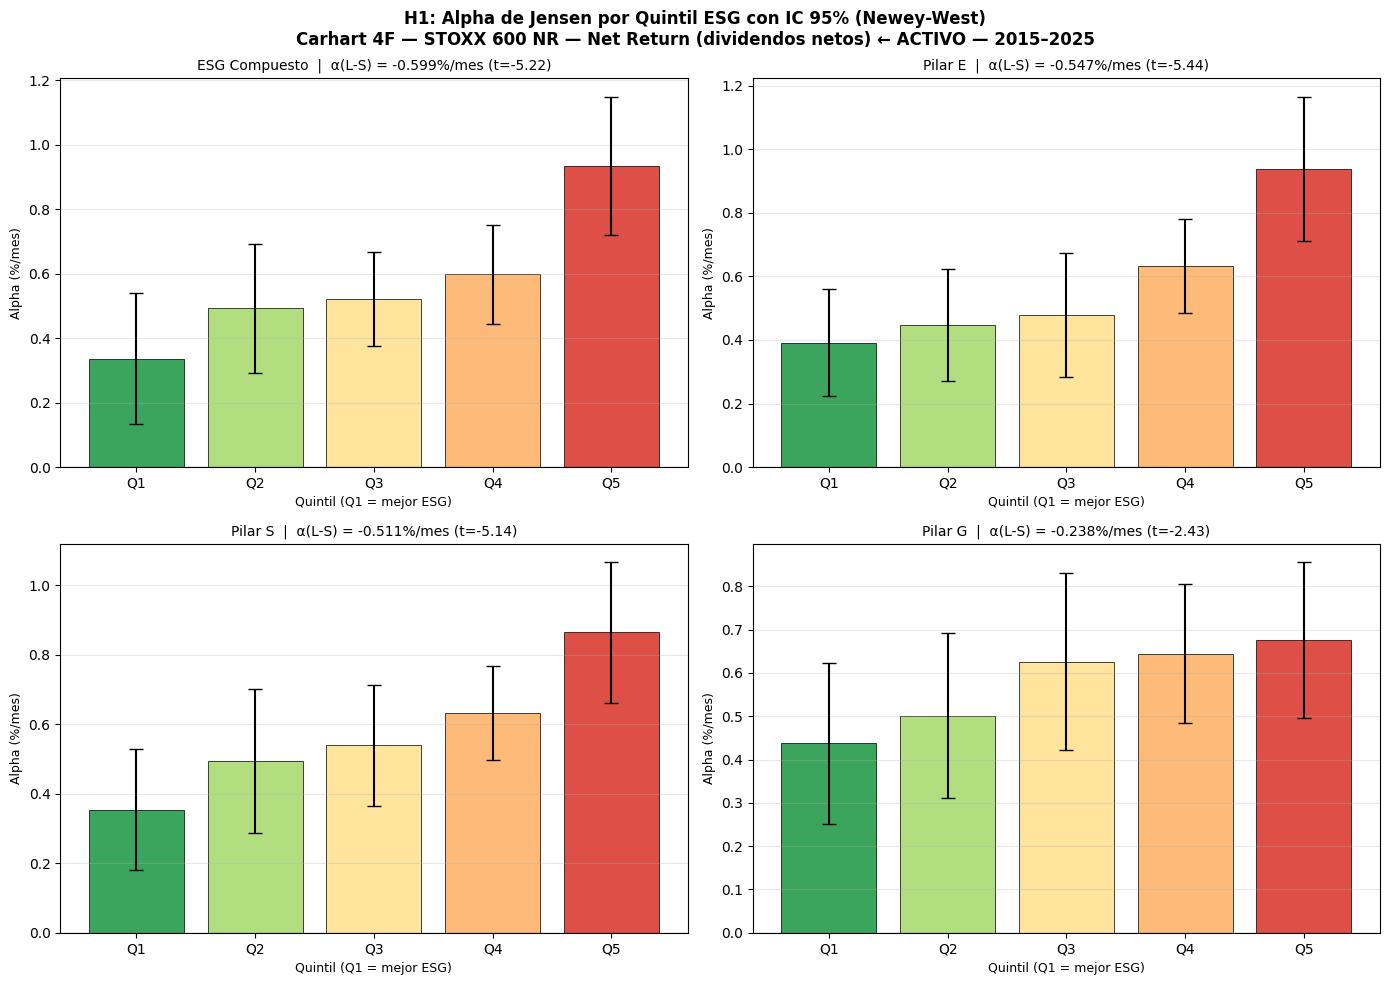

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_alpha_quintiles_ic.png

  Gráfico 2: Retorno acumulado de la estrategia L-S...


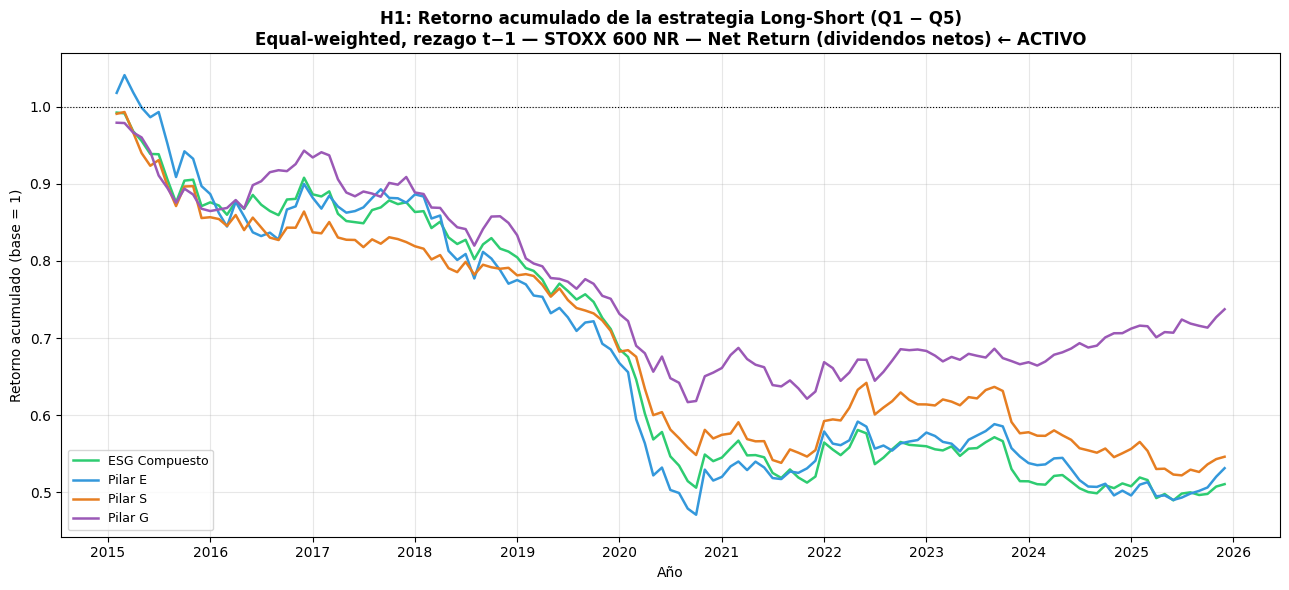

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_ls_acumulado.png

  Gráfico 3: Heatmap de loadings de factores por quintil...


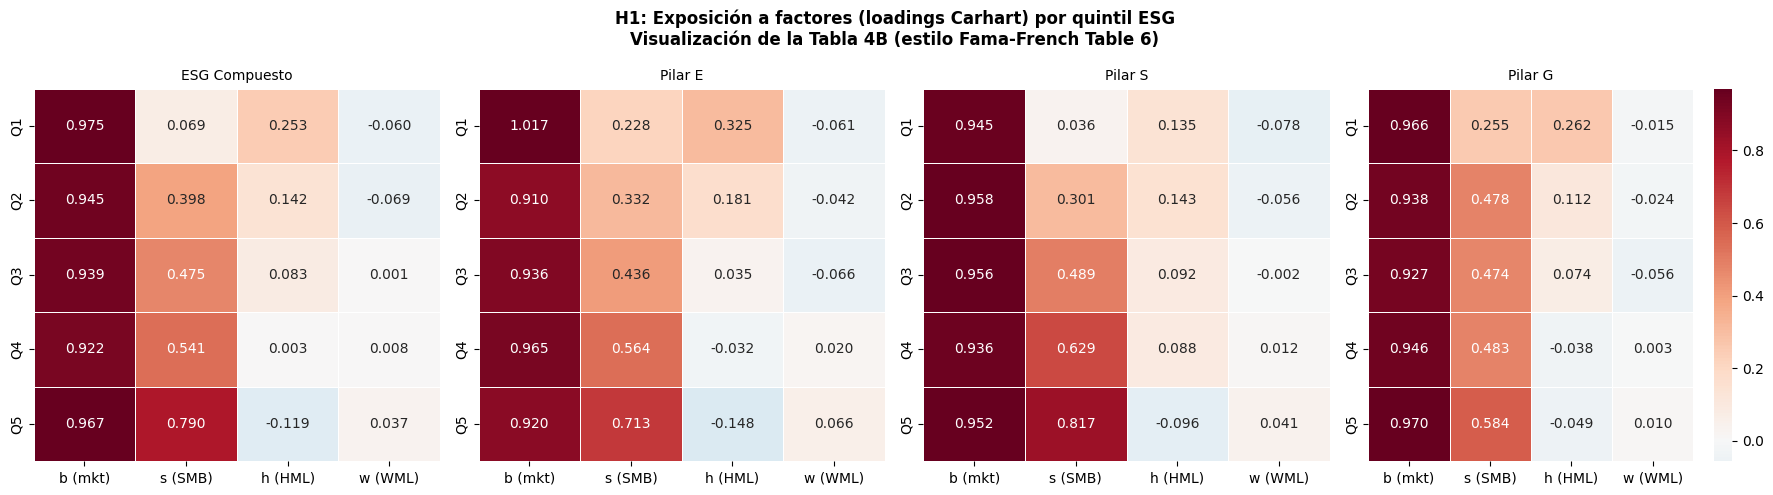

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_heatmap_loadings.png

  Gráfico 4: R² CAPM vs Carhart 4F (ESG compuesto)...


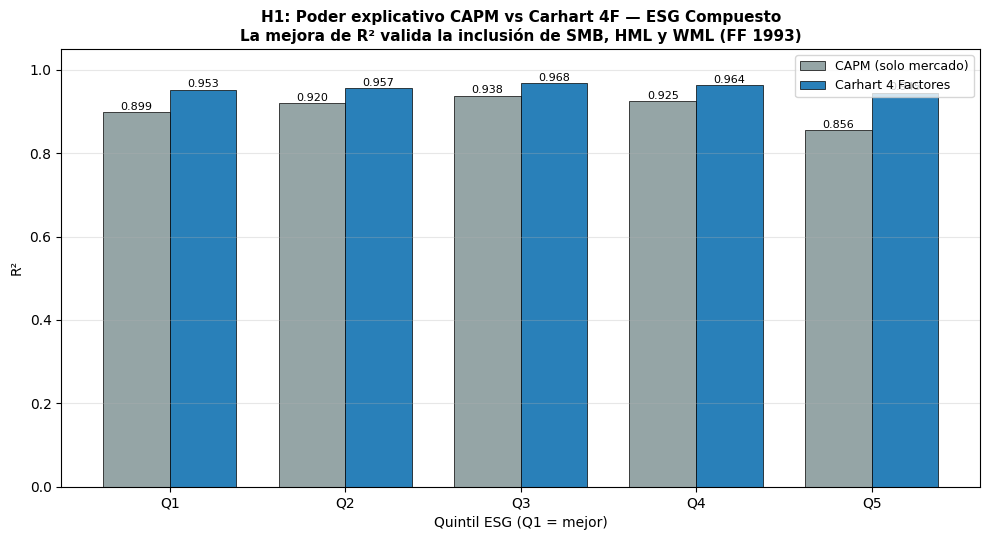

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_r2_capm_vs_carhart.png

  Gráfico 5: Retorno acumulado Q1 vs Q5 vs mercado...


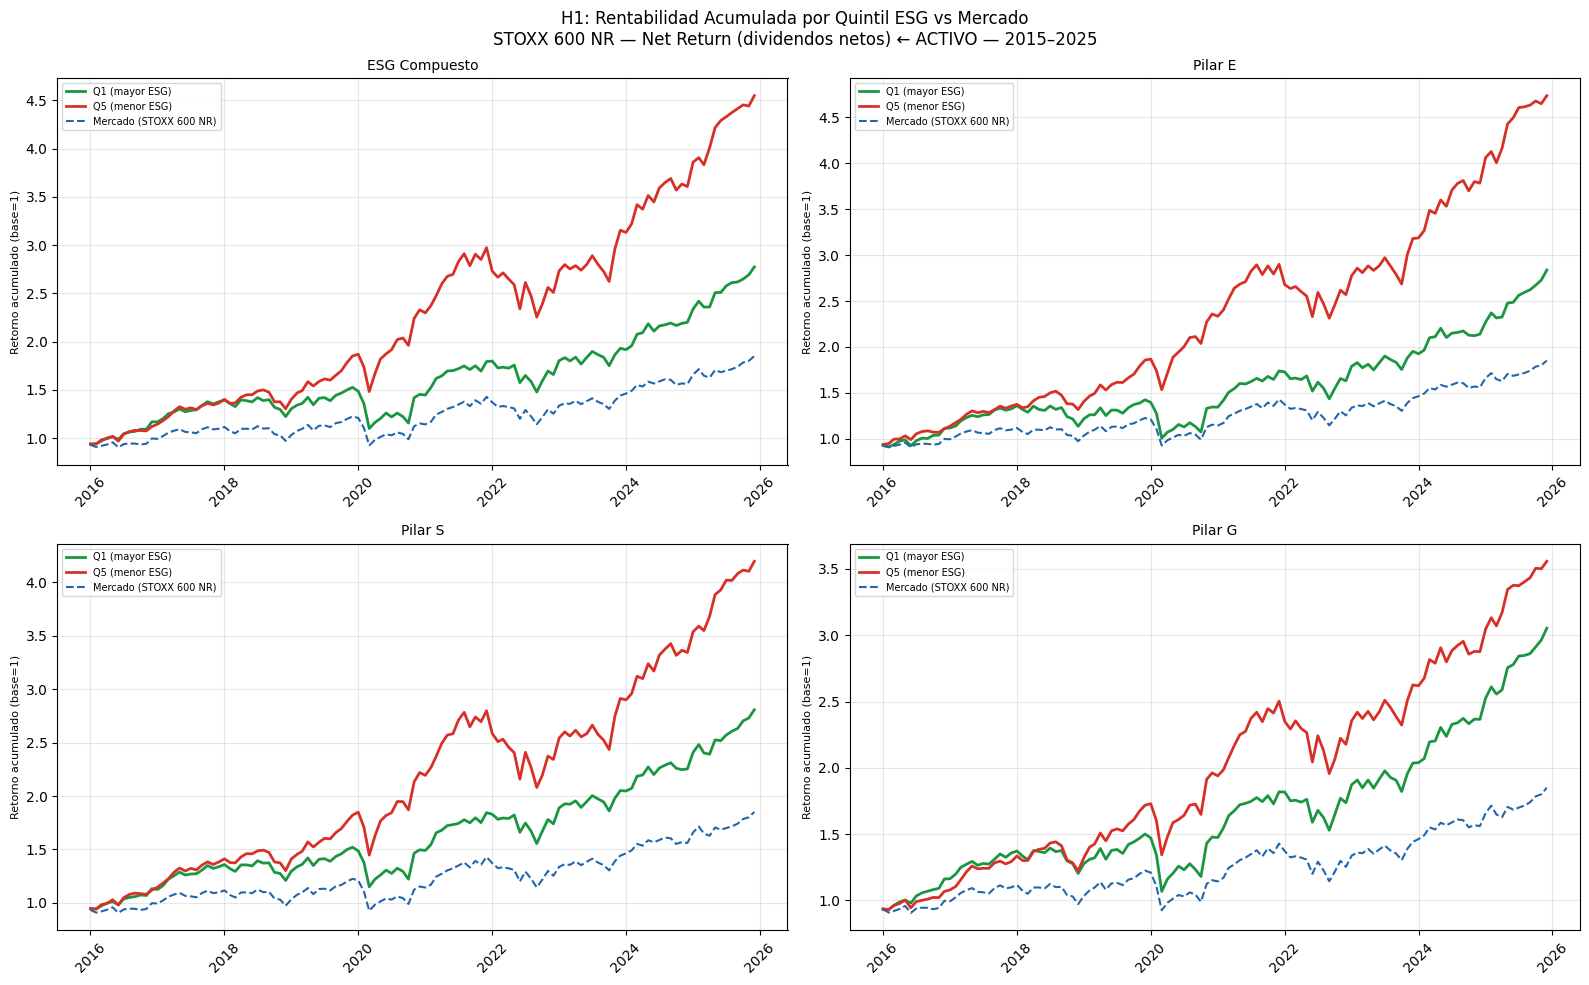

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_alpha_quintiles.png

  Gráfico 6 (anexo): Rolling alpha 36 meses del L-S (ESG compuesto)...


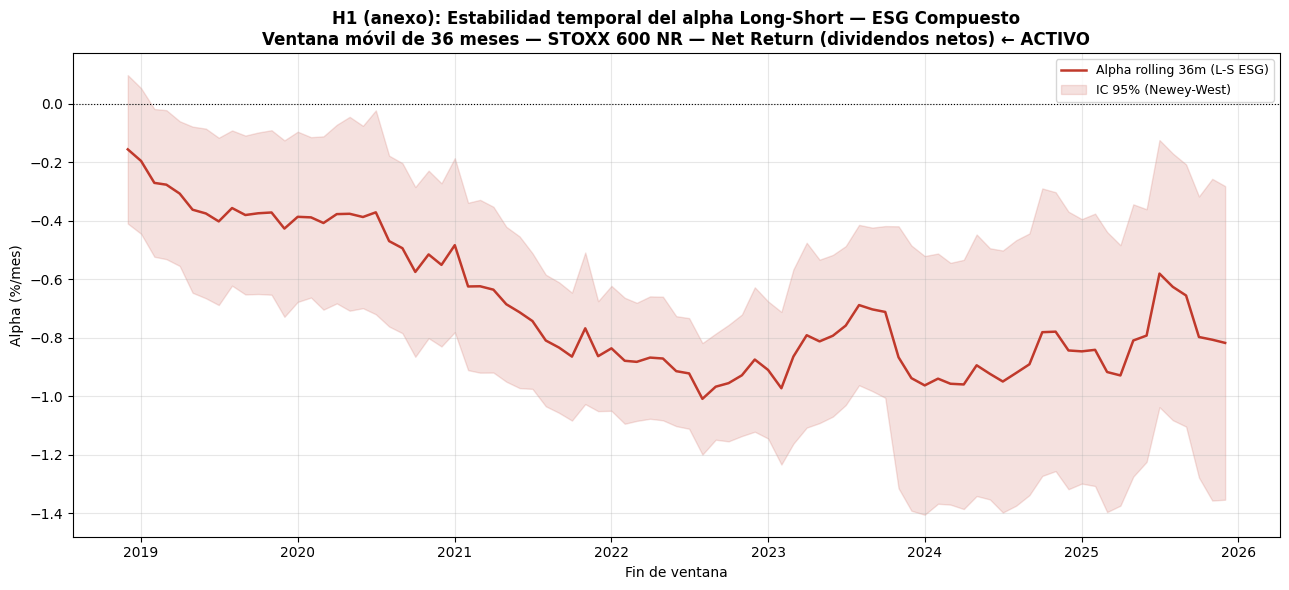

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_rolling_alpha_ls.png

  Gráfico 7 (anexo): QQ-plots de residuos (Q1, Q5, L-S del ESG)...


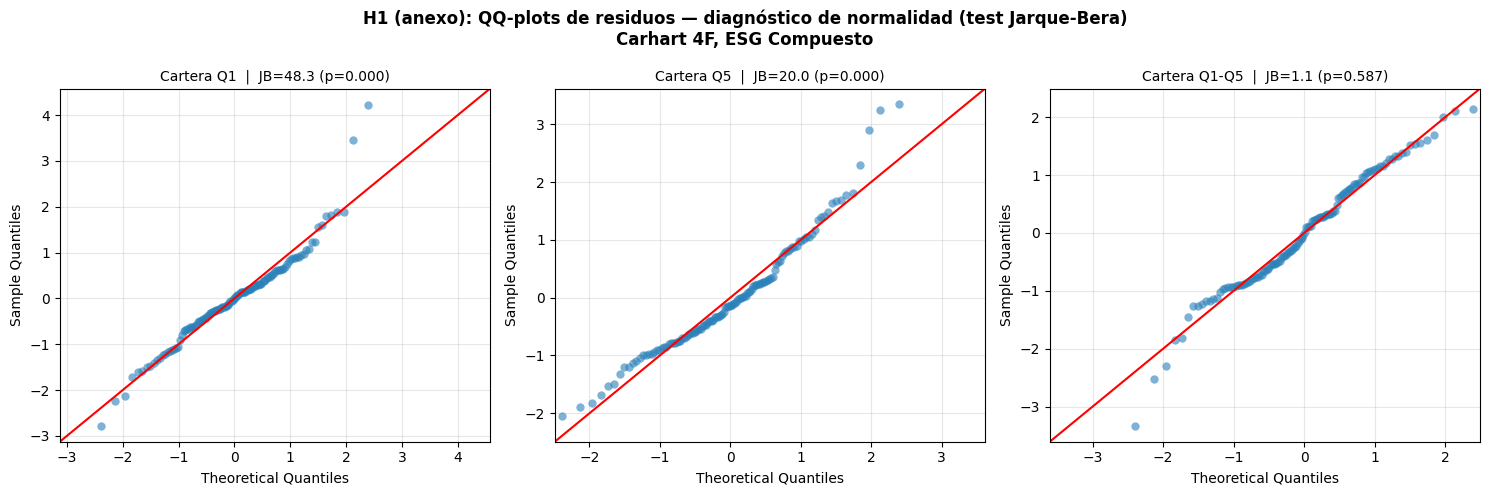

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h1_qqplot_residuos.png

RESUMEN EJECUTIVO — HIPÓTESIS 1

  Alphas Long-Short por Score (modelo principal RAW, Newey-West):
  Score                  α(%/mes)   α(%/año)     t-NW   Sig
  ──────────────────────────────────────────────────────────
  ESG Compuesto           -0.5988     -6.954   -5.218   ***
  Pilar E                 -0.5467     -6.367   -5.442   ***
  Pilar S                 -0.5106     -5.958   -5.144   ***
  Pilar G                 -0.2382     -2.821   -2.426    **

  Interpretación para el TFM:
  ❌ RECHAZAR H1 (con alpha NEGATIVO significativo):
     Alpha L-S = -0.5988%/mes (-6.95% anual)
     t-NW = -5.218, p = 0.0000
     Las empresas de PEOR ESG generan MAYOR rentabilidad anormal.
     Coherente con: Green Premium (Pástor et al. 2021) y
     riesgo brown no capturado (Bolton & Kacperczyk 2021).

  Lectura tipo Taller de regresión (quintiles ESG compuesto):
    Q1: β=0.975 → DEFENSIVA (β<1) | R²=0.953 → el merca

In [22]:
# ==============================================================================
# SCRIPT 3.2 (v2): HIPÓTESIS 1 — ALPHA DE JENSEN (MODELO CARHART 4 FACTORES)
# ==============================================================================
#
# PREGUNTA: ¿El mercado europeo premia el desempeño ESG con una rentabilidad
# anormal positiva, superando la rentabilidad ajustada por riesgo?
#
# MODELO:
#   R_pt − R_ft = α_p + β_p(Rm_Rf) + s_p·SMB + h_p·HML + w_p·WML + ε_pt
#
#   donde:
#     p = portafolio (Q1=top 20% ESG ... Q5=bottom 20% ESG)
#     R_pt = retorno mensual equal-weighted del quintil p
#     α_p  = alpha de Jensen ← lo que queremos medir
#
# ESTRATEGIA LONG-SHORT (best-in-class):
#   Q1 (Long) − Q5 (Short) → si α_LS > 0: ESG genera alpha positivo
#
# DECISIÓN:
#   Aceptar H1: α_LS significativo (t > 1.96, p < 0.05)
#   Rechazar H1: α_LS no significativo
#
# NOVEDADES v2 (alineación con material de clase):
#   · Tabla estilo Fama-French (1993, Table 6): todos los coeficientes con t-stats
#   · Diagnósticos de regresión: Durbin-Watson, Jarque-Bera, F-global (Taller regresión)
#   · Comparación CAPM vs Carhart 4F: ΔR² y GRS de ambos modelos (diapositiva 20)
#   · Anexo: summaries completos de statsmodels (formato visto en clase)
#   · Gráficos: alpha con IC 95%, L-S acumulado, heatmap loadings, R² comparado
#   · Índice de mercado: STOXX 600 Net Return (ver Anexo A1) vía STOXX_VERSION
#
# REQUIERE: df_monthly_raw, df_monthly_w (Script 2.3) + df_factors_4f (Script 3.1)
#           + STOXX_VERSION (Script 2 principal, Sección 5)
# ==============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SCRIPT 3.2 (v2): HIPÓTESIS 1 — ALPHA DE JENSEN (CARHART 4 FACTORES)")
print("=" * 80)
print(f"\nInicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

for var, nombre in [('df_monthly_raw', 'Script 2.3'),
                    ('df_monthly_w',   'Script 2.3'),
                    ('df_factors_4f',  'Script 3.1')]:
    if var not in dir():
        print(f"❌ '{var}' no está en memoria. Ejecuta {nombre} primero.")
        raise SystemExit

if 'STOXX_VERSION' not in dir():
    STOXX_VERSION = 'versión no identificada'
    print("⚠️  STOXX_VERSION no está en memoria (Script 2 Sección 5) — usando etiqueta genérica")

print(f"Índice de mercado: STOXX 600 [{STOXX_VERSION}]")

# ==============================================================================
# SECCIÓN 1: CONSTRUCCIÓN DE PORTAFOLIOS Q1–Q5 POR QUINTIL ESG
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 1: Portafolios Q1–Q5 (equal-weighted, estrategia 1/N)")
print("─" * 80)

print("""
Metodología (protocolo HITO 3):
  1. Cada mes t: usar ESG_Score_lag1 (score del mes t-1 → anti look-ahead bias)
  2. Calcular quintiles entre todas las empresas con score disponible ese mes
     Q1 = top 20% (mejor ESG)  → cartera LONG
     Q5 = bottom 20% (peor ESG) → cartera SHORT
  3. Return del portafolio: equal-weighted (1/N equiproporcional)
     Razón: elimina sesgo por capitalización; las large-cap no dominan el alpha
  4. Repetir para: ESG_Score, E_Score, S_Score, G_Score → 4 × 5 = 20 portafolios
""")

SCORES = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']
SCORE_LABELS = {'ESG_Score': 'ESG Compuesto', 'E_Score': 'Pilar E',
                'S_Score': 'Pilar S', 'G_Score': 'Pilar G'}
N_QUINTILES = 5
MIN_EMPRESAS_QUINTIL = 10  # mínimo para que el portafolio sea estadísticamente válido


def construir_portafolios(df_mensual, scores=SCORES):
    """
    Construye los retornos mensuales de los 5 quintiles ESG
    para cada score dado. Devuelve dict: {score: DataFrame con columnas Q1..Q5}
    """
    portafolios = {}

    for score in scores:
        col_lag = f'{score}_lag1'
        if col_lag not in df_mensual.columns:
            print(f"  ⚠️  {col_lag} no encontrado — omitiendo {score}")
            continue

        resultados = []
        for ym, grupo in df_mensual.groupby('YearMonth'):
            # Solo empresas con score y retorno disponibles este mes
            subdf = grupo[['RIC', 'Return_monthly', col_lag]].dropna()

            if len(subdf) < N_QUINTILES * MIN_EMPRESAS_QUINTIL:
                continue

            # Asignar quintil: rank(ascending=False) → rank 1 = mayor score = Q1
            subdf = subdf.copy()
            subdf['rank'] = subdf[col_lag].rank(ascending=False, method='first')
            n = len(subdf)
            subdf['quintil'] = pd.cut(
                subdf['rank'],
                bins=[0, n*0.2, n*0.4, n*0.6, n*0.8, n],
                labels=[1, 2, 3, 4, 5]
            ).astype(int)

            fila = {'YearMonth': ym}
            for q in range(1, N_QUINTILES + 1):
                empresas_q = subdf[subdf['quintil'] == q]
                if len(empresas_q) >= 3:
                    fila[f'Q{q}'] = empresas_q['Return_monthly'].mean()   # igual ponderado 1/N
                    fila[f'N_Q{q}'] = len(empresas_q)
                else:
                    fila[f'Q{q}'] = np.nan
                    fila[f'N_Q{q}'] = 0

            resultados.append(fila)

        df_port = pd.DataFrame(resultados)
        df_port['Date'] = df_port['YearMonth'].dt.to_timestamp()
        portafolios[score] = df_port

    return portafolios


ports_raw  = construir_portafolios(df_monthly_raw)
ports_w    = construir_portafolios(df_monthly_w)

# Reporte de cobertura
for score, df_p in ports_raw.items():
    meses = len(df_p)
    n_med = df_p[[f'N_Q{q}' for q in range(1,6)]].mean().mean()
    print(f"  {SCORE_LABELS[score]:<20}  {meses} meses  |  {n_med:.0f} empresas/quintil (media)")

# ==============================================================================
# SECCIÓN 2: ESTRATEGIA LONG-SHORT Y EXCESO DE RETORNO
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 2: Estrategia Long-Short (Q1 − Q5) y exceso de retorno")
print("─" * 80)

# Añadir Rf mensual y crear exceso de retorno para regresión
rf_table = df_monthly_raw[['YearMonth', 'Rf_monthly']].drop_duplicates('YearMonth')

for ports_dict in [ports_raw, ports_w]:
    for score in list(ports_dict.keys()):
        df_p = ports_dict[score].merge(rf_table, on='YearMonth', how='left')
        df_p['LS'] = df_p['Q1'] - df_p['Q5']  # Long-Short
        for q in range(1, N_QUINTILES + 1):
            df_p[f'EX_Q{q}'] = df_p[f'Q{q}'] - df_p['Rf_monthly']
        df_p['EX_LS'] = df_p['LS']  # Long-Short ya es exceso vs Rf indirecto
        ports_dict[score] = df_p

print("  ✅ Excesos de retorno y cartera L-S construidos para RAW y WINS")

# ==============================================================================
# SECCIÓN 3: REGRESIONES — CAPM Y CARHART 4 FACTORES
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 3: Regresiones CAPM y Carhart 4 factores")
print("─" * 80)

FACTORES_CARHART = ['Rm_Rf', 'SMB', 'HML', 'WML']
FACTORES_CAPM    = ['Rm_Rf']
factors_cols     = FACTORES_CARHART  # compatibilidad con secciones siguientes

NOMBRES_FACTOR = {'Rm_Rf': 'mkt', 'SMB': 'smb', 'HML': 'hml', 'WML': 'wml'}


def regresion_factores(ret_series, df_factors_in, factores_x=FACTORES_CARHART):
    """
    Regresión OLS: R_p - R_f = α + Σ β_k·F_k + ε
    Estima OLS estándar y Newey-West (HAC, 3 lags).
    Devuelve dict con coeficientes, t-stats NW de TODOS los factores,
    R², R²-adj, F-global, Durbin-Watson, Jarque-Bera y s(e).
    """
    df_reg = pd.DataFrame({'y': ret_series}).join(
        df_factors_in[['YearMonth'] + factores_x].set_index('YearMonth')
    ).dropna()

    if len(df_reg) < 24:
        return None

    Y = df_reg['y'].values
    X = sm.add_constant(df_reg[factores_x].values)

    modelo    = sm.OLS(Y, X).fit()
    modelo_nw = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    jb_stat, jb_p, _, _ = jarque_bera(modelo.resid)

    resultado = {
        'n':           len(df_reg),
        'alpha':       modelo.params[0],
        't_alpha':     modelo.tvalues[0],
        't_alpha_nw':  modelo_nw.tvalues[0],
        'p_alpha':     modelo.pvalues[0],
        'p_alpha_nw':  modelo_nw.pvalues[0],
        'se_alpha_nw': modelo_nw.bse[0],
        'R2':          modelo.rsquared,
        'R2_adj':      modelo.rsquared_adj,
        'F_stat':      modelo.fvalue,
        'p_F':         modelo.f_pvalue,
        'DW':          durbin_watson(modelo.resid),
        'JB':          jb_stat,
        'p_JB':        jb_p,
        's_e':         modelo.resid.std(ddof=1),
    }

    # Coeficientes y t-stats NW de cada factor incluido
    for i, f in enumerate(factores_x, start=1):
        clave = NOMBRES_FACTOR[f]
        resultado[f'beta_{clave}'] = modelo.params[i]
        resultado[f't_{clave}_nw'] = modelo_nw.tvalues[i]
        resultado[f'p_{clave}_nw'] = modelo_nw.pvalues[i]

    return resultado


# Alias para compatibilidad con código previo
carhart_regression = regresion_factores


def correr_todas_regresiones(ports_dict, df_fct, etiqueta='RAW',
                             factores_x=FACTORES_CARHART, modelo_nombre='Carhart'):
    """Corre las regresiones para todos los scores y quintiles + L-S."""
    tabla = []

    for score in SCORES:
        if score not in ports_dict:
            continue
        df_p = ports_dict[score].merge(
            df_fct[['YearMonth'] + factores_x],
            on='YearMonth', how='inner'
        )

        for q in range(1, N_QUINTILES + 1):
            ret_col = f'EX_Q{q}'
            res = regresion_factores(df_p.set_index('YearMonth')[ret_col], df_fct, factores_x)
            if res:
                res.update({'score': score, 'cartera': f'Q{q}',
                            'version': etiqueta, 'modelo': modelo_nombre})
                tabla.append(res)

        res_ls = regresion_factores(df_p.set_index('YearMonth')['EX_LS'], df_fct, factores_x)
        if res_ls:
            res_ls.update({'score': score, 'cartera': 'Q1-Q5',
                           'version': etiqueta, 'modelo': modelo_nombre})
            tabla.append(res_ls)

    return pd.DataFrame(tabla)


# ── Carhart 4F: modelo principal (RAW) y sensibilidad (WINS) ──────────────────
print("  Corriendo regresiones Carhart RAW (modelo principal)...")
df_reg_raw = correr_todas_regresiones(ports_raw, df_factors_4f, etiqueta='RAW')

print("  Corriendo regresiones Carhart WINSORIZADO (sensibilidad)...")
df_reg_w = correr_todas_regresiones(ports_w, df_factors_4f, etiqueta='WINS')

# ── CAPM simple: para comparación de modelos (diapositiva 20 / FF 1993) ───────
print("  Corriendo regresiones CAPM simple (comparación de modelos)...")
df_reg_capm = correr_todas_regresiones(ports_raw, df_factors_4f, etiqueta='RAW',
                                       factores_x=FACTORES_CAPM, modelo_nombre='CAPM')

df_reg_all = pd.concat([df_reg_raw, df_reg_w], ignore_index=True)
print(f"\n  ✅ Regresiones Carhart: {len(df_reg_all)} ({len(df_reg_raw)} RAW + {len(df_reg_w)} WINS)")
print(f"  ✅ Regresiones CAPM:    {len(df_reg_capm)} (para tabla comparativa)")

# ==============================================================================
# SECCIÓN 4: TABLAS DE RESULTADOS
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 4: Tablas de resultados")
print("─" * 80)

def sig_stars(p):
    if   p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else:          return ''


# ── 4A: Tabla resumida — Alpha de Jensen por cartera ──────────────────────────
print("\n" + "═" * 80)
print("TABLA 4A — ALPHAS DE JENSEN (resumen por cartera, Newey-West)")
print("═" * 80)

for score in SCORES:
    print(f"\n  {'─'*60}")
    print(f"  {SCORE_LABELS[score]} — Alphas de Jensen (% mensual, Newey-West t-stat)")
    print(f"  {'─'*60}")
    print(f"  {'Cartera':<10} {'α(%/mes)':>10} {'t-NW':>8} {'Sig':>5} {'β_mkt':>8} {'R²':>7}")
    print(f"  {'─'*60}")

    subset = df_reg_raw[(df_reg_raw['score'] == score)].copy()
    for _, row in subset.iterrows():
        stars = sig_stars(row['p_alpha_nw'])
        print(f"  {row['cartera']:<10} {row['alpha']*100:>10.4f} {row['t_alpha_nw']:>8.3f} {stars:>5} {row['beta_mkt']:>8.4f} {row['R2']:>7.3f}")

# ── 4B: Tabla estilo Fama-French (1993, Table 6) — coeficientes completos ─────
print("\n" + "═" * 80)
print("TABLA 4B — COEFICIENTES COMPLETOS ESTILO FAMA-FRENCH (Table 6)")
print("═" * 80)
print("""
Para cada cartera: coeficiente y t-stat (Newey-West) de los 4 factores.
Permite analizar la exposición de cada quintil ESG a tamaño (s), valor (h)
y momentum (w), además del mercado (b). s(e) = desviación estándar residual.
""")

for score in SCORES:
    print(f"\n  {SCORE_LABELS[score]}")
    print(f"  {'─'*108}")
    print(f"  {'Cartera':<8} {'α%':>8} {'t(α)':>7} {'b':>7} {'t(b)':>7} {'s':>7} {'t(s)':>7} "
          f"{'h':>7} {'t(h)':>7} {'w':>7} {'t(w)':>7} {'R²aj':>6} {'s(e)%':>7}")
    print(f"  {'─'*108}")

    subset = df_reg_raw[df_reg_raw['score'] == score]
    for _, r in subset.iterrows():
        print(f"  {r['cartera']:<8} {r['alpha']*100:>8.4f} {r['t_alpha_nw']:>7.2f} "
              f"{r['beta_mkt']:>7.3f} {r['t_mkt_nw']:>7.2f} "
              f"{r['beta_smb']:>7.3f} {r['t_smb_nw']:>7.2f} "
              f"{r['beta_hml']:>7.3f} {r['t_hml_nw']:>7.2f} "
              f"{r['beta_wml']:>7.3f} {r['t_wml_nw']:>7.2f} "
              f"{r['R2_adj']:>6.3f} {r['s_e']*100:>7.3f}")

print("""
  Lectura (igual que FF 1993):
  · b cercano a 1 y t(b) alto → exposición de mercado completa
  · s > 0 → el quintil se comporta como small-cap; s < 0 → como large-cap
  · h > 0 → inclinación value; h < 0 → inclinación growth
  · w > 0 → exposición positiva a momentum
""")

# ── 4C: Diagnósticos de regresión (Taller de regresión) ───────────────────────
print("\n" + "═" * 80)
print("TABLA 4C — DIAGNÓSTICOS DE REGRESIÓN (modelo principal RAW)")
print("═" * 80)
print("""
Estadísticos del summary de statsmodels vistos en el Taller de regresión:
· Durbin-Watson ≈ 2 → sin autocorrelación de residuos (justifica/valida Newey-West)
· Jarque-Bera: H0 = residuos normales (p < 0.05 → no normales, usar t robustos)
· F-global: H0 = todos los coeficientes nulos (p < 0.05 → el modelo es significativo)
""")

for score in SCORES:
    print(f"\n  {SCORE_LABELS[score]}")
    print(f"  {'Cartera':<8} {'DW':>6} {'JB':>9} {'p(JB)':>8} {'F-stat':>9} {'p(F)':>9} {'n':>5}")
    print(f"  {'─'*60}")
    subset = df_reg_raw[df_reg_raw['score'] == score]
    for _, r in subset.iterrows():
        print(f"  {r['cartera']:<8} {r['DW']:>6.3f} {r['JB']:>9.2f} {r['p_JB']:>8.4f} "
              f"{r['F_stat']:>9.2f} {r['p_F']:>9.2e} {r['n']:>5}")

# ==============================================================================
# SECCIÓN 5: TEST GRS — NULIDAD CONJUNTA DE LOS ALPHAS
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 5: Test GRS — ¿Son nulos los alphas conjuntamente?")
print("─" * 80)

print("""
Test GRS (Gibbons, Ross y Shanken, 1989):
  H0: α_Q1 = α_Q2 = α_Q3 = α_Q4 = α_Q5 = 0 (ningún quintil tiene alpha)
  Si p < 0.05: al menos un quintil tiene alpha significativo → el ESG
               aporta información adicional a los factores de mercado

Estadístico F ~ F(N, T-N-K) donde N=5 quintiles, T=meses, K=nº factores
""")


def test_grs(ports_dict, df_fct, score, version='RAW', factores_x=FACTORES_CARHART):
    """
    Implementación del test GRS para N portafolios y K factores.
    Referencia: Gibbons, Ross & Shanken (1989), Econometrica.
    """
    df_p = ports_dict[score].merge(
        df_fct[['YearMonth'] + factores_x],
        on='YearMonth', how='inner'
    ).dropna(subset=[f'EX_Q{q}' for q in range(1, 6)] + factores_x)

    T = len(df_p)
    N = N_QUINTILES
    K = len(factores_x)

    if T < N + K + 10:
        return None

    Y = df_p[[f'EX_Q{q}' for q in range(1, N+1)]].values  # T × N
    X = sm.add_constant(df_p[factores_x].values)            # T × (K+1)

    # Estimar alphas y residuos para cada portafolio
    alphas  = np.zeros(N)
    resid   = np.zeros((T, N))
    for i in range(N):
        m = sm.OLS(Y[:, i], X).fit()
        alphas[i]   = m.params[0]
        resid[:, i] = m.resid

    # Matriz de covarianzas de los residuos
    Sigma = (resid.T @ resid) / T

    # Factor de corrección (primas medias de los factores)
    mu_f = df_p[factores_x].mean().values
    Omega = df_p[factores_x].cov().values
    if K == 1:
        kappa2 = float(mu_f[0]**2 / Omega[0, 0])
    else:
        kappa2 = mu_f @ np.linalg.inv(Omega) @ mu_f

    # Estadístico GRS
    Sigma_inv = np.linalg.inv(Sigma)
    grs_num   = (T - N - K) / N
    grs_denom = (1 + kappa2)
    grs_stat  = grs_num / grs_denom * (alphas @ Sigma_inv @ alphas)

    from scipy import stats
    p_val = 1 - stats.f.cdf(grs_stat, N, T - N - K)

    return {
        'score':    score,
        'version':  version,
        'T':        T,
        'N':        N,
        'K':        K,
        'GRS_F':    grs_stat,
        'p_value':  p_val,
        'alphas':   alphas.tolist(),
        'kappa2':   kappa2
    }


grs_resultados = []
for score in SCORES:
    for ports_dict, etq in [(ports_raw, 'RAW'), (ports_w, 'WINS')]:
        if score in ports_dict:
            res = test_grs(ports_dict, df_factors_4f, score, etq)
            if res:
                grs_resultados.append(res)

print(f"  {'Score':<15} {'Ver':>5} {'T':>5} {'GRS_F':>9} {'p-value':>10} {'Decisión'}")
print(f"  {'─'*65}")
for r in grs_resultados:
    dec = "Rechazar H0 (**)" if r['p_value'] < 0.05 else "No rechazar H0"
    print(f"  {SCORE_LABELS[r['score']]:<15} {r['version']:>5} {r['T']:>5} "
          f"{r['GRS_F']:>9.4f} {r['p_value']:>10.4f}   {dec}")

# ==============================================================================
# SECCIÓN 6: COMPARACIÓN DE MODELOS — CAPM vs CARHART 4F
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 6: Comparación de modelos — CAPM vs Carhart 4F")
print("─" * 80)

print("""
Contraste de la teoría de clase (FF 1993, diapositivas 16 y 20):
la inclusión de los factores SMB, HML y WML debería mejorar el R² respecto
al modelo de índice único (CAPM). Se compara también el GRS de cada modelo.
""")

print(f"  {'Score':<15} {'R²med CAPM':>11} {'R²med 4F':>10} {'ΔR²':>7} "
      f"{'GRS CAPM':>10} {'p':>8} {'GRS 4F':>9} {'p':>8}")
print(f"  {'─'*84}")

quintiles_only = [f'Q{q}' for q in range(1, 6)]

for score in SCORES:
    r2_capm = df_reg_capm[(df_reg_capm['score'] == score) &
                          (df_reg_capm['cartera'].isin(quintiles_only))]['R2'].mean()
    r2_4f   = df_reg_raw[(df_reg_raw['score'] == score) &
                         (df_reg_raw['cartera'].isin(quintiles_only))]['R2'].mean()

    grs_capm = test_grs(ports_raw, df_factors_4f, score, 'RAW', FACTORES_CAPM)
    grs_4f   = next((r for r in grs_resultados
                     if r['score'] == score and r['version'] == 'RAW'), None)

    print(f"  {SCORE_LABELS[score]:<15} {r2_capm:>11.4f} {r2_4f:>10.4f} {r2_4f-r2_capm:>7.4f} "
          f"{grs_capm['GRS_F']:>10.3f} {grs_capm['p_value']:>8.4f} "
          f"{grs_4f['GRS_F']:>9.3f} {grs_4f['p_value']:>8.4f}")

print("""
  Interpretación:
  · ΔR² > 0 confirma que SMB, HML y WML añaden poder explicativo sobre el CAPM
    (hipótesis H1 de Fama-French 1993, diapositiva 16 del material de clase)
  · Si el GRS rechaza H0 en ambos modelos: los alphas no se explican ni por el
    mercado solo ni por los 4 factores → el efecto ESG es información adicional
""")

# ==============================================================================
# SECCIÓN 7: ANÁLISIS DE SENSIBILIDAD RAW vs WINSORIZADO
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 7: Sensibilidad — RAW vs Winsorizado (comparación de alphas Q1-Q5)")
print("─" * 80)

print("""
Comparación de alphas de Jensen entre la especificación RAW (modelo principal)
y la especificación winsorizada (sensibilidad). Si el alpha de la cartera L-S
no cambia materialmente, el hallazgo es robusto.
Umbral: variación < 10% → robusto; 10-30% → moderado; > 30% → frágil
""")

print(f"  {'Score':<15} {'Cartera':<10} {'α_RAW%':>9} {'α_WINS%':>9} {'Var%':>8} {'Veredicto'}")
print(f"  {'─'*65}")

for score in SCORES:
    for cartera in ['Q1', 'Q5', 'Q1-Q5']:
        fila_raw  = df_reg_all[(df_reg_all['score']==score) & (df_reg_all['cartera']==cartera) & (df_reg_all['version']=='RAW')]
        fila_wins = df_reg_all[(df_reg_all['score']==score) & (df_reg_all['cartera']==cartera) & (df_reg_all['version']=='WINS')]
        if fila_raw.empty or fila_wins.empty:
            continue
        a_raw  = fila_raw.iloc[0]['alpha']
        a_wins = fila_wins.iloc[0]['alpha']
        if abs(a_raw) < 1e-8:
            var_pct = 999.0
            veredicto = "⚠️  α_raw ≈ 0"
        else:
            var_pct = abs(a_raw - a_wins) / abs(a_raw) * 100
            if var_pct < 10:
                veredicto = "✅ Robusto"
            elif var_pct < 30:
                veredicto = "⚠️  Moderado"
            else:
                veredicto = "🔴 Frágil"
        print(f"  {SCORE_LABELS[score]:<15} {cartera:<10} {a_raw*100:>9.4f} {a_wins*100:>9.4f} {var_pct:>8.1f}   {veredicto}")

# ==============================================================================
# SECCIÓN 8: GRÁFICOS
# ==============================================================================

print("\n" + "─" * 80)
print(f"SECCIÓN 8: Gráficos — H1 [{STOXX_VERSION}]")
print("─" * 80)

import os
RUTA_GRAFICOS = '/content/drive/MyDrive/TFM_STOXX600/HITO4'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

colores_q = {1: '#1a9641', 2: '#a6d96a', 3: '#fee08b', 4: '#fdae61', 5: '#d73027'}
color_mkt = '#2166ac'

# ── Gráfico 1: Alpha por quintil con IC 95% (Newey-West) ──────────────────────
print("\n  Gráfico 1: Alphas por quintil con IC 95%...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('H1: Alpha de Jensen por Quintil ESG con IC 95% (Newey-West)\n'
             f'Carhart 4F — STOXX 600 {STOXX_VERSION} — 2015–2025', fontsize=12, fontweight='bold')

for ax, score in zip(axes.flatten(), SCORES):
    sub = df_reg_raw[(df_reg_raw['score'] == score) &
                     (df_reg_raw['cartera'].isin(quintiles_only))].copy()
    sub['q'] = sub['cartera'].str[1].astype(int)
    sub = sub.sort_values('q')

    alphas_pct = sub['alpha'] * 100
    err95 = 1.96 * sub['se_alpha_nw'] * 100
    colores_barras = [colores_q[q] for q in sub['q']]

    ax.bar(sub['cartera'], alphas_pct, yerr=err95, color=colores_barras,
           edgecolor='black', linewidth=0.6, capsize=5, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)

    # Marcar el alpha L-S como referencia
    ls = df_reg_raw[(df_reg_raw['score'] == score) & (df_reg_raw['cartera'] == 'Q1-Q5')]
    if not ls.empty:
        a_ls = ls.iloc[0]['alpha'] * 100
        t_ls = ls.iloc[0]['t_alpha_nw']
        ax.set_title(f"{SCORE_LABELS[score]}  |  α(L-S) = {a_ls:.3f}%/mes (t={t_ls:.2f})", fontsize=10)
    else:
        ax.set_title(SCORE_LABELS[score], fontsize=10)

    ax.set_ylabel('Alpha (%/mes)', fontsize=9)
    ax.set_xlabel('Quintil (Q1 = mejor ESG)', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_alpha_quintiles_ic.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 2: Retorno acumulado de la estrategia Long-Short ──────────────────
print("\n  Gráfico 2: Retorno acumulado de la estrategia L-S...")

fig, ax = plt.subplots(figsize=(13, 6))
colores_score = {'ESG_Score': '#2ecc71', 'E_Score': '#3498db',
                 'S_Score': '#e67e22', 'G_Score': '#9b59b6'}

for score in SCORES:
    if score not in ports_raw:
        continue
    df_p = ports_raw[score].dropna(subset=['LS']).sort_values('Date')
    cum_ls = (1 + df_p['LS']).cumprod()
    ax.plot(df_p['Date'], cum_ls, color=colores_score[score],
            linewidth=1.8, label=f'{SCORE_LABELS[score]}')

ax.axhline(1, color='black', linewidth=0.8, linestyle=':')
ax.set_title('H1: Retorno acumulado de la estrategia Long-Short (Q1 − Q5)\n'
             f'Equal-weighted, rezago t−1 — STOXX 600 {STOXX_VERSION}', fontsize=12, fontweight='bold')
ax.set_ylabel('Retorno acumulado (base = 1)')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_ls_acumulado.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 3: Heatmap de loadings por quintil (tabla FF visual) ──────────────
print("\n  Gráfico 3: Heatmap de loadings de factores por quintil...")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('H1: Exposición a factores (loadings Carhart) por quintil ESG\n'
             'Visualización de la Tabla 4B (estilo Fama-French Table 6)', fontsize=12, fontweight='bold')

for ax, score in zip(axes, SCORES):
    sub = df_reg_raw[(df_reg_raw['score'] == score) &
                     (df_reg_raw['cartera'].isin(quintiles_only))].copy()
    sub['q'] = sub['cartera'].str[1].astype(int)
    sub = sub.sort_values('q').set_index('cartera')

    matriz = sub[['beta_mkt', 'beta_smb', 'beta_hml', 'beta_wml']]
    matriz.columns = ['b (mkt)', 's (SMB)', 'h (HML)', 'w (WML)']

    sns.heatmap(matriz, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                cbar=(ax == axes[-1]), ax=ax, linewidths=0.5)
    ax.set_title(SCORE_LABELS[score], fontsize=10)
    ax.set_ylabel('')

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_heatmap_loadings.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 4: R² CAPM vs Carhart por quintil ─────────────────────────────────
print("\n  Gráfico 4: R² CAPM vs Carhart 4F (ESG compuesto)...")

fig, ax = plt.subplots(figsize=(10, 5.5))

sub_capm = df_reg_capm[(df_reg_capm['score'] == 'ESG_Score') &
                       (df_reg_capm['cartera'].isin(quintiles_only))].copy()
sub_4f   = df_reg_raw[(df_reg_raw['score'] == 'ESG_Score') &
                      (df_reg_raw['cartera'].isin(quintiles_only))].copy()
sub_capm['q'] = sub_capm['cartera'].str[1].astype(int)
sub_4f['q']   = sub_4f['cartera'].str[1].astype(int)
sub_capm = sub_capm.sort_values('q')
sub_4f   = sub_4f.sort_values('q')

x = np.arange(len(quintiles_only))
ancho = 0.38

ax.bar(x - ancho/2, sub_capm['R2'], ancho, label='CAPM (solo mercado)',
       color='#95a5a6', edgecolor='black', linewidth=0.5)
ax.bar(x + ancho/2, sub_4f['R2'], ancho, label='Carhart 4 Factores',
       color='#2980b9', edgecolor='black', linewidth=0.5)

for i, (r2c, r24) in enumerate(zip(sub_capm['R2'], sub_4f['R2'])):
    ax.text(i - ancho/2, r2c + 0.005, f'{r2c:.3f}', ha='center', fontsize=8)
    ax.text(i + ancho/2, r24 + 0.005, f'{r24:.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(quintiles_only)
ax.set_ylim([0, 1.05])
ax.set_ylabel('R²')
ax.set_xlabel('Quintil ESG (Q1 = mejor)')
ax.set_title('H1: Poder explicativo CAPM vs Carhart 4F — ESG Compuesto\n'
             'La mejora de R² valida la inclusión de SMB, HML y WML (FF 1993)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_r2_capm_vs_carhart.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 5: Retorno acumulado Q1 vs Q5 vs mercado ──────────────────────────
print("\n  Gráfico 5: Retorno acumulado Q1 vs Q5 vs mercado...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'H1: Rentabilidad Acumulada por Quintil ESG vs Mercado\n'
             f'STOXX 600 {STOXX_VERSION} — 2015–2025', fontsize=12)

for ax, score in zip(axes.flatten(), SCORES):
    if score not in ports_raw:
        continue
    df_p = ports_raw[score].merge(
        df_factors_4f[['YearMonth', 'Rm_monthly', 'Rf_monthly']],
        on='YearMonth', how='inner'
    ).sort_values('Date')

    for q in [1, 5]:
        col = f'Q{q}'
        if col in df_p.columns and df_p[col].notna().sum() > 10:
            cum = (1 + df_p[col].fillna(0)).cumprod()
            lbl = f'Q{q} ({"mayor" if q==1 else "menor"} ESG)'
            ax.plot(df_p['Date'], cum, color=colores_q[q], linewidth=2, label=lbl)

    cum_mkt = (1 + df_p['Rm_monthly'].fillna(0)).cumprod()
    ax.plot(df_p['Date'], cum_mkt, color=color_mkt, linewidth=1.5, linestyle='--',
            label='Mercado (STOXX 600 NR)')

    ax.set_title(f'{SCORE_LABELS[score]}', fontsize=10)
    ax.set_ylabel('Retorno acumulado (base=1)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_alpha_quintiles.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 6 (anexo): Rolling alpha 36 meses de la estrategia L-S ────────────
print("\n  Gráfico 6 (anexo): Rolling alpha 36 meses del L-S (ESG compuesto)...")

VENTANA = 36
df_ls = ports_raw['ESG_Score'].merge(
    df_factors_4f[['YearMonth'] + FACTORES_CARHART],
    on='YearMonth', how='inner'
).dropna(subset=['EX_LS'] + FACTORES_CARHART).sort_values('Date').reset_index(drop=True)

roll_fechas, roll_alphas, roll_ic = [], [], []
for fin in range(VENTANA, len(df_ls) + 1):
    ventana = df_ls.iloc[fin - VENTANA:fin]
    Yv = ventana['EX_LS'].values
    Xv = sm.add_constant(ventana[FACTORES_CARHART].values)
    mv = sm.OLS(Yv, Xv).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    roll_fechas.append(ventana['Date'].iloc[-1])
    roll_alphas.append(mv.params[0] * 100)
    roll_ic.append(1.96 * mv.bse[0] * 100)

roll_alphas = np.array(roll_alphas)
roll_ic     = np.array(roll_ic)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(roll_fechas, roll_alphas, color='#c0392b', linewidth=1.8, label='Alpha rolling 36m (L-S ESG)')
ax.fill_between(roll_fechas, roll_alphas - roll_ic, roll_alphas + roll_ic,
                color='#c0392b', alpha=0.15, label='IC 95% (Newey-West)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('H1 (anexo): Estabilidad temporal del alpha Long-Short — ESG Compuesto\n'
             f'Ventana móvil de 36 meses — STOXX 600 {STOXX_VERSION}', fontsize=12, fontweight='bold')
ax.set_ylabel('Alpha (%/mes)')
ax.set_xlabel('Fin de ventana')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_rolling_alpha_ls.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 7 (anexo): QQ-plots de residuos (diagnóstico de normalidad) ───────
print("\n  Gráfico 7 (anexo): QQ-plots de residuos (Q1, Q5, L-S del ESG)...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('H1 (anexo): QQ-plots de residuos — diagnóstico de normalidad (test Jarque-Bera)\n'
             'Carhart 4F, ESG Compuesto', fontsize=12, fontweight='bold')

for ax, cartera in zip(axes, ['Q1', 'Q5', 'Q1-Q5']):
    ret_col = 'EX_LS' if cartera == 'Q1-Q5' else f'EX_{cartera}'
    df_qq = ports_raw['ESG_Score'].merge(
        df_factors_4f[['YearMonth'] + FACTORES_CARHART],
        on='YearMonth', how='inner'
    )[[ret_col] + FACTORES_CARHART].dropna()

    Yq = df_qq[ret_col].values
    Xq = sm.add_constant(df_qq[FACTORES_CARHART].values)
    mq = sm.OLS(Yq, Xq).fit()

    sm.qqplot(mq.resid, line='45', fit=True, ax=ax,
              markerfacecolor='#2980b9', markeredgecolor='none', alpha=0.6)
    jb_s, jb_pv, _, _ = jarque_bera(mq.resid)
    ax.set_title(f'Cartera {cartera}  |  JB={jb_s:.1f} (p={jb_pv:.3f})', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h1_qqplot_residuos.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ==============================================================================
# SECCIÓN 9: RESUMEN EJECUTIVO H1
# ==============================================================================

print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO — HIPÓTESIS 1")
print("=" * 80)

# Alpha L-S por score (RAW)
print("\n  Alphas Long-Short por Score (modelo principal RAW, Newey-West):")
print(f"  {'Score':<20} {'α(%/mes)':>10} {'α(%/año)':>10} {'t-NW':>8} {'Sig':>5}")
print(f"  {'─'*58}")

for score in SCORES:
    fila = df_reg_raw[(df_reg_raw['score']==score) & (df_reg_raw['cartera']=='Q1-Q5')]
    if fila.empty:
        continue
    row = fila.iloc[0]
    stars = sig_stars(row['p_alpha_nw'])
    alpha_anual = ((1 + row['alpha'])**12 - 1) * 100
    print(f"  {SCORE_LABELS[score]:<20} {row['alpha']*100:>10.4f} {alpha_anual:>10.3f} {row['t_alpha_nw']:>8.3f} {stars:>5}")

# Interpretación
print("\n  Interpretación para el TFM:")
ls_esg = df_reg_raw[(df_reg_raw['score']=='ESG_Score') & (df_reg_raw['cartera']=='Q1-Q5')]
if not ls_esg.empty:
    r = ls_esg.iloc[0]
    if r['p_alpha_nw'] < 0.05 and r['alpha'] > 0:
        print(f"  ✅ ACEPTAR H1: La estrategia L-S ESG genera alpha de {r['alpha']*100:.4f}%/mes")
        print(f"     (equivalente a {((1+r['alpha'])**12-1)*100:.2f}% anual)")
        print(f"     t-NW = {r['t_alpha_nw']:.3f} > 1.96 → significativo al 5%")
        print(f"     El mercado europeo premia a las empresas con mejor desempeño ESG.")
    elif r['p_alpha_nw'] < 0.05 and r['alpha'] < 0:
        print(f"  ❌ RECHAZAR H1 (con alpha NEGATIVO significativo):")
        print(f"     Alpha L-S = {r['alpha']*100:.4f}%/mes ({((1+r['alpha'])**12-1)*100:.2f}% anual)")
        print(f"     t-NW = {r['t_alpha_nw']:.3f}, p = {r['p_alpha_nw']:.4f}")
        print(f"     Las empresas de PEOR ESG generan MAYOR rentabilidad anormal.")
        print(f"     Coherente con: Green Premium (Pástor et al. 2021) y")
        print(f"     riesgo brown no capturado (Bolton & Kacperczyk 2021).")
    else:
        print(f"  ❌ RECHAZAR H1: Alpha L-S = {r['alpha']*100:.4f}%/mes, t-NW = {r['t_alpha_nw']:.3f}")
        print(f"     No es estadísticamente significativo (p = {r['p_alpha_nw']:.4f} > 0.05)")
        print(f"     Consistente con la hipótesis de mercados eficientes: la información")
        print(f"     ESG ya está incorporada en los precios del STOXX 600.")

# Interpretación tipo taller: betas y R²
print("\n  Lectura tipo Taller de regresión (quintiles ESG compuesto):")
sub_esg = df_reg_raw[(df_reg_raw['score']=='ESG_Score') &
                     (df_reg_raw['cartera'].isin(quintiles_only))]
for _, r in sub_esg.iterrows():
    tipo = "OFENSIVA (β>1)" if r['beta_mkt'] > 1 else "DEFENSIVA (β<1)"
    print(f"    {r['cartera']}: β={r['beta_mkt']:.3f} → {tipo} | "
          f"R²={r['R2']:.3f} → el mercado y los factores explican {r['R2']*100:.1f}% del riesgo")

# Nota metodológica sobre el índice de mercado utilizado
rm_rf_medio = df_factors_4f['Rm_Rf'].mean() * 100
print(f"""
  📋 NOTA METODOLÓGICA — ÍNDICE DE MERCADO (ver Anexo A1):
  Versión activa:    {STOXX_VERSION}
  Rm_Rf observado:   {rm_rf_medio:.4f}%/mes  ({rm_rf_medio*12:.3f}%/año)
  (media sobre los meses de la ventana de regresión, que excluye 2015 por la
   ventana de momentum del factor WML. Una prima de mercado ex-post cercana a
   cero refleja las condiciones del período — mercado europeo plano frente a
   un Euribor elevado en 2023-2025 — y NO un sesgo de datos.)

  Se utiliza el STOXX Europe 600 Net Return (NR) como proxy del mercado,
  que incluye la reinversión de dividendos netos de retención fiscal (~3%/año).
  Esta elección es la convención estándar en fondos UCITS europeos y en la
  literatura académica de factores para Europa.
  Justificación estadística completa: Anexo A1 (A1_Comparacion_Indices_STOXX600).

  Impacto vs. Price Return (PR): la prima de mercado mejora ≈ +0.14%/mes al
  incorporar dividendos, y los alphas absolutos por quintil son ≈ 0.20%/mes
  menores que con PR. El spread Q1−Q5 (hallazgo central de H1) es invariante
  a la elección del índice — el ajuste es idéntico en todos los quintiles.
""")

# ==============================================================================
# SECCIÓN 10: ANEXO — SUMMARIES COMPLETOS DE STATSMODELS
# ==============================================================================

print("\n" + "=" * 80)
print("SECCIÓN 10: ANEXO — Summaries completos (formato Taller de regresión)")
print("=" * 80)
print("""
Regresiones representativas con el output completo de statsmodels
(errores estándar Newey-West HAC 3 lags). Para incluir en el anexo del TFM
como evidencia del formato estándar visto en clase.
""")


def summary_completo(ports_dict, df_fct, score, cartera):
    """Reestima la regresión Carhart con nombres de variables y muestra el summary completo."""
    df_p = ports_dict[score].merge(
        df_fct[['YearMonth'] + FACTORES_CARHART],
        on='YearMonth', how='inner'
    )
    ret_col = 'EX_LS' if cartera == 'Q1-Q5' else f'EX_{cartera}'
    df_reg = df_p[[ret_col] + FACTORES_CARHART].dropna()

    Y = df_reg[ret_col]
    X = sm.add_constant(df_reg[FACTORES_CARHART])
    res = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    print(f"\n{'═'*78}")
    print(f"  {SCORE_LABELS[score]} — Cartera {cartera} (Newey-West 3 lags)")
    print(f"{'═'*78}")
    print(res.summary())


# Casos representativos: mejor quintil, peor quintil y estrategia L-S del ESG
for cartera in ['Q1', 'Q5', 'Q1-Q5']:
    summary_completo(ports_raw, df_factors_4f, 'ESG_Score', cartera)

print(f"\nFin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

### *HIPOTESIS 2*


SCRIPT 3.3: HIPÓTESIS 2 — PANEL Q DE TOBIN (FE + DRISCOLL-KRAAY)

Inicio: 2026-06-11 20:55:39

────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: Preparación del panel y estadística descriptiva
────────────────────────────────────────────────────────────────────────────────

  Panel RAW: 6,232 obs | 589 empresas | 11 años (2015-2025)

  Muestra efectiva por regresión (tras dropna):
    ESG Compuesto  : 5,329 obs empresa-año
    Pilar E        : 5,329 obs empresa-año
    Pilar S        : 5,329 obs empresa-año
    Pilar G        : 5,329 obs empresa-año

  TABLA 1A — Estadística descriptiva (panel RAW):
  Variable                n     Media      Desv      P25  Mediana      P75       Mín       Máx
  ────────────────────────────────────────────────────────────────────────────────────────────
  Q_Tobin             5,966     1.524     3.587    0.341    0.738    1.615     0.003   137.354
  ESG_Score_lag1      5,332    65.825    17.306   56.283   69.095 

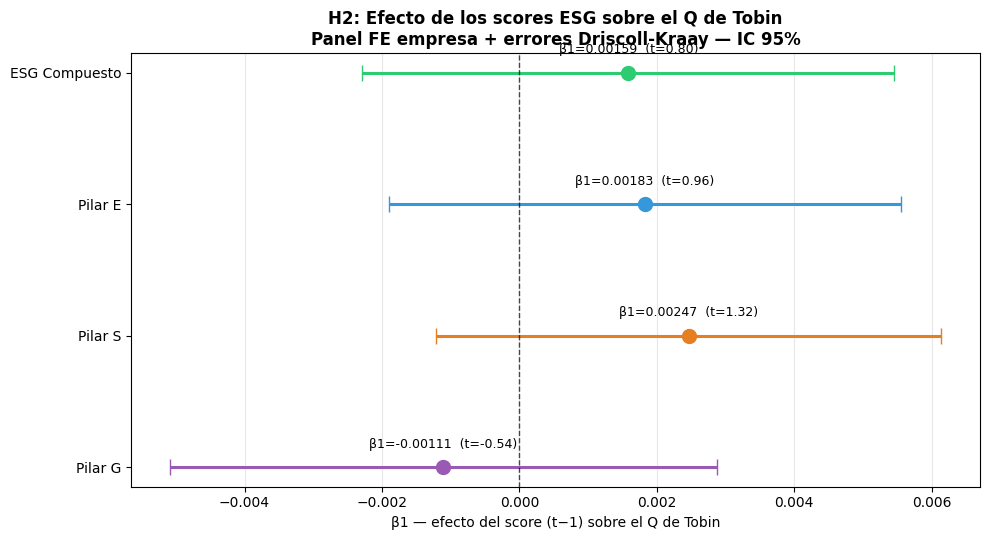

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h2_forest_beta1.png

  Gráfico 2: Binscatter Q vs ESG (crudo vs within)...


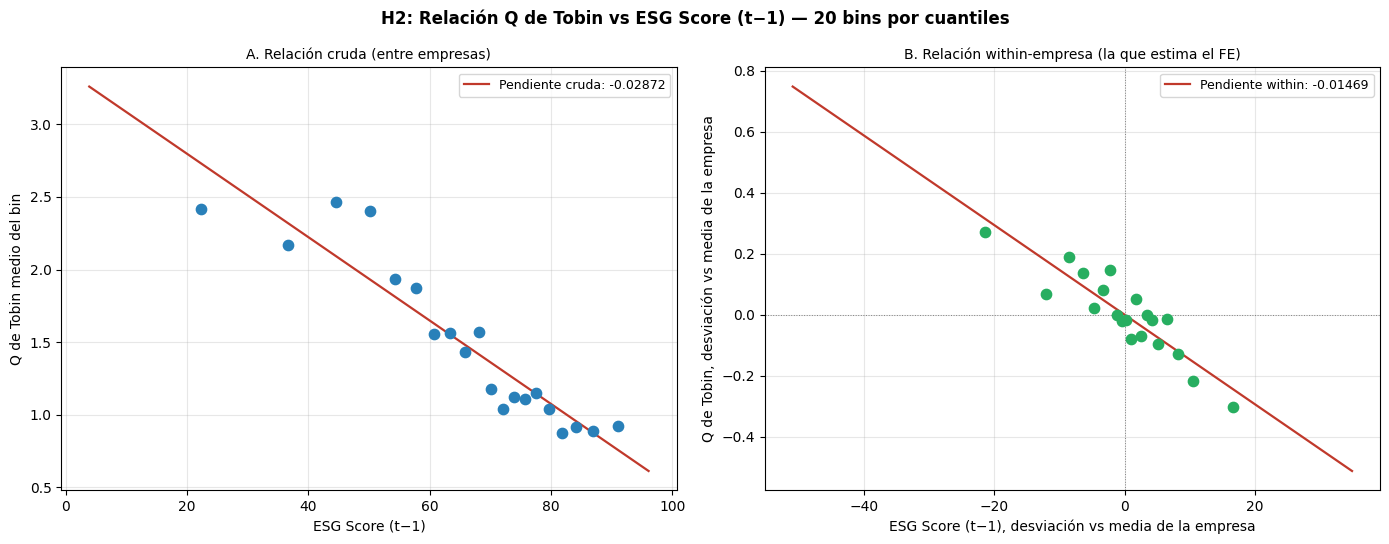

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h2_binscatter_q_esg.png

  Gráfico 3: Evolución temporal del Q por tercil ESG...


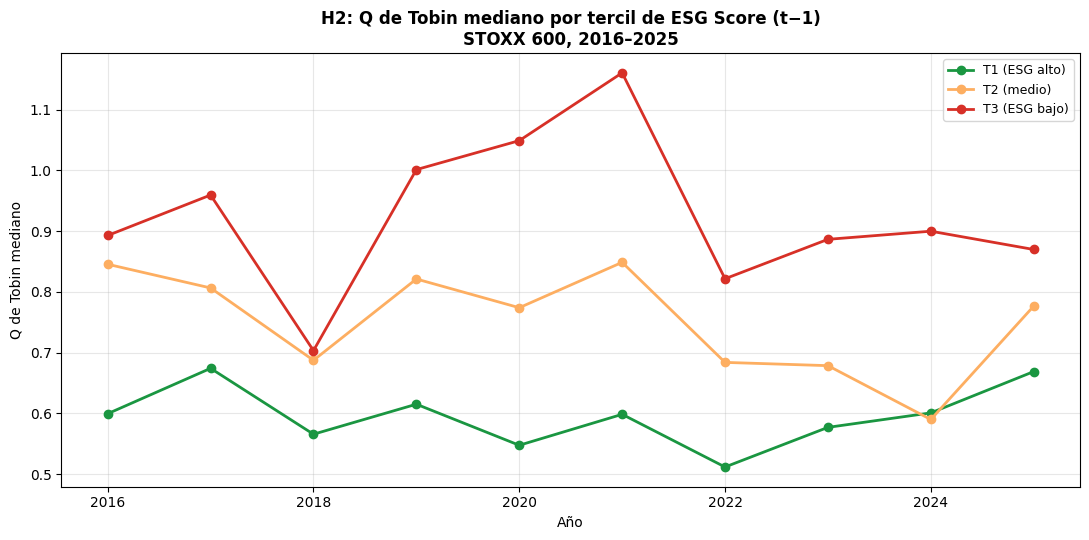

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h2_evolucion_q_terciles.png

  Gráfico 4 (anexo): Distribución del Q de Tobin RAW vs winsorizado...


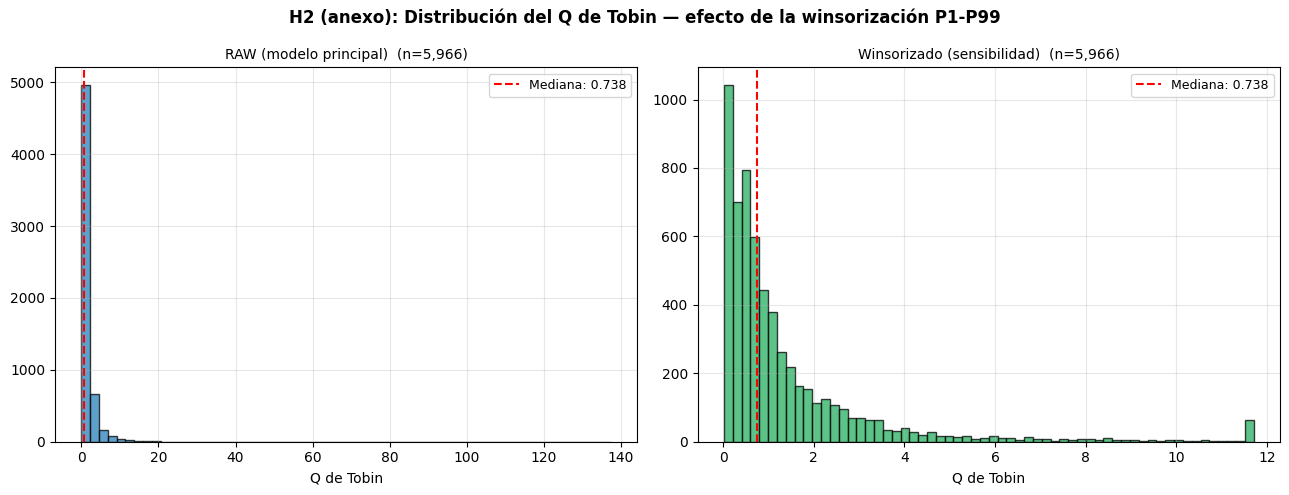

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h2_dist_qtobin.png

RESUMEN EJECUTIVO — HIPÓTESIS 2

  β1 por score (FE empresa + Driscoll-Kraay, modelo RAW):
  Score                    β1     t-DK         p   Sig  Efecto +10pts
  ────────────────────────────────────────────────────────────────────
  ESG Compuesto       0.00159    0.803    0.4219               0.0159
  Pilar E             0.00183    0.962    0.3359               0.0183
  Pilar S             0.00247    1.316    0.1882               0.0247
  Pilar G            -0.00111   -0.545    0.5859              -0.0111

  Hausman: FE preferido en todos los scores
  Diagnósticos: AR(1) sí | Heterocedasticidad sí | Dependencia transversal sí
  → Inferencia con errores Driscoll-Kraay justificada empíricamente.

  CONCLUSIÓN H2 (matriz de especificaciones, Sección 6C):
  · Modelo principal pre-especificado (FE empresa + DK, RAW): SIN EFECTO
    significativo de ningún pilar sobre el Q de Tobin → H2 no se sostiene
    en su for

In [23]:
# ==============================================================================
# SCRIPT 3.3: HIPÓTESIS 2 — PREFERENCIAS DEL MERCADO Y VALORACIÓN (Q DE TOBIN)
# ==============================================================================
#
# PREGUNTA: ¿El mercado europeo valora de forma diferente los tres pilares
# E, S, G? ¿Cuál genera mayor valor corporativo a largo plazo?
#
# MODELO (panel con efectos fijos por empresa):
#   TobinQ_it = β0 + β1·ESG_it-1 + β2·Size_it + β3·Lev_it + β4·ROA_it
#               + β5·Growth_it + μ_i + ε_it
#
#   donde:
#     TobinQ_it = Market_Cap / Total_Assets (último día del año)
#     ESG_it-1  = score rezagado un año (anti look-ahead bias)
#     μ_i       = efecto fijo por empresa (heterogeneidad no observable)
#
# METODOLOGÍA (protocolo HITO 3):
#   1. Test de Hausman → decide FE vs RE
#   2. Diagnósticos del panel → justifican errores Driscoll-Kraay
#   3. Estimación FE + Driscoll-Kraay (dependencia transversal + autocorrelación)
#   4. 4 regresiones separadas: ESG_Score, E_Score, S_Score, G_Score
#
# CRITERIO DE DECISIÓN (guía HITO 3):
#   Zona Verde:  β1 > 0 significativo en pilar G o S → el mercado premia la
#                mitigación de controversias socio-gubernamentales (Sandretto 2025)
#   Zona Roja:   β1 < 0 en pilar E → el costo de la transición ambiental
#                penaliza la valuación a corto/medio plazo (Oluwakemi & Mishelle 2025)
#
# NOTA primer_año_esg: es constante por empresa → queda absorbida por los
# efectos fijos μ_i. No se incluye como regresor (sería colineal); el control
# de adopción temprana/tardía de ESG está implícito en el FE.
#
# REQUIERE: df_annual_raw y df_annual_w (Script 2.3) en memoria
# ==============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# linearmodels: estimador de panel con soporte Driscoll-Kraay (cov_type='kernel')
try:
    from linearmodels.panel import PanelOLS, RandomEffects
except ImportError:
    import subprocess, sys
    print("  Instalando linearmodels...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'linearmodels'])
    from linearmodels.panel import PanelOLS, RandomEffects

print("=" * 80)
print("SCRIPT 3.3: HIPÓTESIS 2 — PANEL Q DE TOBIN (FE + DRISCOLL-KRAAY)")
print("=" * 80)
print(f"\nInicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

for var, nombre in [('df_annual_raw', 'Script 2.3'),
                    ('df_annual_w',   'Script 2.3')]:
    if var not in dir():
        print(f"❌ '{var}' no está en memoria. Ejecuta {nombre} primero.")
        raise SystemExit

SCORES = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']
SCORE_LABELS = {'ESG_Score': 'ESG Compuesto', 'E_Score': 'Pilar E',
                'S_Score': 'Pilar S', 'G_Score': 'Pilar G'}
CONTROLES = ['Size', 'Leverage', 'ROA_Final', 'Growth']
VAR_DEP = 'Q_Tobin'


def sig_stars(p):
    if   p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else:          return ''

# ==============================================================================
# SECCIÓN 1: PREPARACIÓN DEL PANEL Y ESTADÍSTICA DESCRIPTIVA
# ==============================================================================

print("─" * 80)
print("SECCIÓN 1: Preparación del panel y estadística descriptiva")
print("─" * 80)


def preparar_panel(df_annual):
    """Indexa el panel (RIC, Year) para linearmodels."""
    panel = df_annual.copy()
    panel['Year'] = panel['Year'].astype(int)
    return panel.set_index(['RIC', 'Year'])


panel_raw = preparar_panel(df_annual_raw)
panel_w   = preparar_panel(df_annual_w)

print(f"\n  Panel RAW: {len(panel_raw):,} obs | "
      f"{panel_raw.index.get_level_values('RIC').nunique()} empresas | "
      f"{panel_raw.index.get_level_values('Year').nunique()} años "
      f"({panel_raw.index.get_level_values('Year').min()}-{panel_raw.index.get_level_values('Year').max()})")

# Muestra efectiva por score (dropna del modelo completo)
print(f"\n  Muestra efectiva por regresión (tras dropna):")
for score in SCORES:
    cols_modelo = [VAR_DEP, f'{score}_lag1'] + CONTROLES
    n_eff = panel_raw[cols_modelo].dropna().shape[0]
    print(f"    {SCORE_LABELS[score]:<15}: {n_eff:,} obs empresa-año")

# Estadística descriptiva de las variables del modelo
print(f"\n  TABLA 1A — Estadística descriptiva (panel RAW):")
print(f"  {'Variable':<18} {'n':>6} {'Media':>9} {'Desv':>9} {'P25':>8} {'Mediana':>8} {'P75':>8} {'Mín':>9} {'Máx':>9}")
print(f"  {'─'*92}")
for col in [VAR_DEP, 'ESG_Score_lag1', 'E_Score_lag1', 'S_Score_lag1', 'G_Score_lag1'] + CONTROLES:
    s = panel_raw[col].dropna()
    print(f"  {col:<18} {len(s):>6,} {s.mean():>9.3f} {s.std():>9.3f} {s.quantile(0.25):>8.3f} "
          f"{s.median():>8.3f} {s.quantile(0.75):>8.3f} {s.min():>9.3f} {s.max():>9.3f}")

# Matriz de correlaciones de las variables del modelo (chequeo multicolinealidad)
print(f"\n  TABLA 1B — Correlaciones entre regresores (panel RAW):")
vars_corr = ['ESG_Score_lag1'] + CONTROLES
corr_panel = panel_raw[vars_corr].dropna().corr()
print("  " + corr_panel.round(3).to_string().replace('\n', '\n  '))

alta_corr = False
for i in range(len(vars_corr)):
    for j in range(i+1, len(vars_corr)):
        c = corr_panel.iloc[i, j]
        if abs(c) > 0.5:
            print(f"\n  ⚠️  Correlación alta: {vars_corr[i]} ↔ {vars_corr[j]} = {c:.3f}")
            alta_corr = True
if not alta_corr:
    print(f"\n  ✅ Sin correlaciones > |0.50| entre regresores → multicolinealidad controlada")

# ==============================================================================
# SECCIÓN 2: TEST DE HAUSMAN — EFECTOS FIJOS vs ALEATORIOS
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 2: Test de Hausman — ¿Efectos Fijos o Aleatorios?")
print("─" * 80)

print("""
Test de Hausman (1978):
  H0: la diferencia entre estimadores FE y RE no es sistemática → RE es
      consistente y eficiente (preferir RE)
  H1: los efectos individuales están correlacionados con los regresores
      → solo FE es consistente (preferir FE)
  Estadístico: H = (b_FE − b_RE)' [V_FE − V_RE]⁻¹ (b_FE − b_RE) ~ χ²(k)
""")


def ajustar_fe(panel, score, cov='unadjusted'):
    """Estima el modelo FE para un score. cov: 'unadjusted' o 'kernel' (Driscoll-Kraay)."""
    cols = [VAR_DEP, f'{score}_lag1'] + CONTROLES
    datos = panel[cols].dropna()
    y = datos[VAR_DEP]
    X = datos[[f'{score}_lag1'] + CONTROLES]
    mod = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
    if cov == 'kernel':
        return mod.fit(cov_type='kernel', kernel='bartlett'), datos
    return mod.fit(), datos


def ajustar_re(panel, score):
    """Estima el modelo RE (con constante) para un score."""
    cols = [VAR_DEP, f'{score}_lag1'] + CONTROLES
    datos = panel[cols].dropna()
    y = datos[VAR_DEP]
    X = sm.add_constant(datos[[f'{score}_lag1'] + CONTROLES])
    return RandomEffects(y, X).fit(), datos


def test_hausman(fe_res, re_res):
    """Test de Hausman clásico sobre los coeficientes comunes (sin constante)."""
    comunes = [c for c in fe_res.params.index if c in re_res.params.index and c != 'const']
    b_fe = fe_res.params[comunes].values
    b_re = re_res.params[comunes].values
    v_fe = fe_res.cov.loc[comunes, comunes].values
    v_re = re_res.cov.loc[comunes, comunes].values
    diff = b_fe - b_re
    V = v_fe - v_re
    stat = float(diff @ np.linalg.pinv(V) @ diff)
    gl = len(comunes)
    p_val = 1 - stats.chi2.cdf(stat, gl)
    return stat, gl, p_val


print(f"  {'Score':<15} {'χ²':>10} {'gl':>4} {'p-value':>10}   Decisión")
print(f"  {'─'*65}")

hausman_resultados = {}
for score in SCORES:
    fe_res, _ = ajustar_fe(panel_raw, score)
    re_res, _ = ajustar_re(panel_raw, score)
    h_stat, gl, p_h = test_hausman(fe_res, re_res)
    hausman_resultados[score] = {'chi2': h_stat, 'gl': gl, 'p': p_h}
    dec = "Rechazar H0 → usar FE ✅" if p_h < 0.05 else "No rechazar H0 → RE admisible"
    print(f"  {SCORE_LABELS[score]:<15} {h_stat:>10.3f} {gl:>4} {p_h:>10.4f}   {dec}")

print("""
  Nota: cuando V_FE − V_RE no es definida positiva se usa la pseudo-inversa
  (Moore-Penrose), práctica estándar. La heterogeneidad no observable por
  empresa (sector, país, gobernanza histórica) hace esperar el rechazo de H0.
""")

# ==============================================================================
# SECCIÓN 3: DIAGNÓSTICOS DEL PANEL — JUSTIFICACIÓN DE DRISCOLL-KRAAY
# ==============================================================================

print("─" * 80)
print("SECCIÓN 3: Diagnósticos del panel (sobre residuos FE del modelo ESG)")
print("─" * 80)

print("""
Tres diagnósticos que motivan el uso de errores estándar Driscoll-Kraay:
  1. Autocorrelación serial AR(1) en los residuos (dimensión temporal)
  2. Heterocedasticidad — Breusch-Pagan (varianza no constante)
  3. Dependencia transversal — Pesaran CD (shocks comunes entre empresas)
""")

fe_esg, datos_esg = ajustar_fe(panel_raw, 'ESG_Score')
resid_esg = fe_esg.resids.copy()
resid_df = resid_esg.reset_index()
resid_df.columns = ['RIC', 'Year', 'resid']

# ── 3.1 Autocorrelación AR(1): e_it sobre e_i,t-1 (pooled con cluster empresa) ─
resid_df = resid_df.sort_values(['RIC', 'Year'])
resid_df['resid_lag'] = resid_df.groupby('RIC')['resid'].shift(1)
ar_data = resid_df.dropna(subset=['resid', 'resid_lag'])

X_ar = sm.add_constant(ar_data['resid_lag'])
mod_ar = sm.OLS(ar_data['resid'], X_ar).fit(
    cov_type='cluster', cov_kwds={'groups': ar_data['RIC']})
rho = mod_ar.params['resid_lag']
t_rho = mod_ar.tvalues['resid_lag']
p_rho = mod_ar.pvalues['resid_lag']

print(f"  1. AUTOCORRELACIÓN AR(1) (residuos FE, errores cluster por empresa):")
print(f"     ρ = {rho:.4f} | t = {t_rho:.3f} | p = {p_rho:.4f}")
print(f"     {'⚠️  Autocorrelación significativa → Driscoll-Kraay necesario' if p_rho < 0.05 else '✅ Sin autocorrelación significativa'}")

# ── 3.2 Heterocedasticidad: Breusch-Pagan sobre residuos² vs regresores ───────
from statsmodels.stats.diagnostic import het_breuschpagan
X_bp = sm.add_constant(datos_esg[['ESG_Score_lag1'] + CONTROLES])
bp_stat, bp_p, _, _ = het_breuschpagan(resid_esg.values, X_bp.values)

print(f"\n  2. HETEROCEDASTICIDAD (Breusch-Pagan):")
print(f"     LM = {bp_stat:.2f} | p = {bp_p:.2e}")
print(f"     {'⚠️  Heterocedasticidad presente → errores robustos necesarios' if bp_p < 0.05 else '✅ Homocedasticidad no rechazada'}")

# ── 3.3 Dependencia transversal: test CD de Pesaran (2004) ────────────────────
res_piv = resid_df.pivot(index='Year', columns='RIC', values='resid')
M = res_piv.notna().astype(float).values            # T × N indicador
Tij = M.T @ M                                        # solapamiento por par
R = res_piv.corr(min_periods=4).values               # correlaciones por par

N_cd = R.shape[0]
iu = np.triu_indices(N_cd, k=1)
validos = (~np.isnan(R[iu])) & (Tij[iu] >= 4)
cd_stat = np.sqrt(2 / (N_cd * (N_cd - 1))) * np.nansum(
    np.sqrt(Tij[iu][validos]) * R[iu][validos])
p_cd = 2 * (1 - stats.norm.cdf(abs(cd_stat)))

print(f"\n  3. DEPENDENCIA TRANSVERSAL (Pesaran CD):")
print(f"     CD = {cd_stat:.3f} | p = {p_cd:.2e} | pares válidos: {validos.sum():,}")
print(f"     {'⚠️  Dependencia transversal → Driscoll-Kraay imprescindible' if p_cd < 0.05 else '✅ Sin dependencia transversal significativa'}")

print("""
  CONCLUSIÓN: los errores estándar Driscoll-Kraay (kernel Bartlett) corrigen
  simultáneamente las tres violaciones, por lo que toda la inferencia de H2
  se realiza con esta matriz de covarianzas.
""")

# ==============================================================================
# SECCIÓN 4: REGRESIONES FE + DRISCOLL-KRAAY — 4 SCORES
# ==============================================================================

print("─" * 80)
print("SECCIÓN 4: Regresiones FE + Driscoll-Kraay (modelo principal RAW)")
print("─" * 80)


def correr_panel(panel, etiqueta='RAW'):
    """Corre las 4 regresiones FE+DK y devuelve dict de resultados y tabla."""
    resultados = {}
    filas = []
    for score in SCORES:
        res, datos = ajustar_fe(panel, score, cov='kernel')
        resultados[score] = {'res': res, 'datos': datos}
        var_score = f'{score}_lag1'
        fila = {
            'score': score, 'version': etiqueta,
            'beta1': res.params[var_score],
            't_beta1': res.tstats[var_score],
            'p_beta1': res.pvalues[var_score],
            'n': res.nobs,
            'empresas': datos.reset_index()['RIC'].nunique(),
            'R2_within': res.rsquared_within,
            'F_stat': res.f_statistic.stat,
            'p_F': res.f_statistic.pval,
        }
        for c in CONTROLES:
            fila[f'b_{c}'] = res.params[c]
            fila[f't_{c}'] = res.tstats[c]
            fila[f'p_{c}'] = res.pvalues[c]
        filas.append(fila)
    return resultados, pd.DataFrame(filas)


print("  Estimando 4 regresiones RAW (FE + Driscoll-Kraay)...")
res_raw, tabla_raw = correr_panel(panel_raw, 'RAW')

print("  Estimando 4 regresiones WINSORIZADO (sensibilidad)...")
res_w, tabla_w = correr_panel(panel_w, 'WINS')

# ── TABLA 4A: coeficientes completos por score (estilo paper) ─────────────────
print("\n" + "═" * 80)
print("TABLA 4A — REGRESIONES PANEL Q DE TOBIN (FE empresa + Driscoll-Kraay)")
print("═" * 80)
print("""
Variable dependiente: Q de Tobin. Cada columna es una regresión independiente
con el score indicado. t-stats Driscoll-Kraay entre paréntesis conceptuales.
""")

print(f"  {'Variable':<18} {'ESG Compuesto':>16} {'Pilar E':>16} {'Pilar S':>16} {'Pilar G':>16}")
print(f"  {'─'*86}")

# β1 (score)
linea_b, linea_t = f"  {'Score (t-1) β1':<18}", f"  {'':<18}"
for score in SCORES:
    r = tabla_raw[tabla_raw['score'] == score].iloc[0]
    stars = sig_stars(r['p_beta1'])
    linea_b += f"{r['beta1']:>12.5f}{stars:<4}"
    linea_t += f"{'(' + format(r['t_beta1'], '.2f') + ')':>16}"
print(linea_b)
print(linea_t)

# Controles
for c in CONTROLES:
    linea_b, linea_t = f"  {c:<18}", f"  {'':<18}"
    for score in SCORES:
        r = tabla_raw[tabla_raw['score'] == score].iloc[0]
        stars = sig_stars(r[f'p_{c}'])
        linea_b += f"{r[f'b_{c}']:>12.5f}{stars:<4}"
        linea_t += f"{'(' + format(r[f't_{c}'], '.2f') + ')':>16}"
    print(linea_b)
    print(linea_t)

# Estadísticos del modelo
print(f"  {'─'*86}")
for etiqueta, campo, fmt in [('Obs (empresa-año)', 'n', ',.0f'),
                              ('Empresas', 'empresas', ',.0f'),
                              ('R² within', 'R2_within', '.4f'),
                              ('F-stat', 'F_stat', '.2f')]:
    linea = f"  {etiqueta:<18}"
    for score in SCORES:
        r = tabla_raw[tabla_raw['score'] == score].iloc[0]
        linea += f"{format(r[campo], fmt):>16}"
    print(linea)

print(f"""
  Significación: *** p<0.01, ** p<0.05, * p<0.10
  Todos los modelos incluyen efectos fijos por empresa (μ_i).
  Errores estándar Driscoll-Kraay (kernel Bartlett, bandwidth automático).
""")

# ── TABLA 4B: interpretación económica de β1 ──────────────────────────────────
print("═" * 80)
print("TABLA 4B — INTERPRETACIÓN ECONÓMICA DE β1")
print("═" * 80)

q_mediano = panel_raw[VAR_DEP].median()
print(f"""
  Efecto de +10 puntos de score (escala 0-100) sobre el Q de Tobin.
  Q de Tobin mediano de la muestra: {q_mediano:.4f}
""")

print(f"  {'Score':<15} {'β1':>10} {'Efecto +10pts':>14} {'% sobre Q med':>14} {'Sig':>5}")
print(f"  {'─'*64}")
for score in SCORES:
    r = tabla_raw[tabla_raw['score'] == score].iloc[0]
    efecto10 = r['beta1'] * 10
    pct = efecto10 / q_mediano * 100
    stars = sig_stars(r['p_beta1'])
    print(f"  {SCORE_LABELS[score]:<15} {r['beta1']:>10.5f} {efecto10:>14.4f} {pct:>13.2f}% {stars:>5}")

# ==============================================================================
# SECCIÓN 5: DECISIÓN H2 — ZONAS DE LA GUÍA HITO 3
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 5: Decisión H2 según protocolo HITO 3")
print("─" * 80)

b_E = tabla_raw[tabla_raw['score'] == 'E_Score'].iloc[0]
b_S = tabla_raw[tabla_raw['score'] == 'S_Score'].iloc[0]
b_G = tabla_raw[tabla_raw['score'] == 'G_Score'].iloc[0]

zona_verde = ((b_S['beta1'] > 0 and b_S['p_beta1'] < 0.05) or
              (b_G['beta1'] > 0 and b_G['p_beta1'] < 0.05))
zona_roja  = (b_E['beta1'] < 0 and b_E['p_beta1'] < 0.05)

print(f"""
  Criterios (guía HITO 3):
  · Zona Verde (creación de valor): β1 > 0 significativo en pilar S o G
    → Pilar S: β1 = {b_S['beta1']:.5f} (p = {b_S['p_beta1']:.4f}) {'✅ cumple' if b_S['beta1'] > 0 and b_S['p_beta1'] < 0.05 else '— no cumple'}
    → Pilar G: β1 = {b_G['beta1']:.5f} (p = {b_G['p_beta1']:.4f}) {'✅ cumple' if b_G['beta1'] > 0 and b_G['p_beta1'] < 0.05 else '— no cumple'}
  · Zona Roja (destrucción de valor): β1 < 0 significativo en pilar E
    → Pilar E: β1 = {b_E['beta1']:.5f} (p = {b_E['p_beta1']:.4f}) {'🔴 cumple' if zona_roja else '— no cumple'}

  RESULTADO:
""")

if zona_verde and not zona_roja:
    print("  ✅ ZONA VERDE: el mercado premia la dimensión socio-gubernamental")
    print("     (consistente con Sandretto et al. 2025)")
elif zona_roja and not zona_verde:
    print("  🔴 ZONA ROJA: la transición ambiental penaliza la valuación")
    print("     (consistente con Oluwakemi & Mishelle 2025)")
elif zona_verde and zona_roja:
    print("  🟡 RESULTADO MIXTO: S/G crean valor pero E lo destruye")
    print("     (ambas literaturas se confirman simultáneamente)")
else:
    print("  ⚪ SIN EFECTO SIGNIFICATIVO: ninguno de los pilares mueve el Q de Tobin")
    print("     (la valoración ya incorpora la información ESG, o el efecto se")
    print("     captura en el canal rentabilidad —ver H1— y no en el de valuación)")

# ==============================================================================
# SECCIÓN 6: SENSIBILIDAD — RAW vs WINSORIZADO Y FE TWO-WAY
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 6: Sensibilidad — RAW vs Winsorizado + efectos de tiempo")
print("─" * 80)

print(f"\n  6A. RAW vs WINSORIZADO (β1, t-DK y p por score):")
print(f"  {'Score':<15} {'β1_RAW':>10} {'t':>7} {'p':>8} {'β1_WINS':>10} {'t':>7} {'p':>8}   Veredicto")
print(f"  {'─'*88}")
for score in SCORES:
    r_raw  = tabla_raw[tabla_raw['score'] == score].iloc[0]
    r_wins = tabla_w[tabla_w['score'] == score].iloc[0]
    sig_raw  = r_raw['p_beta1'] < 0.05
    sig_wins = r_wins['p_beta1'] < 0.05
    mismo_signo = np.sign(r_raw['beta1']) == np.sign(r_wins['beta1'])
    if not sig_raw and not sig_wins:
        veredicto = "✅ Consistente: sin efecto en ambas"
    elif sig_raw and sig_wins and mismo_signo:
        veredicto = "✅ Robusto: significativo en ambas"
    elif sig_raw != sig_wins:
        veredicto = "⚠️  Cambia la significación"
    else:
        veredicto = "🔴 Cambia el signo"
    print(f"  {SCORE_LABELS[score]:<15} {r_raw['beta1']:>10.5f} {r_raw['t_beta1']:>7.2f} {r_raw['p_beta1']:>8.4f} "
          f"{r_wins['beta1']:>10.5f} {r_wins['t_beta1']:>7.2f} {r_wins['p_beta1']:>8.4f}   {veredicto}")

print("""
  Nota: con β1 ≈ 0 la variación porcentual entre versiones es una métrica
  engañosa (divide por un número casi nulo). El criterio correcto es comparar
  la significación estadística: si ambas versiones concluyen "sin efecto",
  el hallazgo es consistente.
""")

# 6B. Robustez: FE two-way (empresa + año) para los 4 scores
print(f"\n  6B. Robustez FE two-way (empresa + año) — los 4 scores:")
print(f"  {'Score':<15} {'β1 1-way':>10} {'t':>7} {'p':>8} {'β1 2-way':>10} {'t':>7} {'p':>8} {'Sig':>5}")
print(f"  {'─'*82}")

res_2w_all = {}
for score in SCORES:
    cols_m = [VAR_DEP, f'{score}_lag1'] + CONTROLES
    datos_m = panel_raw[cols_m].dropna()
    mod_2w = PanelOLS(datos_m[VAR_DEP], datos_m[[f'{score}_lag1'] + CONTROLES],
                      entity_effects=True, time_effects=True, drop_absorbed=True)
    r2w = mod_2w.fit(cov_type='kernel', kernel='bartlett')
    res_2w_all[score] = r2w

    r_1w = tabla_raw[tabla_raw['score'] == score].iloc[0]
    var_s = f'{score}_lag1'
    stars = sig_stars(r2w.pvalues[var_s])
    print(f"  {SCORE_LABELS[score]:<15} {r_1w['beta1']:>10.5f} {r_1w['t_beta1']:>7.2f} {r_1w['p_beta1']:>8.4f} "
          f"{r2w.params[var_s]:>10.5f} {r2w.tstats[var_s]:>7.2f} {r2w.pvalues[var_s]:>8.4f} {stars:>5}")

# Mantener referencia para el resumen ejecutivo
res_2w = res_2w_all['ESG_Score']

print("""
  Lectura: si β1 cambia al añadir efectos de año, parte de la relación entre
  ESG y Q en el modelo de un solo efecto proviene de tendencias temporales
  comunes (los scores ESG y el Q de Tobin comparten tendencia en 2016-2025).
  El two-way aísla la variación within empresa y within año: un β1 negativo
  aquí es coherente con el alpha negativo del ESG hallado en H1 (Green
  Premium: el mercado paga sobreprecio por ESG y ajusta la valuación después).
""")

# 6C. Matriz completa de especificaciones: β1 en las 4 combinaciones
print(f"\n  6C. Matriz de especificaciones — β1 por score (con significación):")
print(f"  {'Score':<15} {'1way RAW':>14} {'1way WINS':>14} {'2way RAW':>14} {'2way WINS':>14}")
print(f"  {'─'*75}")


def beta1_con_stars(beta, p):
    return f"{beta:.5f}{sig_stars(p)}"


res_2w_wins = {}
for score in SCORES:
    cols_m = [VAR_DEP, f'{score}_lag1'] + CONTROLES
    datos_mw = panel_w[cols_m].dropna()
    mod_2ww = PanelOLS(datos_mw[VAR_DEP], datos_mw[[f'{score}_lag1'] + CONTROLES],
                       entity_effects=True, time_effects=True, drop_absorbed=True)
    r2ww = mod_2ww.fit(cov_type='kernel', kernel='bartlett')
    res_2w_wins[score] = r2ww

    var_s = f'{score}_lag1'
    r_1w_raw  = tabla_raw[tabla_raw['score'] == score].iloc[0]
    r_1w_wins = tabla_w[tabla_w['score'] == score].iloc[0]
    r_2w_raw  = res_2w_all[score]

    print(f"  {SCORE_LABELS[score]:<15} "
          f"{beta1_con_stars(r_1w_raw['beta1'], r_1w_raw['p_beta1']):>14} "
          f"{beta1_con_stars(r_1w_wins['beta1'], r_1w_wins['p_beta1']):>14} "
          f"{beta1_con_stars(r_2w_raw.params[var_s], r_2w_raw.pvalues[var_s]):>14} "
          f"{beta1_con_stars(r2ww.params[var_s], r2ww.pvalues[var_s]):>14}")

print(f"\n  t-stats Driscoll-Kraay de la columna 2way WINS:")
for score in SCORES:
    var_s = f'{score}_lag1'
    r = res_2w_wins[score]
    print(f"    {SCORE_LABELS[score]:<15} β1 = {r.params[var_s]:>9.5f} | t = {r.tstats[var_s]:>6.2f} | p = {r.pvalues[var_s]:.4f}")

print("""
  Lectura de la matriz completa:
  · El signo positivo del 1way WINS desaparece y se invierte al añadir efectos
    de año → era tendencia temporal compartida (ESG y Q suben juntos en el
    período), no relación estructural.
  · ESG Compuesto y Pilar G mantienen β1 NEGATIVO significativo en ambas
    versiones two-way → hallazgo secundario robusto a outliers, coherente con
    el alpha negativo de H1 (Green Premium).
  · Pilares E y S no son robustos en two-way WINS → sin efecto concluyente.
""")

# ==============================================================================
# SECCIÓN 7: GRÁFICOS
# ==============================================================================

print("─" * 80)
print("SECCIÓN 7: Gráficos — H2")
print("─" * 80)

import os
RUTA_GRAFICOS = '/content/drive/MyDrive/TFM_STOXX600/HITO4'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

colores_score = {'ESG_Score': '#2ecc71', 'E_Score': '#3498db',
                 'S_Score': '#e67e22', 'G_Score': '#9b59b6'}

# ── Gráfico 1: Forest plot — β1 por pilar con IC 95% (Driscoll-Kraay) ─────────
print("\n  Gráfico 1: Forest plot de β1 por pilar...")

fig, ax = plt.subplots(figsize=(10, 5.5))

posiciones = np.arange(len(SCORES))[::-1]
for pos, score in zip(posiciones, SCORES):
    r = tabla_raw[tabla_raw['score'] == score].iloc[0]
    se = r['beta1'] / r['t_beta1'] if r['t_beta1'] != 0 else np.nan
    ic = 1.96 * abs(se)
    color = colores_score[score]
    ax.errorbar(r['beta1'], pos, xerr=ic, fmt='o', color=color,
                markersize=10, capsize=6, linewidth=2.2)
    stars = sig_stars(r['p_beta1'])
    ax.annotate(f"β1={r['beta1']:.5f}{stars}  (t={r['t_beta1']:.2f})",
                xy=(r['beta1'], pos), xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=9)

ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_yticks(posiciones)
ax.set_yticklabels([SCORE_LABELS[s] for s in SCORES])
ax.set_xlabel('β1 — efecto del score (t−1) sobre el Q de Tobin')
ax.set_title('H2: Efecto de los scores ESG sobre el Q de Tobin\n'
             'Panel FE empresa + errores Driscoll-Kraay — IC 95%',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h2_forest_beta1.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 2: Binscatter Q de Tobin vs ESG (crudo y within-empresa) ──────────
print("\n  Gráfico 2: Binscatter Q vs ESG (crudo vs within)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('H2: Relación Q de Tobin vs ESG Score (t−1) — 20 bins por cuantiles',
             fontsize=12, fontweight='bold')

datos_bs = panel_raw[[VAR_DEP, 'ESG_Score_lag1']].dropna().reset_index()

# Panel A: relación cruda
ax = axes[0]
datos_bs['bin'] = pd.qcut(datos_bs['ESG_Score_lag1'], 20, labels=False, duplicates='drop')
binned = datos_bs.groupby('bin').agg(x=('ESG_Score_lag1', 'mean'), y=(VAR_DEP, 'mean'))
ax.scatter(binned['x'], binned['y'], s=55, color='#2980b9', zorder=3)
slope, intercept = np.polyfit(datos_bs['ESG_Score_lag1'], datos_bs[VAR_DEP], 1)
xs = np.linspace(datos_bs['ESG_Score_lag1'].min(), datos_bs['ESG_Score_lag1'].max(), 50)
ax.plot(xs, intercept + slope * xs, color='#c0392b', linewidth=1.6,
        label=f'Pendiente cruda: {slope:.5f}')
ax.set_title('A. Relación cruda (entre empresas)', fontsize=10)
ax.set_xlabel('ESG Score (t−1)')
ax.set_ylabel('Q de Tobin medio del bin')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: relación within (demeaned por empresa = lo que estima el FE)
ax = axes[1]
datos_w_bs = datos_bs.copy()
for col in [VAR_DEP, 'ESG_Score_lag1']:
    datos_w_bs[col] = datos_w_bs[col] - datos_w_bs.groupby('RIC')[col].transform('mean')
datos_w_bs['bin'] = pd.qcut(datos_w_bs['ESG_Score_lag1'], 20, labels=False, duplicates='drop')
binned_w = datos_w_bs.groupby('bin').agg(x=('ESG_Score_lag1', 'mean'), y=(VAR_DEP, 'mean'))
ax.scatter(binned_w['x'], binned_w['y'], s=55, color='#27ae60', zorder=3)
slope_w, intercept_w = np.polyfit(datos_w_bs['ESG_Score_lag1'], datos_w_bs[VAR_DEP], 1)
xs_w = np.linspace(datos_w_bs['ESG_Score_lag1'].min(), datos_w_bs['ESG_Score_lag1'].max(), 50)
ax.plot(xs_w, intercept_w + slope_w * xs_w, color='#c0392b', linewidth=1.6,
        label=f'Pendiente within: {slope_w:.5f}')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_title('B. Relación within-empresa (la que estima el FE)', fontsize=10)
ax.set_xlabel('ESG Score (t−1), desviación vs media de la empresa')
ax.set_ylabel('Q de Tobin, desviación vs media de la empresa')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h2_binscatter_q_esg.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 3: Evolución del Q de Tobin mediano por tercil ESG ────────────────
print("\n  Gráfico 3: Evolución temporal del Q por tercil ESG...")

datos_ev = panel_raw[[VAR_DEP, 'ESG_Score_lag1']].dropna().reset_index()
datos_ev['tercil'] = datos_ev.groupby('Year')['ESG_Score_lag1'].transform(
    lambda s: pd.qcut(s, 3, labels=['T3 (ESG bajo)', 'T2 (medio)', 'T1 (ESG alto)']))

evolucion = datos_ev.groupby(['Year', 'tercil'])[VAR_DEP].median().unstack()

fig, ax = plt.subplots(figsize=(11, 5.5))
colores_t = {'T1 (ESG alto)': '#1a9641', 'T2 (medio)': '#fdae61', 'T3 (ESG bajo)': '#d73027'}
for tercil in ['T1 (ESG alto)', 'T2 (medio)', 'T3 (ESG bajo)']:
    if tercil in evolucion.columns:
        ax.plot(evolucion.index, evolucion[tercil], marker='o', linewidth=2,
                color=colores_t[tercil], label=tercil)

ax.set_title('H2: Q de Tobin mediano por tercil de ESG Score (t−1)\n'
             'STOXX 600, 2016–2025', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Q de Tobin mediano')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h2_evolucion_q_terciles.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 4 (anexo): Distribución del Q de Tobin RAW vs winsorizado ─────────
print("\n  Gráfico 4 (anexo): Distribución del Q de Tobin RAW vs winsorizado...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H2 (anexo): Distribución del Q de Tobin — efecto de la winsorización P1-P99',
             fontsize=12, fontweight='bold')

for ax, (panel_d, titulo, color) in zip(
        axes, [(panel_raw, 'RAW (modelo principal)', '#2980b9'),
               (panel_w, 'Winsorizado (sensibilidad)', '#27ae60')]):
    s = panel_d[VAR_DEP].dropna()
    ax.hist(s, bins=60, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(s.median(), color='red', linestyle='--', lw=1.5,
               label=f'Mediana: {s.median():.3f}')
    ax.set_title(f'{titulo}  (n={len(s):,})', fontsize=10)
    ax.set_xlabel('Q de Tobin')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h2_dist_qtobin.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ==============================================================================
# SECCIÓN 8: RESUMEN EJECUTIVO H2
# ==============================================================================

print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO — HIPÓTESIS 2")
print("=" * 80)

print("\n  β1 por score (FE empresa + Driscoll-Kraay, modelo RAW):")
print(f"  {'Score':<15} {'β1':>11} {'t-DK':>8} {'p':>9} {'Sig':>5} {'Efecto +10pts':>14}")
print(f"  {'─'*68}")
for score in SCORES:
    r = tabla_raw[tabla_raw['score'] == score].iloc[0]
    stars = sig_stars(r['p_beta1'])
    print(f"  {SCORE_LABELS[score]:<15} {r['beta1']:>11.5f} {r['t_beta1']:>8.3f} "
          f"{r['p_beta1']:>9.4f} {stars:>5} {r['beta1']*10:>14.4f}")

print(f"""
  Hausman: FE preferido en {'todos los scores' if all(v['p'] < 0.05 for v in hausman_resultados.values()) else 'parte de los scores (revisar tabla Sección 2)'}
  Diagnósticos: AR(1) {'sí' if p_rho < 0.05 else 'no'} | Heterocedasticidad {'sí' if bp_p < 0.05 else 'no'} | Dependencia transversal {'sí' if p_cd < 0.05 else 'no'}
  → Inferencia con errores Driscoll-Kraay justificada empíricamente.

  CONCLUSIÓN H2 (matriz de especificaciones, Sección 6C):
  · Modelo principal pre-especificado (FE empresa + DK, RAW): SIN EFECTO
    significativo de ningún pilar sobre el Q de Tobin → H2 no se sostiene
    en su formulación original (ni zona verde ni zona roja).
  · El efecto positivo del 1-way winsorizado es tendencia temporal compartida:
    desaparece y se invierte al controlar por efectos de año.
  · Hallazgo secundario robusto: ESG Compuesto (β1={res_2w.params['ESG_Score_lag1']:.5f}, t={res_2w.tstats['ESG_Score_lag1']:.2f} RAW;
    β1={res_2w_wins['ESG_Score'].params['ESG_Score_lag1']:.5f}, t={res_2w_wins['ESG_Score'].tstats['ESG_Score_lag1']:.2f} WINS) y Pilar G muestran efecto
    NEGATIVO within-año robusto a outliers → coherente con el alpha negativo
    de H1 (Green Premium: sobrevaluación de empresas con alto ESG).
""")

print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

# ==============================================================================
# SECCIÓN 9: ANEXO — SUMMARIES COMPLETOS (linearmodels)
# ==============================================================================

print("\n" + "=" * 80)
print("SECCIÓN 9: ANEXO — Summaries completos de las regresiones panel")
print("=" * 80)
print("""
Output completo de linearmodels (formato análogo al summary de statsmodels
del Taller de regresión) para las 4 regresiones principales.
""")

for score in SCORES:
    print(f"\n{'═'*78}")
    print(f"  H2 — {SCORE_LABELS[score]} (FE empresa + Driscoll-Kraay)")
    print(f"{'═'*78}")
    print(res_raw[score]['res'])

### *HIPOTESIS 3*


SCRIPT 3.4 (v2): HIPÓTESIS 3 — MS-CAPM EN DOS ETAPAS

Inicio: 2026-06-11 20:55:48

Índice de mercado: STOXX 600 [NR — Net Return (dividendos netos) ← ACTIVO]

────────────────────────────────────────────────────────────────────────────────
SECCIÓN 1: Markov-Switching sobre el retorno DIARIO del STOXX 600
────────────────────────────────────────────────────────────────────────────────

  Serie diaria del mercado: 2,567 días (2016-01-04 → 2025-12-31)
  Media: 0.0289%/día | Desv: 0.9901%/día
  Serie mensual (Etapa 2): 120 meses

  Estimando MS(2) sobre retornos diarios (media + varianza cambiantes)...
  (la frecuencia diaria identifica los clusters de volatilidad con precisión)
  ✅ Convergió con especificación: media+varianza (453 días en crisis)

  PARÁMETROS DEL MERCADO POR RÉGIMEN (frecuencia diaria):
                  μ (%/día)  σ (%/día)   σ anual   Dur. esp.    Días
  ────────────────────────────────────────────────────────────────────
           CALMA     0.0819     0.6285     10.0

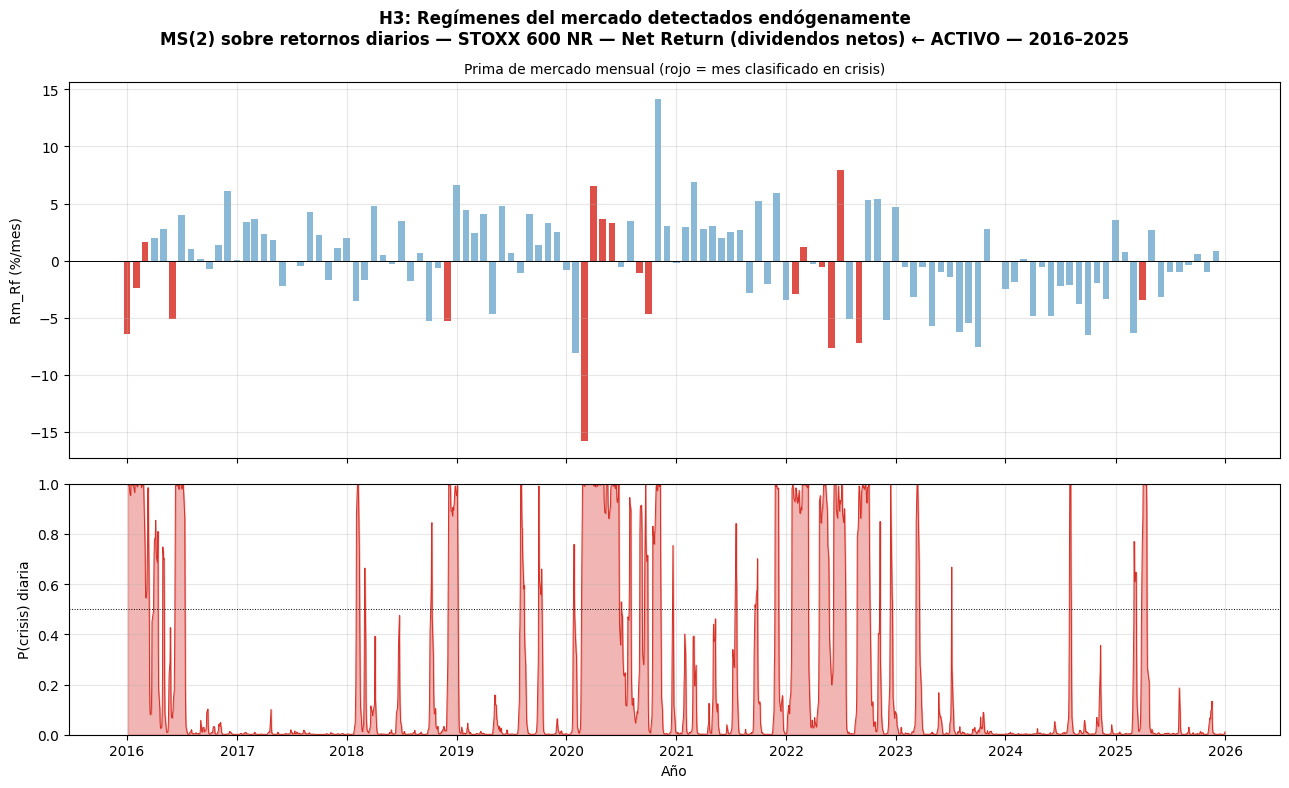

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h3_regimen_mercado.png

  Gráfico 2: Betas por régimen (Q1 vs Q5, 4 scores)...


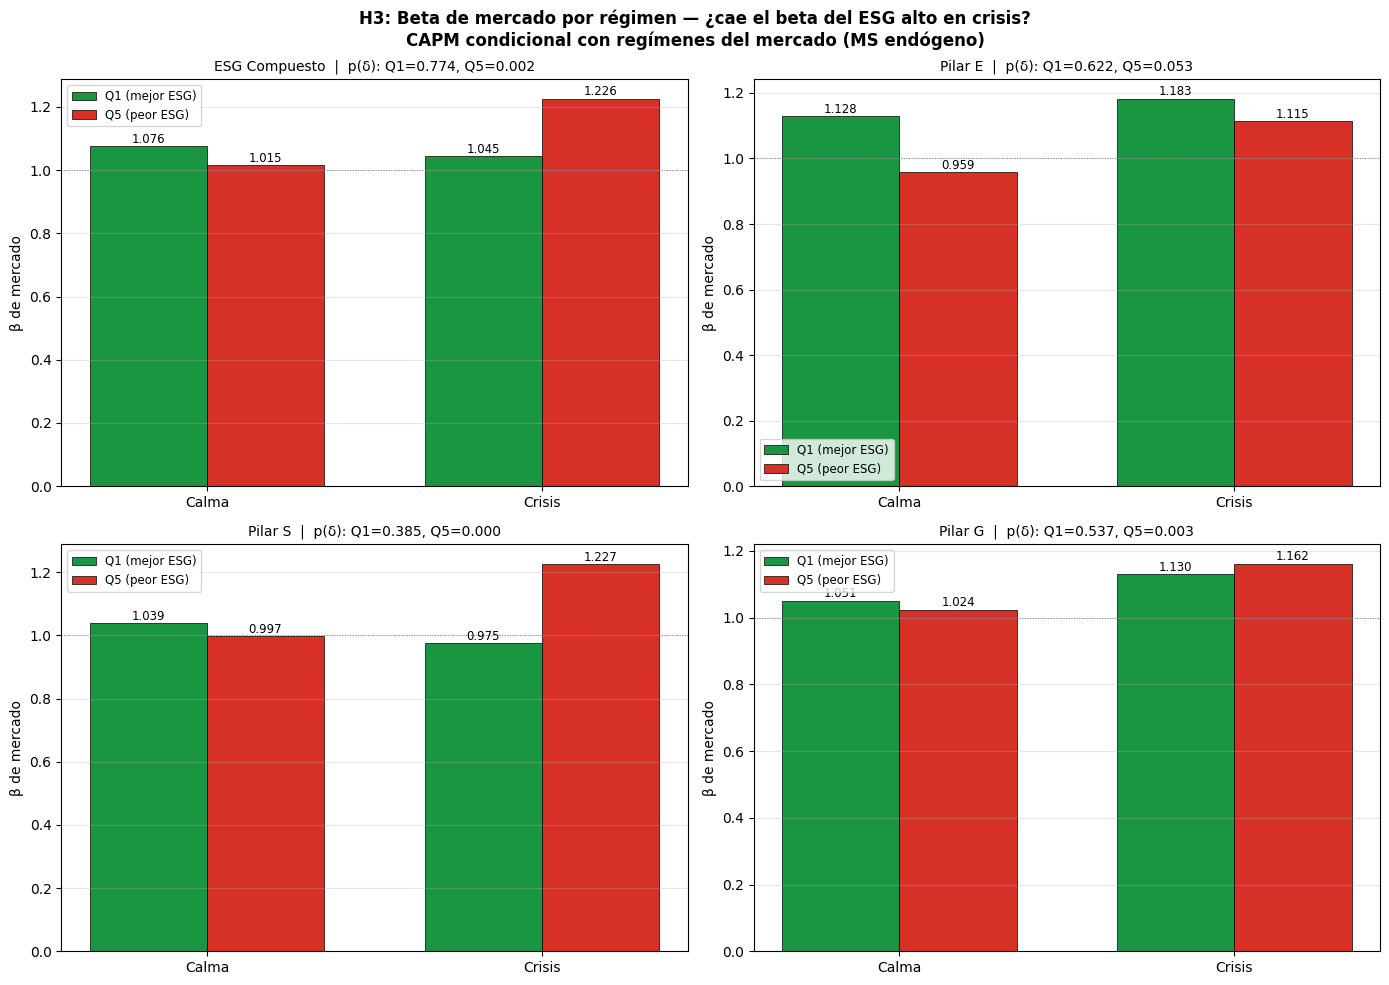

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h3_betas_regimen.png

  Gráfico 3: L-S acumulado con regímenes de crisis sombreados...


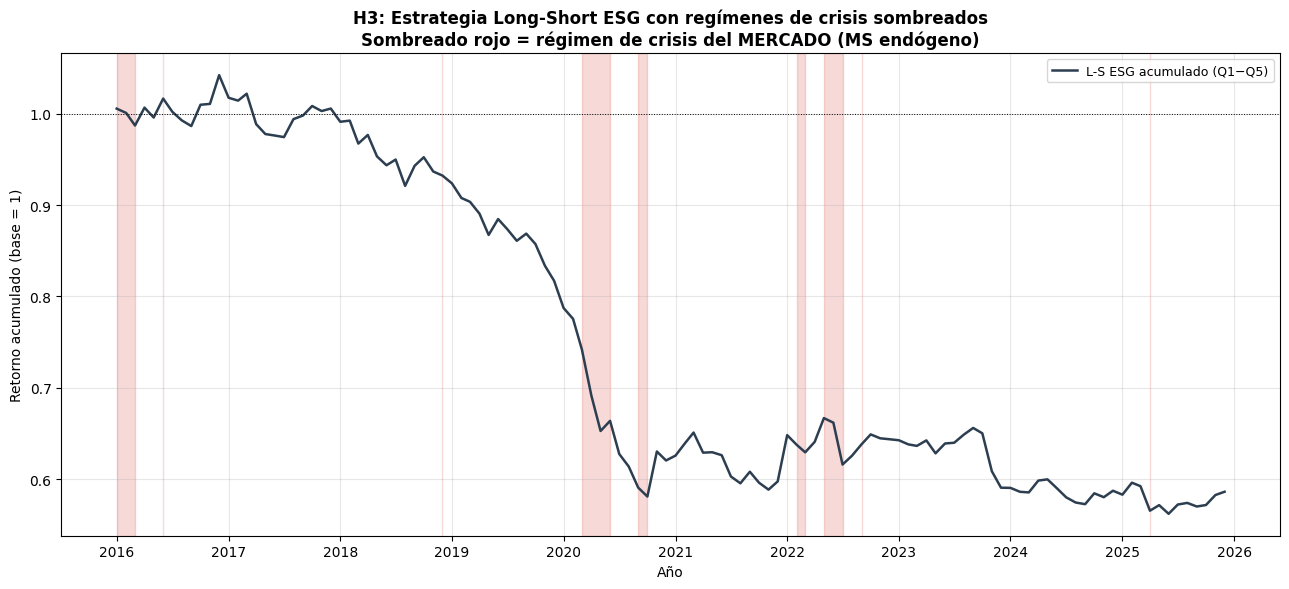

   ✅ Guardado: /content/drive/MyDrive/TFM_STOXX600/HITO4/h3_ls_regimen.png

RESUMEN EJECUTIVO — HIPÓTESIS 3

  ETAPA 1 — Regímenes del mercado (MS endógeno sobre retornos DIARIOS):
  · Calma:  μ = +0.0819%/día, σ = 0.6285%/día (σ anual 10.0%)
  · Crisis: μ = -0.1921%/día, σ = 1.8336%/día (σ anual 29.1%)
  · Agregación mensual: 18 meses en crisis de 120
  · Episodios: 2016-01→2016-03, 2016-06→2016-06, 2018-12→2018-12, 2020-03→2020-06, 2020-09→2020-10, 2022-02→2022-03, 2022-05→2022-07, 2022-09→2022-09, 2025-04→2025-04

  ETAPA 2 — Síntesis Wald y dirección (todas las carteras):
  Score           Cartera      Δβ=δ   Wald χ²        p   Lectura
  ────────────────────────────────────────────────────────────────────
  ESG Compuesto   Q1         -0.031     0.083   0.7737   sin cambio
  ESG Compuesto   Q5         +0.211     9.214   0.0024   amplificador
  ESG Compuesto   Q1-Q5      -0.242     2.792   0.0947   sin cambio
  Pilar E         Q1         +0.054     0.243   0.6220   sin cambio
  Pilar

In [24]:
# ==============================================================================
# SCRIPT 3.4 (v2): HIPÓTESIS 3 — RIESGO DINÁMICO (MARKOV-SWITCHING CAPM)
# ==============================================================================
#
# PREGUNTA: ¿El alto desempeño ESG reduce el riesgo sistemático (Beta)
# exclusivamente en períodos de crisis o alta volatilidad de mercado?
# ("ESG como activo refugio")
#
# DISEÑO EN DOS ETAPAS (v2):
#
#   ETAPA 1 — Detección de regímenes sobre el MERCADO (retornos DIARIOS):
#     R_mt = μ_St + ε_t,  ε_t ~ N(0, σ²_St),  St ∈ {calma, crisis}
#     Markov-Switching (statsmodels MarkovRegression) sobre el retorno DIARIO
#     del STOXX 600 (~2.500 obs): la frecuencia diaria identifica los clusters
#     de volatilidad (COVID 2020, inflación 2022) con mucha más precisión que
#     la mensual, donde solo el episodio COVID resulta detectable.
#     El régimen con mayor σ² se etiqueta CRISIS.
#     → Agregación a mensual: P(crisis) media del mes; D_crisis = 1 si > 0.5
#
#   ETAPA 2 — CAPM condicional por portafolio (OLS + Newey-West):
#     R_pt − R_ft = α + γ·D_t + β·(Rm_Rf)_t + δ·[D_t × (Rm_Rf)_t] + ε_pt
#     β_calma = β | β_crisis = β + δ | Δβ = δ
#     Test de Wald H0: β_calma = β_crisis ⇔ H0: δ = 0 (χ² = t²_NW)
#
# POR QUÉ DOS ETAPAS Y FRECUENCIA DIARIA (nota metodológica para el TFM):
#   (a) La estimación MS directa sobre cada portafolio (α, β y σ² cambiantes,
#   120 obs mensuales) degenera: la verosimilitud diverge cuando un régimen
#   colapsa sobre un único mes con σ²→0 (problema conocido de mezclas
#   gaussianas). Además, regímenes estimados por separado en cada portafolio
#   no son comparables entre Q1 y Q5.
#   (b) El MS sobre el mercado en frecuencia MENSUAL converge pero solo
#   detecta como crisis el episodio COVID (4-5 meses) — insuficiente para
#   el test de interacción. Con retornos DIARIOS los clusters de volatilidad
#   se identifican con precisión y la clasificación mensual resultante tiene
#   masa suficiente en ambos regímenes.
#   Detectar el régimen sobre el mercado (común a todos los portafolios) y
#   estimar el CAPM condicional con interacción es práctica estándar en la
#   literatura de betas condicionales.
#
# CRITERIO DE DECISIÓN (guía HITO 3):
#   Zona Verde:  δ < 0 significativo en Q1 (mejor ESG) Y no en Q5
#                → el ESG reduce el beta en crisis (Kossentini et al. 2024)
#   Efecto general: δ < 0 significativo en Q1 Y Q5 → flight to quality
#                del mercado, no atribuible al ESG
#   Zona Roja:   δ no significativo → el ESG no da inmunidad
#                (Elvira et al. 2025)
#
# REQUIERE: ports_raw (Script 3.2) + df_factors_4f (Script 3.1) en memoria
# ==============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SCRIPT 3.4 (v2): HIPÓTESIS 3 — MS-CAPM EN DOS ETAPAS")
print("=" * 80)
print(f"\nInicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

for var, nombre in [('ports_raw',     'Script 3.2'),
                    ('df_factors_4f', 'Script 3.1'),
                    ('df_stoxx',      'Script 2 principal (Sección 5)')]:
    if var not in dir():
        print(f"❌ '{var}' no está en memoria. Ejecuta {nombre} primero.")
        raise SystemExit

if 'STOXX_VERSION' not in dir():
    STOXX_VERSION = 'versión no identificada'

print(f"Índice de mercado: STOXX 600 [{STOXX_VERSION}]")

SCORES = ['ESG_Score', 'E_Score', 'S_Score', 'G_Score']
SCORE_LABELS = {'ESG_Score': 'ESG Compuesto', 'E_Score': 'Pilar E',
                'S_Score': 'Pilar S', 'G_Score': 'Pilar G'}
CARTERAS = ['Q1', 'Q5', 'Q1-Q5']

np.random.seed(42)


def sig_stars(p):
    if   p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else:          return ''

# ==============================================================================
# SECCIÓN 1: ETAPA 1 — DETECCIÓN DE REGÍMENES (RETORNOS DIARIOS DEL MERCADO)
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 1: Markov-Switching sobre el retorno DIARIO del STOXX 600")
print("─" * 80)

# Serie mensual del mercado (para gráficos y referencia)
mkt = df_factors_4f[['Date', 'YearMonth', 'Rm_Rf']].dropna().sort_values('Date')
rm_serie = pd.Series(mkt['Rm_Rf'].values,
                     index=pd.DatetimeIndex(mkt['Date']), name='Rm_Rf')

# Serie DIARIA del índice, restringida a la ventana de la muestra mensual
fecha_ini = rm_serie.index.min()
ret_d = df_stoxx[['Date', 'Return']].dropna().copy()
ret_d['Date'] = pd.to_datetime(ret_d['Date'])
ret_d = ret_d[ret_d['Date'] >= fecha_ini].sort_values('Date')
rm_diario = pd.Series(ret_d['Return'].values,
                      index=pd.DatetimeIndex(ret_d['Date']), name='Rm_diario')

print(f"\n  Serie diaria del mercado: {len(rm_diario):,} días "
      f"({rm_diario.index.min().date()} → {rm_diario.index.max().date()})")
print(f"  Media: {rm_diario.mean()*100:.4f}%/día | Desv: {rm_diario.std()*100:.4f}%/día")
print(f"  Serie mensual (Etapa 2): {len(rm_serie)} meses")

print("\n  Estimando MS(2) sobre retornos diarios (media + varianza cambiantes)...")
print("  (la frecuencia diaria identifica los clusters de volatilidad con precisión)")

res_mkt = None
for intento, switching_trend in [('media+varianza', True), ('solo varianza', False)]:
    try:
        mod_mkt = MarkovRegression(rm_diario, k_regimes=2, trend='c',
                                   switching_trend=switching_trend,
                                   switching_variance=True)
        cand = mod_mkt.fit(search_reps=10)
        nombres = cand.model.param_names
        p_cand = cand.params
        idx = {n: i for i, n in enumerate(nombres)}
        s2 = np.array([p_cand[idx['sigma2[0]']], p_cand[idx['sigma2[1]']]])
        reg_crisis = int(np.argmax(s2))
        prob_d = cand.smoothed_marginal_probabilities[reg_crisis]
        n_crisis_d = int((prob_d > 0.5).sum())
        # Validación: ambos regímenes con masa razonable (≥30 días) y σ² sana
        if min(n_crisis_d, len(rm_diario) - n_crisis_d) >= 30 and s2.min() > 1e-10:
            res_mkt = cand
            REGIMEN_CRISIS = reg_crisis
            prob_crisis_d = prob_d
            print(f"  ✅ Convergió con especificación: {intento} "
                  f"({n_crisis_d} días en crisis)")
            break
        else:
            print(f"  ⚠️  Especificación '{intento}' degenerada "
                  f"(días crisis={n_crisis_d}, σ²min={s2.min():.2e}) — probando fallback...")
    except Exception as e:
        print(f"  ⚠️  Especificación '{intento}' no convergió ({e}) — probando fallback...")

if res_mkt is None:
    print("❌ El MS del mercado no produjo regímenes válidos. Revisar datos.")
    raise SystemExit

nombres = res_mkt.model.param_names
p_mkt = res_mkt.params
idx = {n: i for i, n in enumerate(nombres)}
REGIMEN_CALMA = 1 - REGIMEN_CRISIS

sigma2_mkt = np.array([p_mkt[idx['sigma2[0]']], p_mkt[idx['sigma2[1]']]])

if f'const[{REGIMEN_CALMA}]' in idx:
    mu_calma  = p_mkt[idx[f'const[{REGIMEN_CALMA}]']]
    mu_crisis = p_mkt[idx[f'const[{REGIMEN_CRISIS}]']]
else:
    mu_calma = mu_crisis = p_mkt[idx['const']]

duraciones = res_mkt.expected_durations

print(f"""
  PARÁMETROS DEL MERCADO POR RÉGIMEN (frecuencia diaria):
  {'':>14} {'μ (%/día)':>10} {'σ (%/día)':>10} {'σ anual':>9} {'Dur. esp.':>11} {'Días':>7}
  {'─'*68}
  {'CALMA':>14} {mu_calma*100:>10.4f} {np.sqrt(sigma2_mkt[REGIMEN_CALMA])*100:>10.4f} {np.sqrt(sigma2_mkt[REGIMEN_CALMA]*252)*100:>8.1f}% {duraciones[REGIMEN_CALMA]:>8.1f} d {len(rm_diario)-int((prob_crisis_d > 0.5).sum()):>7,}
  {'CRISIS':>14} {mu_crisis*100:>10.4f} {np.sqrt(sigma2_mkt[REGIMEN_CRISIS])*100:>10.4f} {np.sqrt(sigma2_mkt[REGIMEN_CRISIS]*252)*100:>8.1f}% {duraciones[REGIMEN_CRISIS]:>8.1f} d {int((prob_crisis_d > 0.5).sum()):>7,}
""")

# ── Agregación a frecuencia mensual ────────────────────────────────────────────
# P(crisis) del mes = media de las probabilidades diarias del mes
prob_m = prob_crisis_d.groupby(prob_crisis_d.index.to_period('M')).mean()
D_crisis_m = (prob_m > 0.5).astype(int)
fechas_m = prob_m.index.to_timestamp()

prob_crisis_mkt = pd.Series(prob_m.values, index=fechas_m, name='P_crisis')
D_crisis = pd.Series(D_crisis_m.values, index=fechas_m, name='D_crisis')
en_crisis_bool = D_crisis.astype(bool)

print(f"  AGREGACIÓN MENSUAL: P(crisis) media del mes > 0.5 → mes en crisis")
print(f"  Meses en crisis: {int(D_crisis.sum())} de {len(D_crisis)}")

# Episodios de crisis detectados (mensual)
episodios = []
inicio = None
fechas = prob_crisis_mkt.index
for i, (fecha, es_c) in enumerate(zip(fechas, en_crisis_bool)):
    if es_c and inicio is None:
        inicio = fecha
    elif not es_c and inicio is not None:
        episodios.append((inicio, fechas[i-1]))
        inicio = None
if inicio is not None:
    episodios.append((inicio, fechas[-1]))

print("\n  EPISODIOS DE CRISIS DETECTADOS (meses con P(crisis) > 0.5):")
for ini, fin in episodios:
    n_m = ((fin.year - ini.year) * 12 + fin.month - ini.month) + 1
    print(f"    {ini.strftime('%Y-%m')} → {fin.strftime('%Y-%m')}  ({n_m} meses)")

print("""
  Validación de credibilidad: episodios esperables a priori en 2016-2025 —
  corrección dic-2018, COVID (feb-jun 2020), inflación/guerra Ucrania (2022).
  La coincidencia con estos eventos respalda la detección endógena.
""")

# ==============================================================================
# SECCIÓN 2: ETAPA 2 — CAPM CONDICIONAL POR PORTAFOLIO (OLS + NEWEY-WEST)
# ==============================================================================

print("─" * 80)
print("SECCIÓN 2: CAPM condicional — R_p−R_f = α + γ·D + β·Rm_Rf + δ·(D×Rm_Rf)")
print("─" * 80)

print("""
  β_calma = β | β_crisis = β + δ | Δβ = δ
  Test de Wald H0: β_calma = β_crisis ⇔ H0: δ = 0 (χ² = t²; t con Newey-West 3 lags)
""")

# Tabla de regímenes para merge por fecha
df_regimen = pd.DataFrame({
    'Date': prob_crisis_mkt.index,
    'D_crisis': D_crisis.values,
    'P_crisis': prob_crisis_mkt.values
})


def capm_condicional(score, cartera):
    """Estima el CAPM condicional con dummy de crisis del mercado."""
    df_p = ports_raw[score].merge(
        df_factors_4f[['YearMonth', 'Rm_Rf']],
        on='YearMonth', how='inner'
    )
    df_p['Date'] = pd.to_datetime(df_p['Date'])
    df_p = df_p.merge(df_regimen, on='Date', how='inner')

    ret_col = 'EX_LS' if cartera == 'Q1-Q5' else f'EX_{cartera}'
    datos = df_p[['Date', ret_col, 'Rm_Rf', 'D_crisis']].dropna().sort_values('Date')

    if len(datos) < 24:
        return None

    datos['D_x_Rm'] = datos['D_crisis'] * datos['Rm_Rf']
    Y = datos[ret_col].values
    X = sm.add_constant(datos[['D_crisis', 'Rm_Rf', 'D_x_Rm']].values)

    modelo_nw = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    modelo    = sm.OLS(Y, X).fit()

    alpha, gamma, beta, delta = modelo_nw.params
    t_delta = modelo_nw.tvalues[3]
    p_delta = modelo_nw.pvalues[3]

    return {
        'score': score, 'cartera': cartera, 'n': len(datos),
        'alpha_calma': alpha, 'alpha_crisis': alpha + gamma,
        'gamma': gamma, 't_gamma': modelo_nw.tvalues[1], 'p_gamma': modelo_nw.pvalues[1],
        'beta_calma': beta, 't_beta': modelo_nw.tvalues[2],
        'delta': delta, 't_delta': t_delta, 'p_delta': p_delta,
        'beta_crisis': beta + delta,
        'wald': t_delta**2,
        'R2': modelo.rsquared, 'R2_adj': modelo.rsquared_adj,
        'modelo_nw': modelo_nw, 'datos': datos,
    }


resultados_h3 = {}
for score in SCORES:
    for cartera in CARTERAS:
        r = capm_condicional(score, cartera)
        if r is not None:
            resultados_h3[(score, cartera)] = r

print(f"  ✅ Modelos estimados: {len(resultados_h3)} / {len(SCORES) * len(CARTERAS)}")

# ── TABLA 2A: parámetros del CAPM condicional ─────────────────────────────────
print("\n" + "═" * 80)
print("TABLA 2A — CAPM CONDICIONAL POR RÉGIMEN (OLS + Newey-West)")
print("═" * 80)

for score in SCORES:
    print(f"\n  {SCORE_LABELS[score]}")
    print(f"  {'Cartera':<8} {'α_calma%':>9} {'α_crisis%':>10} {'β_calma':>8} {'β_crisis':>9} "
          f"{'Δβ (δ)':>8} {'t(δ)':>7} {'p(δ)':>8} {'Sig':>4} {'R²':>6}")
    print(f"  {'─'*86}")
    for cartera in CARTERAS:
        r = resultados_h3.get((score, cartera))
        if r is None:
            continue
        stars = sig_stars(r['p_delta'])
        print(f"  {cartera:<8} {r['alpha_calma']*100:>9.3f} {r['alpha_crisis']*100:>10.3f} "
              f"{r['beta_calma']:>8.3f} {r['beta_crisis']:>9.3f} "
              f"{r['delta']:>8.3f} {r['t_delta']:>7.2f} {r['p_delta']:>8.4f} {stars:>4} {r['R2']:>6.3f}")

# ==============================================================================
# SECCIÓN 3: TEST DE WALD — ¿β DISTINTAS ENTRE REGÍMENES?
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 3: Test de Wald — H0: β_calma = β_crisis (χ² = t²(δ), Newey-West)")
print("─" * 80)

print(f"""
  Umbral (guía HITO 3): Wald χ² > 3.84 (p < 0.05) → betas distintas por régimen.
  Dirección refugio: δ < 0 (el beta CAE en crisis).
""")

print(f"  {'Score':<15} {'Cartera':<8} {'β_calma':>8} {'β_crisis':>9} {'Δβ=δ':>8} "
      f"{'Wald χ²':>9} {'p':>8} {'Sig':>4}  Dirección")
print(f"  {'─'*88}")

for score in SCORES:
    for cartera in CARTERAS:
        r = resultados_h3.get((score, cartera))
        if r is None:
            continue
        stars = sig_stars(r['p_delta'])
        if r['p_delta'] < 0.05:
            direccion = "β cae en crisis (refugio)" if r['delta'] < 0 else "β SUBE en crisis"
        else:
            direccion = "betas iguales"
        print(f"  {SCORE_LABELS[score]:<15} {cartera:<8} {r['beta_calma']:>8.3f} {r['beta_crisis']:>9.3f} "
              f"{r['delta']:>8.3f} {r['wald']:>9.3f} {r['p_delta']:>8.4f} {stars:>4}  {direccion}")

# ==============================================================================
# SECCIÓN 4: DECISIÓN H3 SEGÚN PROTOCOLO HITO 3
# ==============================================================================

print("\n" + "─" * 80)
print("SECCIÓN 4: Decisión H3 según protocolo HITO 3")
print("─" * 80)

r_q1 = resultados_h3.get(('ESG_Score', 'Q1'))
r_q5 = resultados_h3.get(('ESG_Score', 'Q5'))

if r_q1 is not None and r_q5 is not None:
    q1_sig     = r_q1['p_delta'] < 0.05
    q1_refugio = q1_sig and r_q1['delta'] < 0
    q5_sig     = r_q5['p_delta'] < 0.05
    q5_refugio = q5_sig and r_q5['delta'] < 0

    print(f"""
  Q1 (mejor ESG):  β_calma = {r_q1['beta_calma']:.3f} → β_crisis = {r_q1['beta_crisis']:.3f}  (δ = {r_q1['delta']:+.3f})
                   Wald = {r_q1['wald']:.3f} (p = {r_q1['p_delta']:.4f}) → {'significativo' if q1_sig else 'NO significativo'}
  Q5 (peor ESG):   β_calma = {r_q5['beta_calma']:.3f} → β_crisis = {r_q5['beta_crisis']:.3f}  (δ = {r_q5['delta']:+.3f})
                   Wald = {r_q5['wald']:.3f} (p = {r_q5['p_delta']:.4f}) → {'significativo' if q5_sig else 'NO significativo'}

  RESULTADO:
""")

    q5_amplifica = q5_sig and r_q5['delta'] > 0

    if q1_refugio and not q5_refugio:
        print("  ✅ ZONA VERDE: el beta de Q1 cae en crisis y el de Q5 no →")
        print("     el alto desempeño ESG actúa como refugio en pánicos bursátiles")
        print("     (consistente con Kossentini et al. 2024)")
    elif q1_refugio and q5_refugio:
        print("  🟡 EFECTO GENERAL, NO ESG: ambos quintiles reducen beta en crisis →")
        print("     flight to quality generalizado del mercado, no atribuible al ESG.")
        print("     H3 NO se confirma como efecto diferencial del ESG.")
    elif not q1_sig and q5_amplifica:
        print("  🟠 HALLAZGO ESPECULAR — PROTECCIÓN RELATIVA DEL ESG:")
        print("     El beta de Q1 (mejor ESG) se mantiene ESTABLE entre regímenes,")
        print("     pero el de Q5 (peor ESG) AUMENTA significativamente en crisis.")
        print("     → H3 se RECHAZA en su formulación original (el ESG alto no")
        print("       reduce su beta en crisis — no es refugio absoluto), PERO el")
        print("       bajo desempeño ESG sí AMPLIFICA el riesgo sistemático en")
        print("       crisis. El ESG protege en términos RELATIVOS: evita la")
        print("       amplificación del riesgo que sufren las empresas low-ESG.")
        print("     → Coherente con el riesgo 'brown' (Bolton & Kacperczyk 2021):")
        print("       el riesgo de transición de las low-ESG se materializa con")
        print("       mayor intensidad en los episodios de estrés del mercado.")
    elif not q1_sig and not q5_sig:
        print("  🔴 ZONA ROJA: betas estadísticamente iguales entre regímenes →")
        print("     el ESG no da inmunidad ante crisis; las inversiones sostenibles")
        print("     siguen sujetas a los mismos riesgos sistemáticos")
        print("     (consistente con Elvira et al. 2025)")
    else:
        print("  🟡 RESULTADO MIXTO: revisar tabla de Wald (Sección 3) — la evidencia")
        print("     no es concluyente en la dirección esperada por H3.")

    # Lectura complementaria: el L-S
    r_ls = resultados_h3.get(('ESG_Score', 'Q1-Q5'))
    if r_ls is not None:
        print(f"""
  Lectura complementaria (L-S ESG): δ = {r_ls['delta']:+.3f} (p = {r_ls['p_delta']:.4f})
  El δ del L-S mide directamente la DIFERENCIA de sensibilidad al régimen
  entre Q1 y Q5: δ_LS < 0 significativo indicaría que el spread defensivo
  del ESG mejora en crisis.""")

# ==============================================================================
# SECCIÓN 5: GRÁFICOS
# ==============================================================================

print("\n" + "─" * 80)
print(f"SECCIÓN 5: Gráficos — H3 [{STOXX_VERSION}]")
print("─" * 80)

import os
RUTA_GRAFICOS = '/content/drive/MyDrive/TFM_STOXX600/HITO4'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

# ── Gráfico 1: Régimen del mercado — P(crisis) + Rm_Rf ────────────────────────
print("\n  Gráfico 1: Regímenes del mercado (P(crisis) + Rm_Rf)...")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                          gridspec_kw={'height_ratios': [1.5, 1]})
fig.suptitle('H3: Regímenes del mercado detectados endógenamente\n'
             f'MS(2) sobre retornos diarios — STOXX 600 {STOXX_VERSION} — 2016–2025',
             fontsize=12, fontweight='bold')

ax1 = axes[0]
ax1.bar(rm_serie.index, rm_serie * 100, width=22, color=np.where(
    en_crisis_bool.values, '#d73027', '#74add1'), alpha=0.85)
ax1.axhline(0, color='black', linewidth=0.7)
ax1.set_ylabel('Rm_Rf (%/mes)')
ax1.set_title('Prima de mercado mensual (rojo = mes clasificado en crisis)', fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(prob_crisis_d.index, prob_crisis_d, 0, color='#d73027', alpha=0.35)
ax2.plot(prob_crisis_d.index, prob_crisis_d, color='#d73027', linewidth=0.7)
ax2.axhline(0.5, color='black', linewidth=0.7, linestyle=':')
ax2.set_ylabel('P(crisis) diaria')
ax2.set_xlabel('Año')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h3_regimen_mercado.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 2: β por régimen — Q1 vs Q5 para los 4 scores ─────────────────────
print("\n  Gráfico 2: Betas por régimen (Q1 vs Q5, 4 scores)...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('H3: Beta de mercado por régimen — ¿cae el beta del ESG alto en crisis?\n'
             'CAPM condicional con regímenes del mercado (MS endógeno)',
             fontsize=12, fontweight='bold')

for ax, score in zip(axes.flatten(), SCORES):
    r1 = resultados_h3.get((score, 'Q1'))
    r5 = resultados_h3.get((score, 'Q5'))
    if r1 is None or r5 is None:
        continue

    x = np.arange(2)
    ancho = 0.35
    ax.bar(x - ancho/2, [r1['beta_calma'], r1['beta_crisis']], ancho,
           label='Q1 (mejor ESG)', color='#1a9641', edgecolor='black', linewidth=0.5)
    ax.bar(x + ancho/2, [r5['beta_calma'], r5['beta_crisis']], ancho,
           label='Q5 (peor ESG)', color='#d73027', edgecolor='black', linewidth=0.5)

    for xi, (v1, v5) in enumerate(zip([r1['beta_calma'], r1['beta_crisis']],
                                      [r5['beta_calma'], r5['beta_crisis']])):
        ax.text(xi - ancho/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8.5)
        ax.text(xi + ancho/2, v5 + 0.01, f'{v5:.3f}', ha='center', fontsize=8.5)

    ax.axhline(1, color='gray', linewidth=0.7, linestyle=':')
    ax.set_xticks(x)
    ax.set_xticklabels(['Calma', 'Crisis'])
    ax.set_ylabel('β de mercado')
    ax.set_title(f"{SCORE_LABELS[score]}  |  p(δ): Q1={r1['p_delta']:.3f}, Q5={r5['p_delta']:.3f}",
                 fontsize=10)
    ax.legend(fontsize=8.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
ruta = f'{RUTA_GRAFICOS}/h3_betas_regimen.png'
plt.savefig(ruta, dpi=150, bbox_inches='tight')
plt.show()
print(f"   ✅ Guardado: {ruta}")

# ── Gráfico 3: Retorno acumulado L-S con regímenes sombreados ─────────────────
print("\n  Gráfico 3: L-S acumulado con regímenes de crisis sombreados...")

r_ls = resultados_h3.get(('ESG_Score', 'Q1-Q5'))
if r_ls is not None:
    datos_ls = r_ls['datos']
    cum_ls = (1 + datos_ls['EX_LS']).cumprod()

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(datos_ls['Date'], cum_ls, color='#2c3e50', linewidth=1.8,
            label='L-S ESG acumulado (Q1−Q5)')

    for ini, fin in episodios:
        ax.axvspan(ini, fin, color='#d73027', alpha=0.18)

    ax.axhline(1, color='black', linewidth=0.7, linestyle=':')
    ax.set_title('H3: Estrategia Long-Short ESG con regímenes de crisis sombreados\n'
                 'Sombreado rojo = régimen de crisis del MERCADO (MS endógeno)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Retorno acumulado (base = 1)')
    ax.set_xlabel('Año')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

    plt.tight_layout()
    ruta = f'{RUTA_GRAFICOS}/h3_ls_regimen.png'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Guardado: {ruta}")

# ==============================================================================
# SECCIÓN 6: RESUMEN EJECUTIVO H3
# ==============================================================================

print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO — HIPÓTESIS 3")
print("=" * 80)

print(f"""
  ETAPA 1 — Regímenes del mercado (MS endógeno sobre retornos DIARIOS):
  · Calma:  μ = {mu_calma*100:+.4f}%/día, σ = {np.sqrt(sigma2_mkt[REGIMEN_CALMA])*100:.4f}%/día (σ anual {np.sqrt(sigma2_mkt[REGIMEN_CALMA]*252)*100:.1f}%)
  · Crisis: μ = {mu_crisis*100:+.4f}%/día, σ = {np.sqrt(sigma2_mkt[REGIMEN_CRISIS])*100:.4f}%/día (σ anual {np.sqrt(sigma2_mkt[REGIMEN_CRISIS]*252)*100:.1f}%)
  · Agregación mensual: {int(D_crisis.sum())} meses en crisis de {len(D_crisis)}
  · Episodios: {', '.join(f"{i.strftime('%Y-%m')}→{f.strftime('%Y-%m')}" for i, f in episodios)}
""")

print("  ETAPA 2 — Síntesis Wald y dirección (todas las carteras):")
print(f"  {'Score':<15} {'Cartera':<8} {'Δβ=δ':>8} {'Wald χ²':>9} {'p':>8}   Lectura")
print(f"  {'─'*68}")
for score in SCORES:
    for cartera in CARTERAS:
        r = resultados_h3.get((score, cartera))
        if r is None:
            continue
        if r['p_delta'] < 0.05:
            lectura = "refugio" if r['delta'] < 0 else "amplificador"
        else:
            lectura = "sin cambio"
        print(f"  {SCORE_LABELS[score]:<15} {cartera:<8} {r['delta']:>+8.3f} "
              f"{r['wald']:>9.3f} {r['p_delta']:>8.4f}   {lectura}")

print(f"""
  Nota metodológica (documentar en el TFM): los regímenes se detectan
  endógenamente sobre los retornos DIARIOS del mercado (un único MS común a
  todos los portafolios; la frecuencia diaria identifica los clusters de
  volatilidad con precisión) y el contraste de betas se realiza en frecuencia
  mensual vía interacción en el CAPM condicional con errores Newey-West.
  La estimación MS directa sobre cada portafolio degenera con 120
  observaciones mensuales (régimen espurio de varianza nula) y produce
  regímenes no comparables entre carteras; el MS mensual del mercado solo
  detecta COVID (4-5 meses), insuficiente para el test de interacción.
""")

print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

# ==============================================================================
# SECCIÓN 7: ANEXO — SUMMARIES COMPLETOS
# ==============================================================================

print("\n" + "=" * 80)
print("SECCIÓN 7: ANEXO — Summaries completos")
print("=" * 80)

print(f"\n{'═'*78}")
print(f"  ETAPA 1 — Markov-Switching del mercado (régimen {REGIMEN_CRISIS} = crisis)")
print(f"{'═'*78}")
print(res_mkt.summary())

for cartera in CARTERAS:
    r = resultados_h3.get(('ESG_Score', cartera))
    if r is None:
        continue
    print(f"\n{'═'*78}")
    print(f"  ETAPA 2 — CAPM condicional: ESG Compuesto, Cartera {cartera}")
    print(f"  Variables: const=α | x1=D_crisis (γ) | x2=Rm_Rf (β) | x3=D×Rm_Rf (δ)")
    print(f"{'═'*78}")
    print(r['modelo_nw'].summary())